In [1]:
from hossam import load_data
from helpers import *
import numpy as np
from pandas import DataFrame, concat
import pandas as pd
from IPython.display import display, Markdown
origin = load_data("streeteasy")

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.29

⚠️  'hossam' 패키지의 최신 버전이 출시되었습니다! (설치된 버전: 0.5.29, 최신 버전: 0.5.33)
   최신 버전으로 업데이트하려면 다음 명령어를 실행하세요:
   pip install --upgrade hossam

📚 StreetEasy는 뉴욕시 최고의 부동산 마켓플레이스입니다. 여러분은 맨해튼의 임대 매물 5,000건을 표본으로 하는 데이터셋을 다루게 될 것입니다. (출처: https://www.kaggle.com/datasets/zohaib30/streeteasy-dataset)

    field             description
--  ----------------  -------------------------------------------------------------------------------------------------------------------
 0  rent              월 임대료(USD) — 연속형, 회귀 분석의 종속변수(타깃). 범위 1,300~20,000, 평균 약 5,139
 1  bedrooms          침실 수 — 이산 수치형(순서형). 0.5 단위 10개 값(0~5), 0은 스튜디오(원룸), 0.5는 침실 분리형 원룸
 2  bathrooms         욕실 수 — 이산 수치형(순서형). 0~5의 정수, 0은 독립 욕실 없음
 3  size_sqft         전용 면적(제곱피트, 1sqft≈0.028평) — 연속형. 범위 250~4,800, 임대료와 상관이 가장 높은 변수
 4  mi

# 1부. 데이터를 이해하는 단계
## 미션1. "이 표본은 무엇을 담고 있나?"

In [2]:
origin.head()

,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood,borough
0,2550,0.000,1,480,9,2.000,17,1,1,0,0,1,1,0,1,Upper East Side,Manhattan
1,11500,2.000,2,2000,4,1.000,96,0,0,0,0,0,0,0,0,Greenwich Village,Manhattan
2,4500,1.000,1,916,2,51.000,29,0,1,0,1,1,1,0,0,Midtown,Manhattan
3,4795,1.000,1,975,3,8.000,31,0,0,0,1,1,1,0,1,Greenwich Village,Manhattan
4,17500,2.000,2,4800,3,4.000,136,0,0,0,1,1,1,0,1,Soho,Manhattan


In [3]:
df1 = my_qtcheck.set_type(origin, as_category=["no_fee", "has_roofdeck", "has_washer_dryer", "has_doorman", "has_elevator", "has_dishwasher", "has_patio", "has_gym", "neighborhood"])

<class 'pandas.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   rent              3539 non-null   int64   
 1   bedrooms          3539 non-null   float64 
 2   bathrooms         3539 non-null   int64   
 3   size_sqft         3539 non-null   int64   
 4   min_to_subway     3539 non-null   int64   
 5   floor             3539 non-null   float64 
 6   building_age_yrs  3539 non-null   int64   
 7   no_fee            3539 non-null   category
 8   has_roofdeck      3539 non-null   category
 9   has_washer_dryer  3539 non-null   category
 10  has_doorman       3539 non-null   category
 11  has_elevator      3539 non-null   category
 12  has_dishwasher    3539 non-null   category
 13  has_patio         3539 non-null   category
 14  has_gym           3539 non-null   category
 15  neighborhood      3539 non-null   category
 16  borough           3539 non-null   s

In [4]:
# 중복값 제거
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 27
중복된 행이 제거되었습니다.


,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood,borough
0,2550,0.000,1,480,9,2.000,17,1,1,0,0,1,1,0,1,Upper East Side,Manhattan
1,11500,2.000,2,2000,4,1.000,96,0,0,0,0,0,0,0,0,Greenwich Village,Manhattan
2,4500,1.000,1,916,2,51.000,29,0,1,0,1,1,1,0,0,Midtown,Manhattan
3,4795,1.000,1,975,3,8.000,31,0,0,0,1,1,1,0,1,Greenwich Village,Manhattan
4,17500,2.000,2,4800,3,4.000,136,0,0,0,1,1,1,0,1,Soho,Manhattan


In [5]:
# 결측치 비율 확인
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
rent,0,0.000
bedrooms,0,0.000
bathrooms,0,0.000
size_sqft,0,0.000
min_to_subway,0,0.000
floor,0,0.000
building_age_yrs,0,0.000
no_fee,0,0.000
has_roofdeck,0,0.000
has_washer_dryer,0,0.000


In [6]:
df2_categorical_qtcheck = my_qtcheck.categorical_summary(df2, save_path=None)
df2_numerical_qtcheck = my_qtcheck.numerical_summary(df2, save_path=None)

📊 컬럼 'no_fee'의 value_counts():


,count
no_fee,
0,2091
1,1421


📊 컬럼 'has_roofdeck'의 value_counts():


,count
has_roofdeck,
0,2967
1,545


📊 컬럼 'has_washer_dryer'의 value_counts():


...

,count
has_patio,
0,3317
1,195


📊 컬럼 'has_gym'의 value_counts():


,count
has_gym,
0,2897
1,615


📊 컬럼 'neighborhood'의 value_counts():


,count
neighborhood,
Battery Park City,104
Central Harlem,81
Central Park South,23
Chelsea,181
Chinatown,7
East Harlem,40
East Village,108
Financial District,265
Flatiron,132


In [7]:
display(df2)
display(df2_categorical_qtcheck)
display(df2_numerical_qtcheck.T)

,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood,borough
0,2550,0.000,1,480,9,2.000,17,1,1,0,0,1,1,0,1,Upper East Side,Manhattan
1,11500,2.000,2,2000,4,1.000,96,0,0,0,0,0,0,0,0,Greenwich Village,Manhattan
2,4500,1.000,1,916,2,51.000,29,0,1,0,1,1,1,0,0,Midtown,Manhattan
3,4795,1.000,1,975,3,8.000,31,0,0,0,1,1,1,0,1,Greenwich Village,Manhattan
4,17500,2.000,2,4800,3,4.000,136,0,0,0,1,1,1,0,1,Soho,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3534,4210,1.000,1,532,3,8.000,16,1,1,1,1,1,1,0,1,Chelsea,Manhattan
3535,6675,2.000,2,988,5,10.000,9,1,1,1,1,1,1,0,1,Tribeca,Manhattan
3536,1699,0.000,1,250,2,5.000,96,0,0,0,0,0,0,0,0,Little Italy,Manhattan
3537,3475,1.000,1,651,6,5.000,14,1,0,1,1,1,1,0,1,Midtown West,Manhattan


,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood
count,3512,3512,3512,3512,3512,3512,3512,3512,3512
unique,2,2,2,2,2,2,2,2,32
top,0,0,0,0,0,0,0,0,Upper West Side
freq,2091,2967,2947,2529,2479,2860,3317,2897,577


,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs
count,3512.000,3512.000,3512.000,3512.000,3512.000,3512.000,3512.000
mean,5142.887,1.354,1.367,940.287,4.965,11.887,51.958
std,3157.513,0.968,0.600,478.290,5.489,10.928,39.420
min,1300.000,0.000,0.000,250.000,0.000,0.000,0.000
25%,3169.250,1.000,1.000,615.000,2.000,4.000,15.000
50%,4000.000,1.000,1.000,800.000,4.000,8.000,39.000
75%,6000.000,2.000,2.000,1141.500,6.000,17.000,90.000
max,20000.000,5.000,5.000,4800.000,43.000,83.000,180.000
rel_diff,0.286,0.354,0.367,0.175,0.241,0.486,0.332
rdiff_flag,diff,diff,diff,diff,diff,diff,diff


In [8]:
(df2[["bedrooms", "bathrooms", "floor", "building_age_yrs"]] == 0).sum()

bedrooms            634
bathrooms             9
floor                 1
building_age_yrs     28
dtype: int64

In [9]:
df2[["neighborhood", "borough"]].nunique()

neighborhood    32
borough          1
dtype: int64

In [10]:
df2["neighborhood"].value_counts()

neighborhood
Upper West Side        577
Upper East Side        492
Midtown East           455
Midtown West           311
Financial District     265
Chelsea                181
Flatiron               132
Tribeca                119
Midtown                118
East Village           108
Battery Park City      104
Midtown South           85
Central Harlem          81
West Village            67
Greenwich Village       66
Gramercy Park           61
Soho                    58
Washington Heights      54
Lower East Side         41
East Harlem             40
Central Park South      23
Hamilton Heights        16
Morningside Heights     13
Inwood                  11
Nolita                   9
Chinatown                7
Roosevelt Island         5
Long Island City         4
Little Italy             3
Stuyvesant Town/PCV      3
West Harlem              2
Manhattanville           1
Name: count, dtype: int64

In [11]:
df2["borough"].value_counts()

borough
Manhattan    3512
Name: count, dtype: int64

In [12]:
df2.to_excel("streeteasy_qtcheck.xlsx", index=False)
df2_categorical_qtcheck.to_excel("streeteasy_categorical_qtcheck.xlsx")
df2_numerical_qtcheck.to_excel("streeteasy_numerical_qtcheck.xlsx")

In [13]:
# 4. 변수 유형 분류
# 종속변수
target = "rent"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df2)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형 :", nominal_cols)
print("연속형 :", continuous_cols)

종속변수 : rent
종속변수 유형: 연속형
명목형 : ['no_fee', 'has_roofdeck', 'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher', 'has_patio', 'has_gym', 'neighborhood']
연속형 : ['bedrooms', 'bathrooms', 'size_sqft', 'min_to_subway', 'floor', 'building_age_yrs']


**미션1**<br>
데이터의 크기 : 3539행 17열<br>
중복값 27개 삭제처리<br>
결측치 없음<br>
준공 후 경과 연수 최대값 180년. 확인 필요<br>
침실 수 0 값 634개 = 원룸<br>
화장실 수 0 값 9개 = 공용욕실<br>
층수 0 값 1개 = 지하/반지하층<br>
준공 후 경과 연수 0 값 28개 = 신축<br>
명목형 변수 neighborhood(동네명) 범주 = 32개. 범위 = 1~577. 값의 불균형 존재<br>
명목형 변수 borough : 단일값이므로 분산 0, 변동성이 없으므로 설명변수로 사용 불가능

## 미션2. "어떤 변수가 회귀를 방해할까?"

In [14]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("streeteasy_qtcheck.xlsx")
num_desc = pd.read_excel("streeteasy_numerical_qtcheck.xlsx", index_col=0)
cat_desc = pd.read_excel("streeteasy_categorical_qtcheck.xlsx", index_col=0)

In [15]:
# 타입 변환(명목형 확정)
df3 = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   rent              3512 non-null   int64   
 1   bedrooms          3512 non-null   float64 
 2   bathrooms         3512 non-null   int64   
 3   size_sqft         3512 non-null   int64   
 4   min_to_subway     3512 non-null   int64   
 5   floor             3512 non-null   float64 
 6   building_age_yrs  3512 non-null   int64   
 7   no_fee            3512 non-null   category
 8   has_roofdeck      3512 non-null   category
 9   has_washer_dryer  3512 non-null   category
 10  has_doorman       3512 non-null   category
 11  has_elevator      3512 non-null   category
 12  has_dishwasher    3512 non-null   category
 13  has_patio         3512 non-null   category
 14  has_gym           3512 non-null   category
 15  neighborhood      3512 non-null   category
 16  borough           3512 non-null   s

In [16]:
column_means = {
    "rent": "월 임대료(USD)",
    "bedrooms": "침실 수",
    "bathrooms": "욕실 수",
    "size_sqft": "전용면적(제곱피트)",
    "min_to_subway": "지하철역까지 소요시간(분)",
    "floor": "층수",
    "building_age_yrs": "건물 연식(년)",
    "no_fee": "중개 수수료 없음 여부",
    "has_roofdeck": "옥상 데크 보유 여부",
    "has_washer_dryer": "세탁기·건조기 보유 여부",
    "has_doorman": "도어맨 보유 여부",
    "has_elevator": "엘리베이터 보유 여부",
    "has_dishwasher": "식기세척기 보유 여부",
    "has_patio": "파티오 보유 여부",
    "has_gym": "피트니스센터 보유 여부",
    "neighborhood": "세부 동네명",
    "borough": "자치구"
}

In [17]:
# 종속변수 기술통계량 추출
num_desc.loc[[target]].T

,rent
count,3512
mean,5142.887
std,3157.513
min,1300
25%,3169.250
50%,4000
75%,6000.000
max,20000
rel_diff,0.286
rdiff_flag,diff


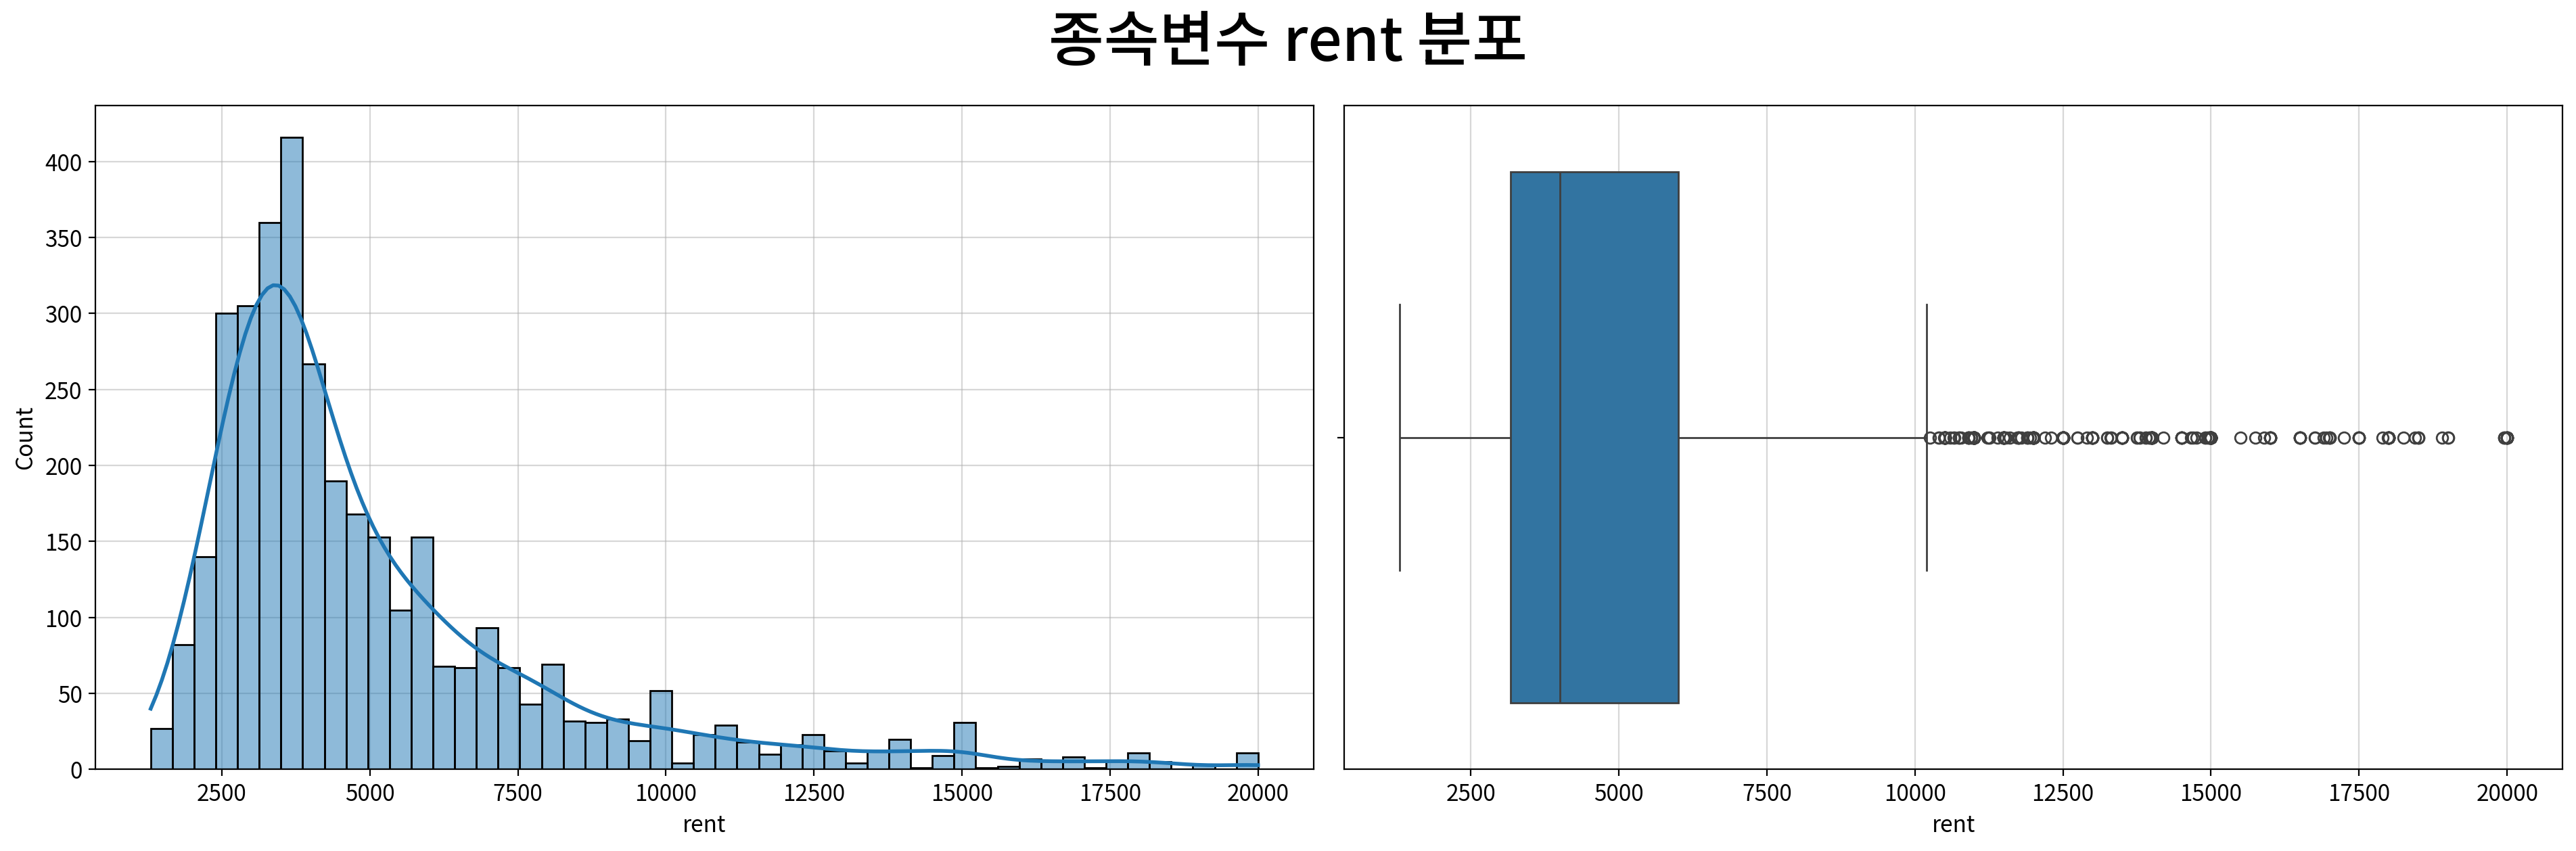

,rent
count,3512
mean,5142.887
std,3157.513
min,1300
25%,3169.250
50%,4000
75%,6000.000
max,20000
rel_diff,0.286
rdiff_flag,diff


In [18]:
# 02. 단변량 분석
# 1. 연속형 종속변수에 대한 단변량 분석
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2,
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df3, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df3, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

**미션2**
|변수|평균·중앙값|왜도|첨도|이상치 비율|판단|
|-----|-----|-----|----|----|-----|
| `rent`|28.6% | 1.986 |  4.343 |7.7% |모두 강한 오른쪽 치우침과 극단graded값의 영향을 나타냄|
| `bedrooms`|35.4% | 0.575 |  0.159 |2.3% |평균·중앙값 거리는 크지만, 나머지 치우침은 크지 않음|
| `bathrooms`|36.7% | 1.502 |  2.194 |0.4% |오른쪽 치우침이 크지만, IQR 기준 이상치의 영향은 작음|
| `size_sqft`|17.5% | 1.752 |  4.430 |5.1% |모두 오른쪽 치우침과 극단값의 영향을 나타냄|
| `min_to_subway`|24.1% | 4.852 | 30.216 |3.4% |왜도와 첨도가 매우 높아 일부 큰 값의 영향이 강하지만, 이상치 비율은 5% 미만|
| `floor`|48.6% | 1.711 |  3.697 |4.1% | 평균과 중앙값의 차이 및 오른쪽 치우침이 크지만, 이상치 비율은 5% 미만|
| `building_age_yrs`|33.2% | 0.420 | -1.174 |0.0% |평균·중앙값의 거리만 크고 심한 치우침이나 극단값을 나타내지 않음|


**로그변환 후보 목록**
|변수|변환 방법|선정 이유|
|----|-------|-------|
|`rent`|`log`| 오른쪽 꼬리이며 이상치 비율이 7.7%이고, 최솟값이 0보다 큼|
|`bedrooms`|`log1p`|오른쪽 꼬리와 이상치가 있으며 0을 포함함|
|`bathrooms`|`log1p`|오른쪽 꼬리와 이상치가 있으며 0을 포함함|
|`size_sqft`|`log`| 오른쪽 꼬리이며 이상치 비율이 5.1%이고, 최솟값이 0보다 큼|
|`min_to_subway`|`log1p`| 왜도가 4.852로 매우 크며 0을 포함함|
|`floor`|`log1p`|오른쪽 꼬리와 이상치가 있으며 0을 포함함|

# 2부. 변수를 고르는 단계
## 미션3. "월세를 가르는 변수는 무엇인가?"

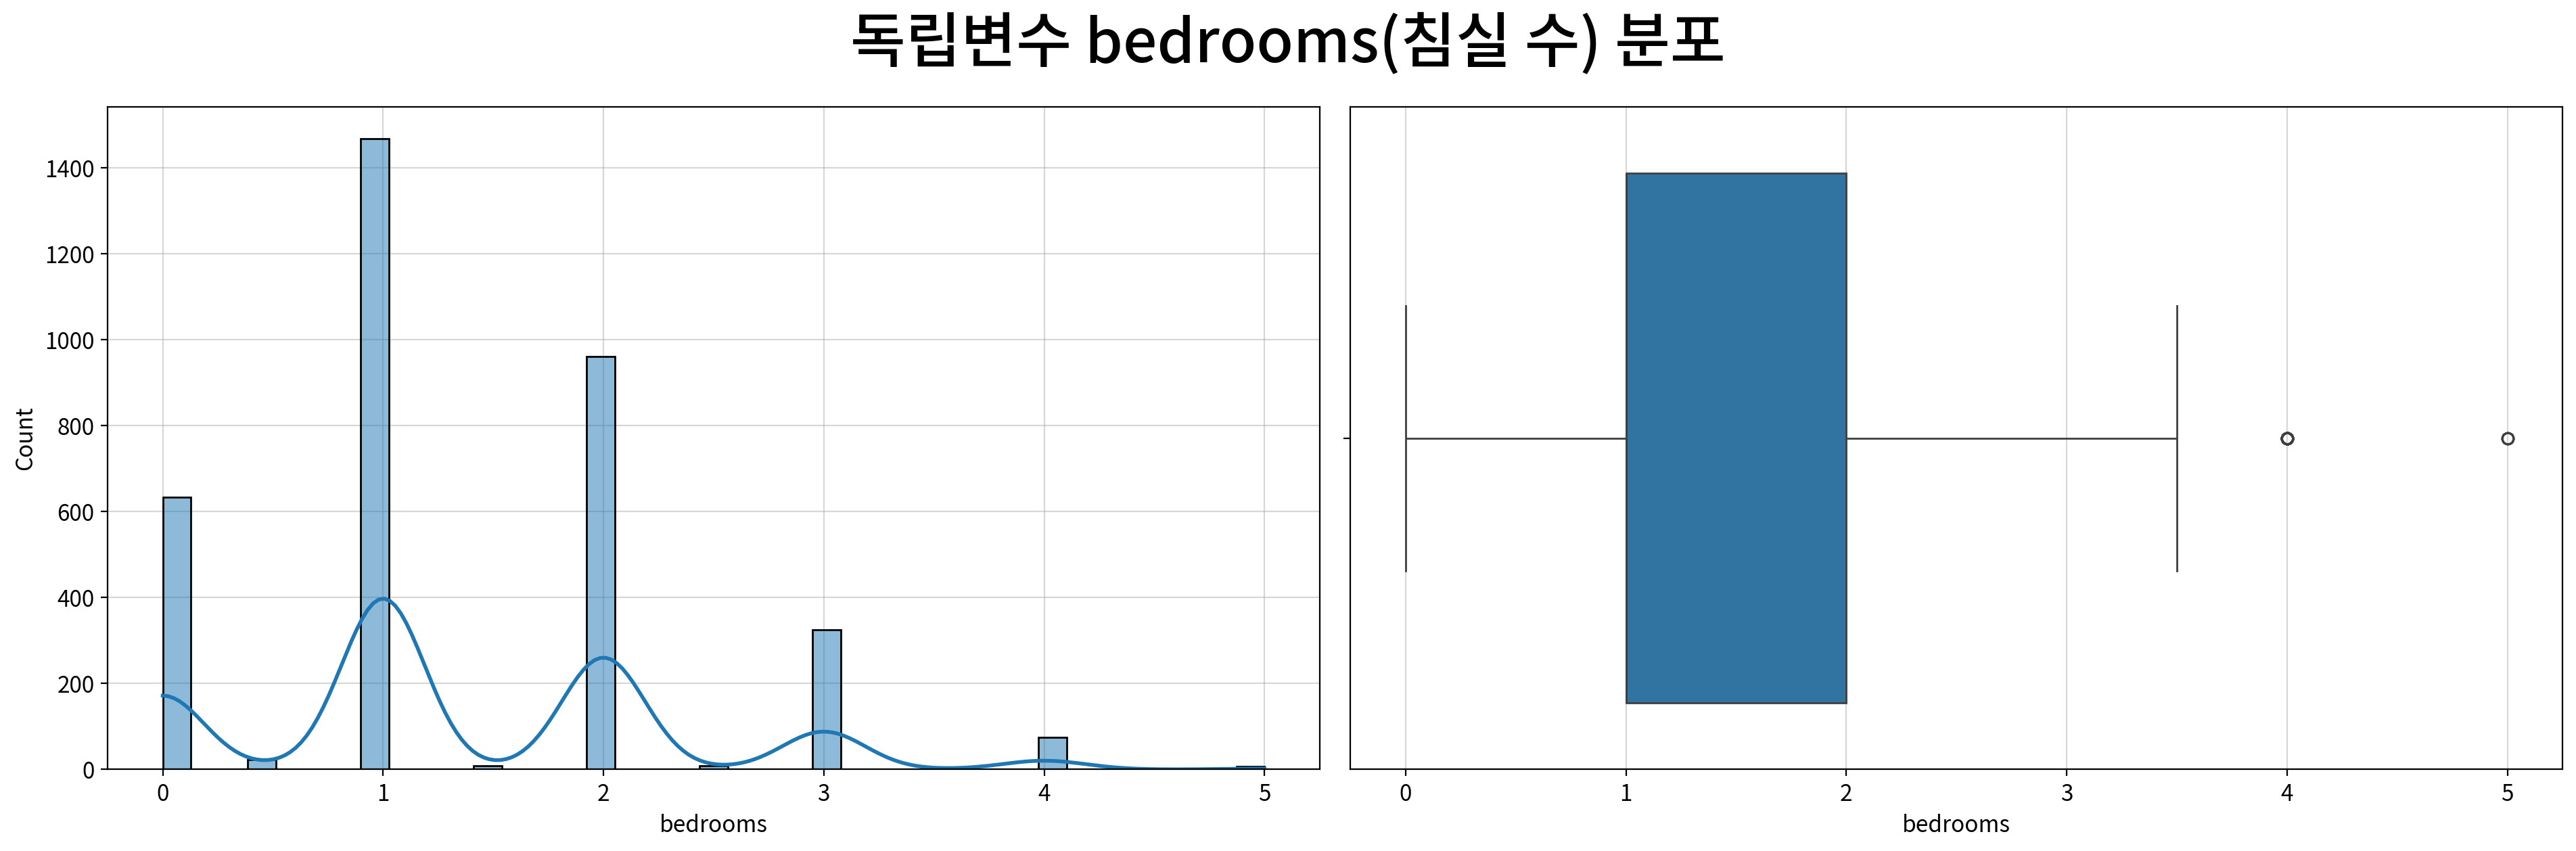

,bedrooms
count,3512
mean,1.354
std,0.968
min,0
25%,1.000
50%,1
75%,2.000
max,5
rel_diff,0.354
rdiff_flag,diff


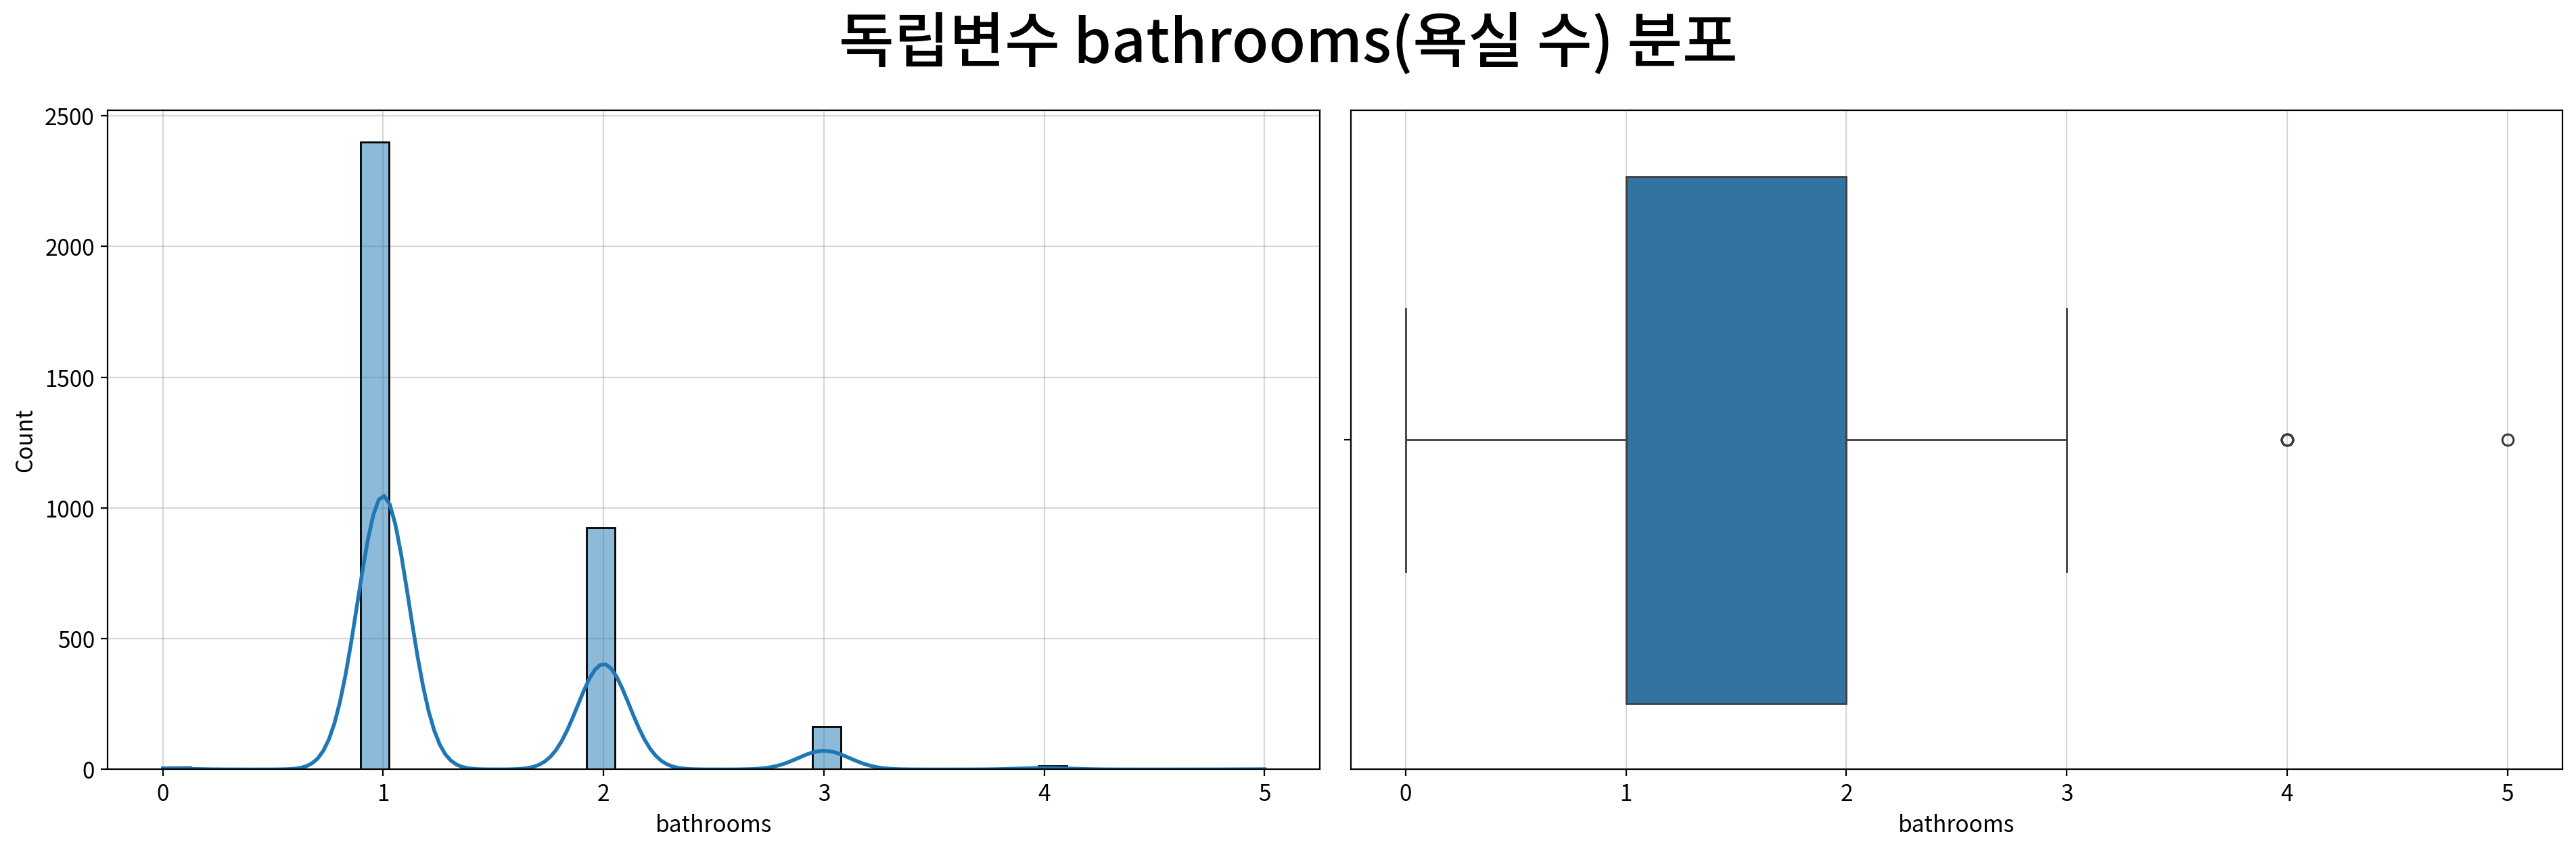

,bathrooms
count,3512
mean,1.367
std,0.600
min,0
25%,1.000
50%,1
75%,2.000
max,5
rel_diff,0.367
rdiff_flag,diff


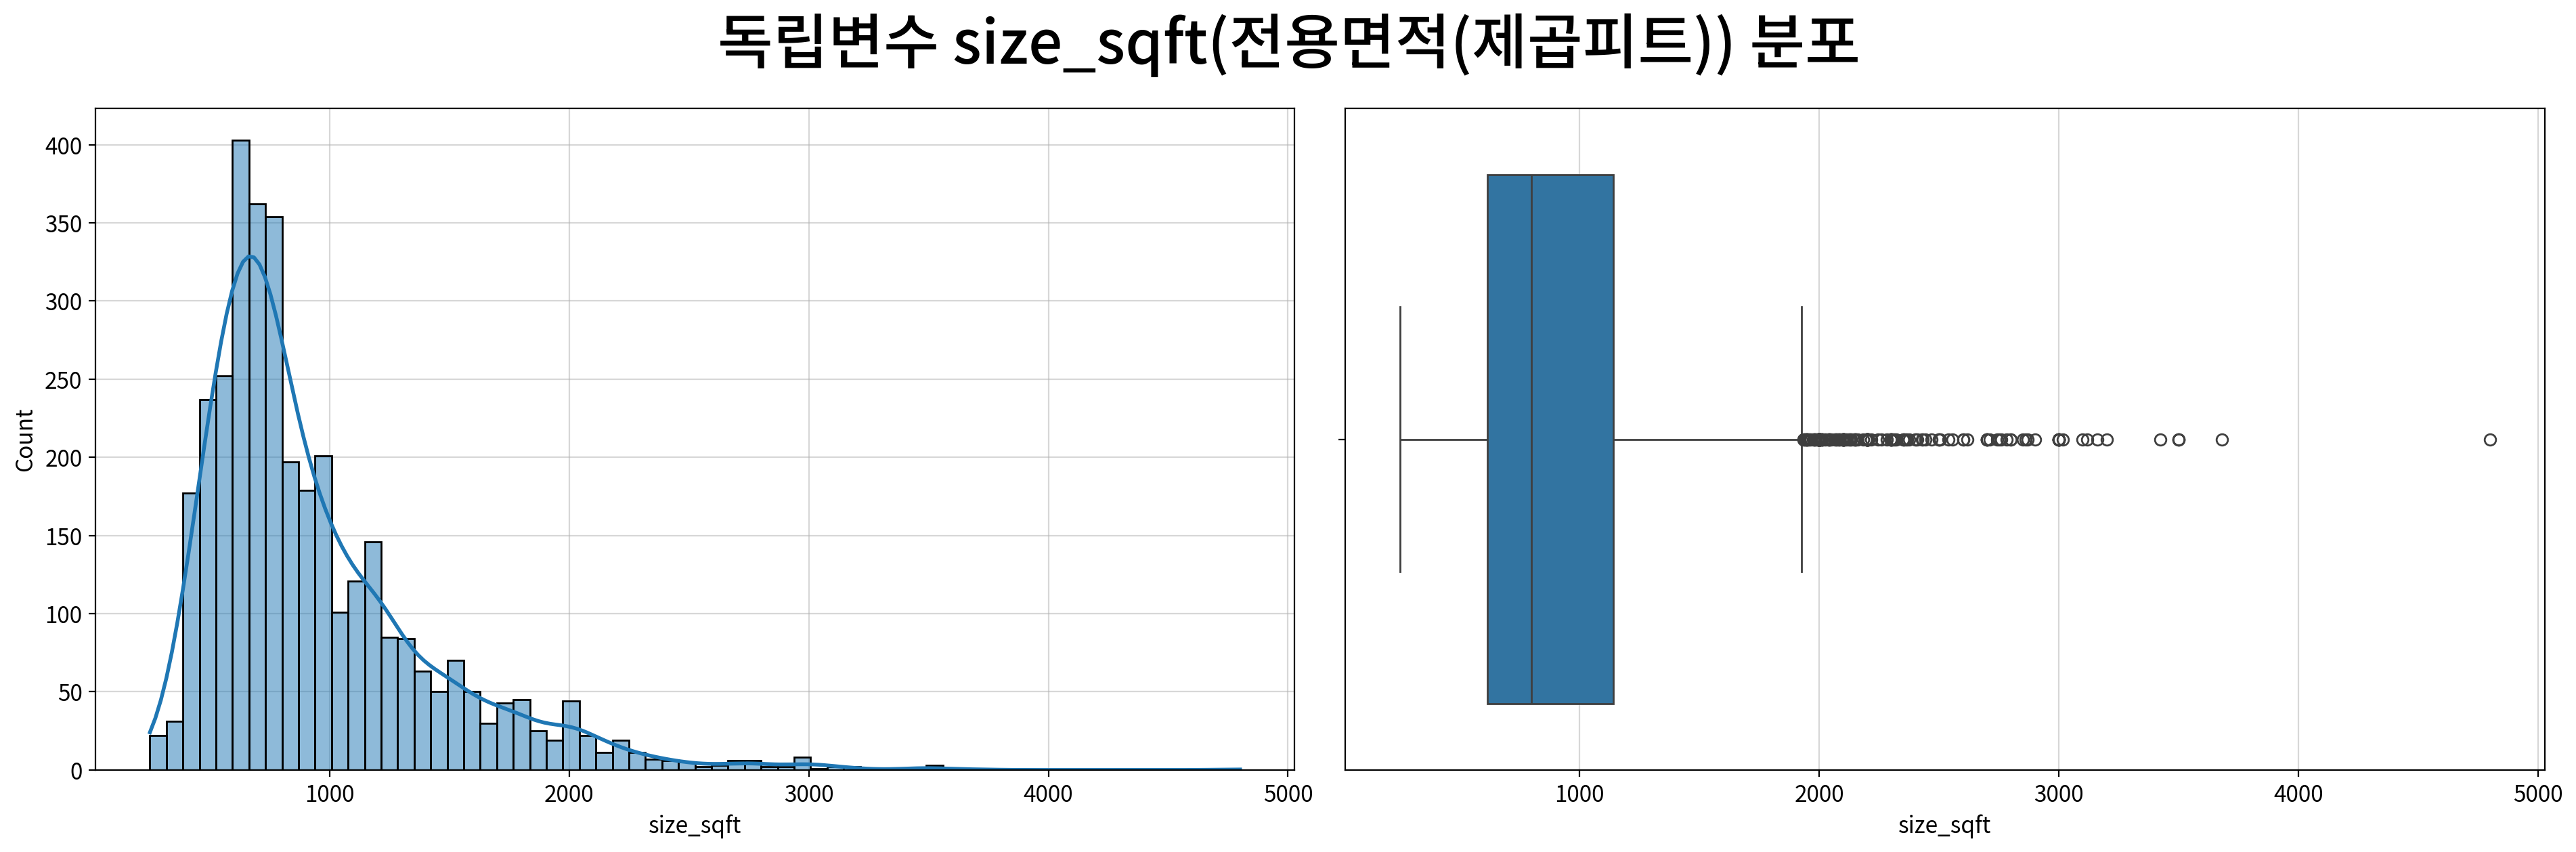

,size_sqft
count,3512
mean,940.287
std,478.290
min,250
25%,615.000
50%,800
75%,1141.500
max,4800
rel_diff,0.175
rdiff_flag,diff


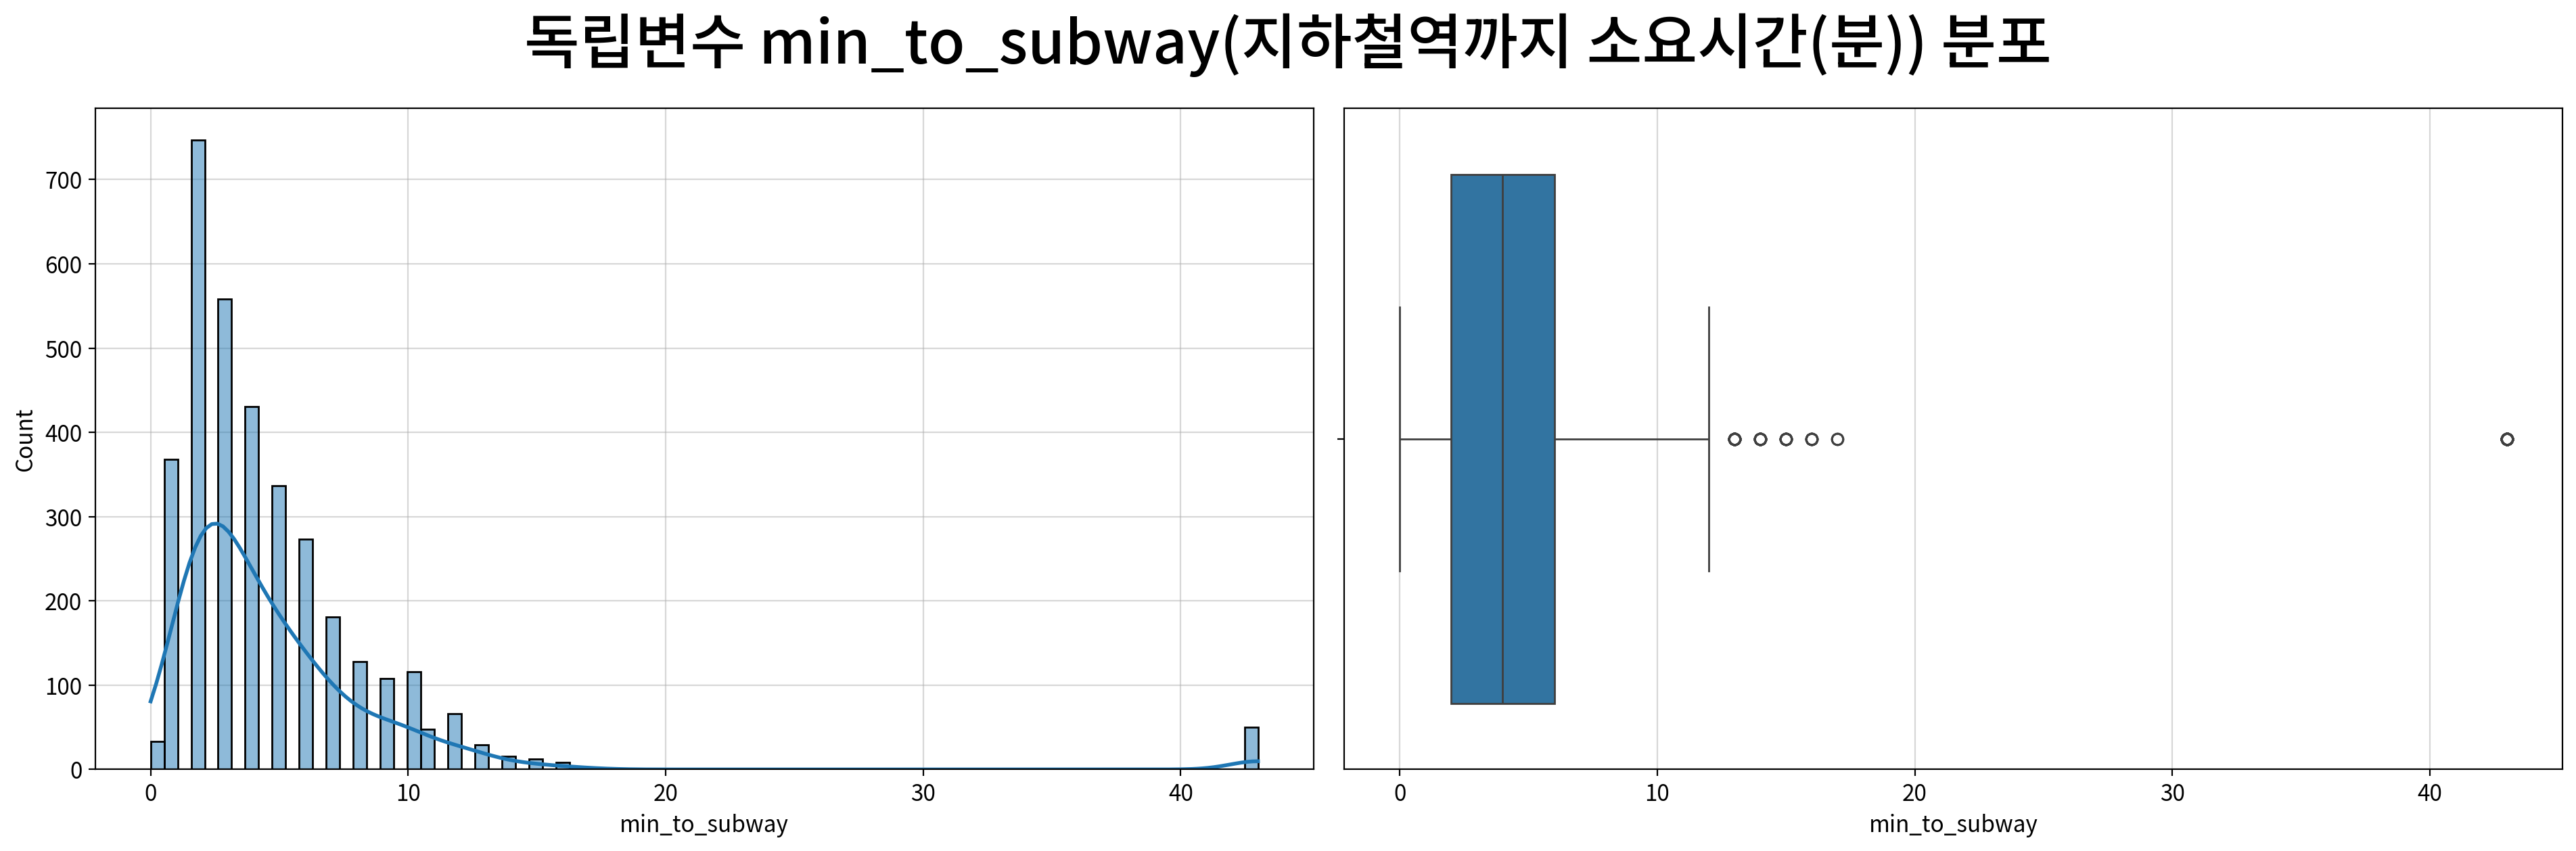

,min_to_subway
count,3512
mean,4.965
std,5.489
min,0
25%,2.000
50%,4
75%,6.000
max,43
rel_diff,0.241
rdiff_flag,diff


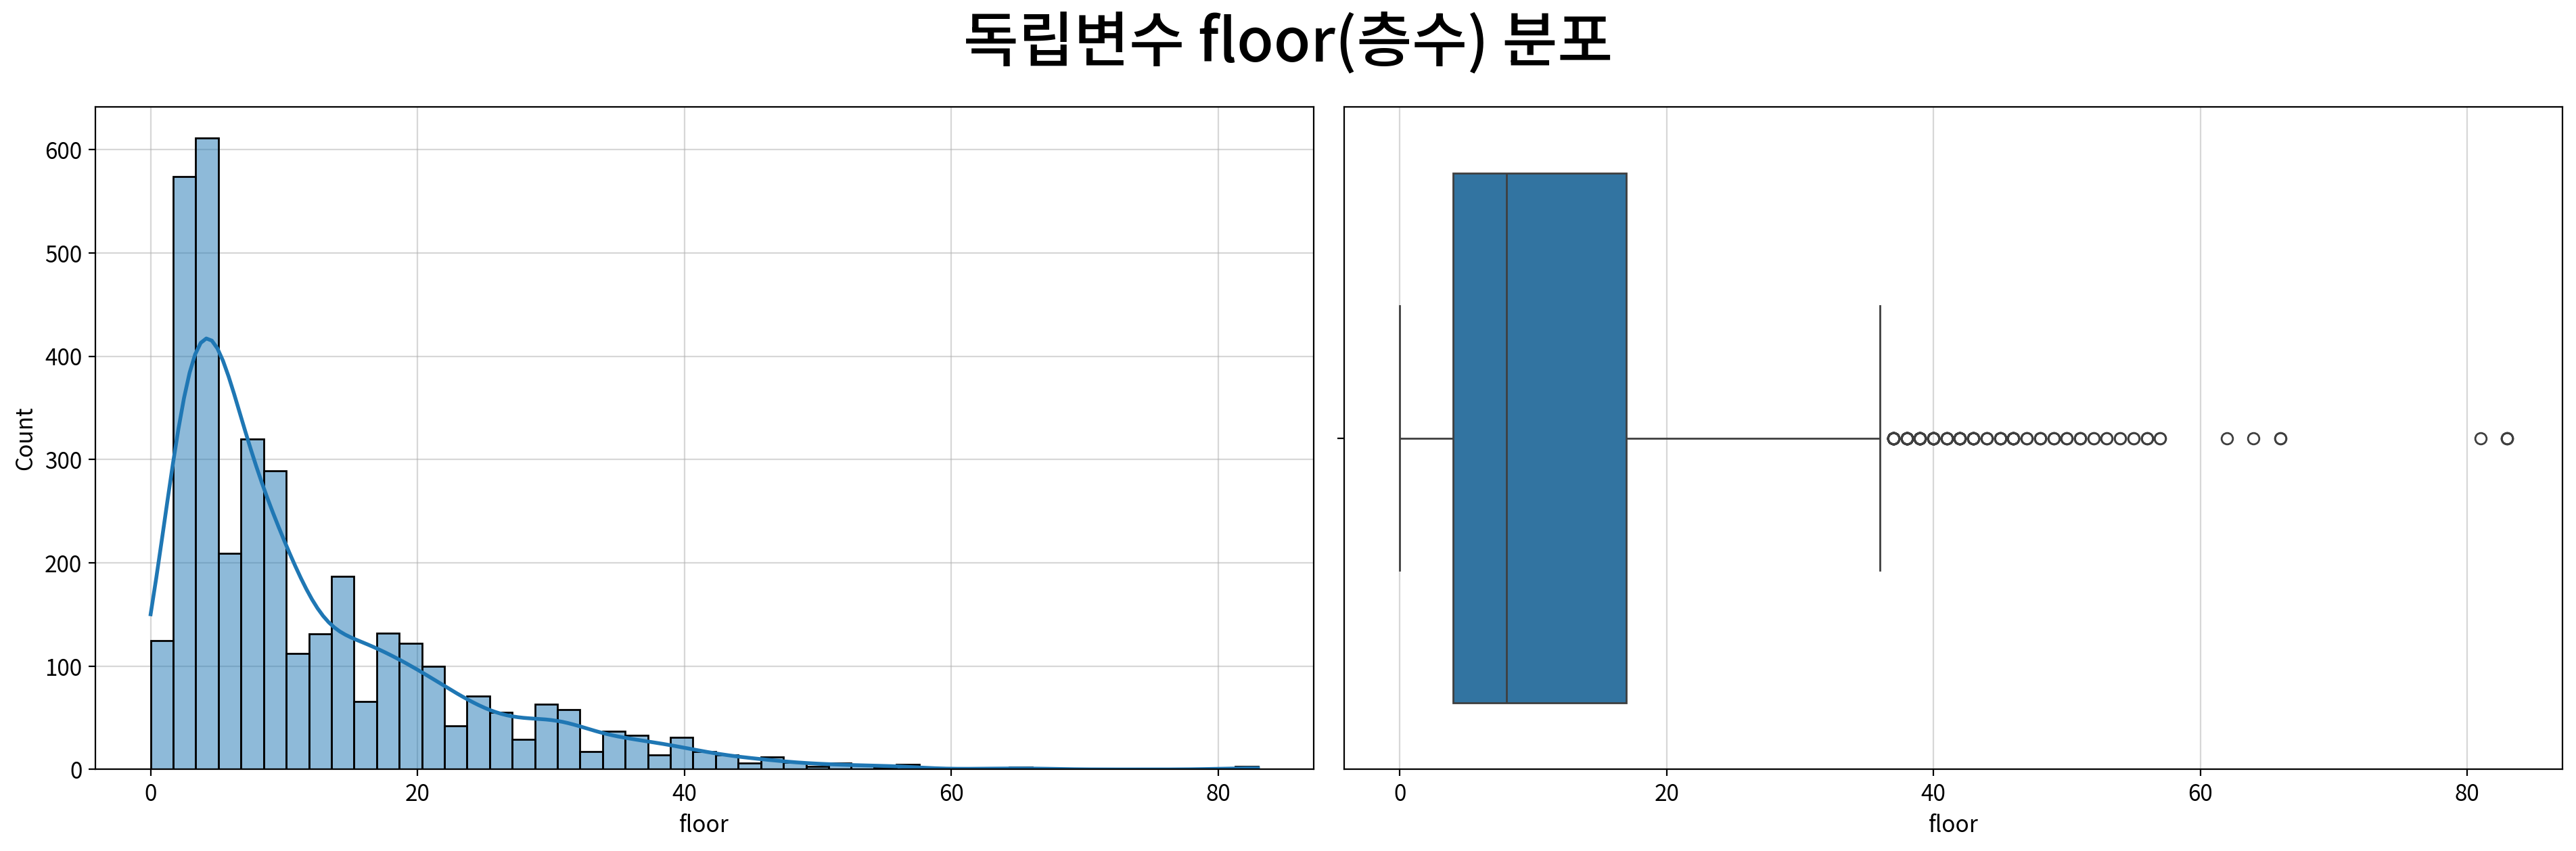

,floor
count,3512
mean,11.887
std,10.928
min,0
25%,4.000
50%,8
75%,17.000
max,83
rel_diff,0.486
rdiff_flag,diff


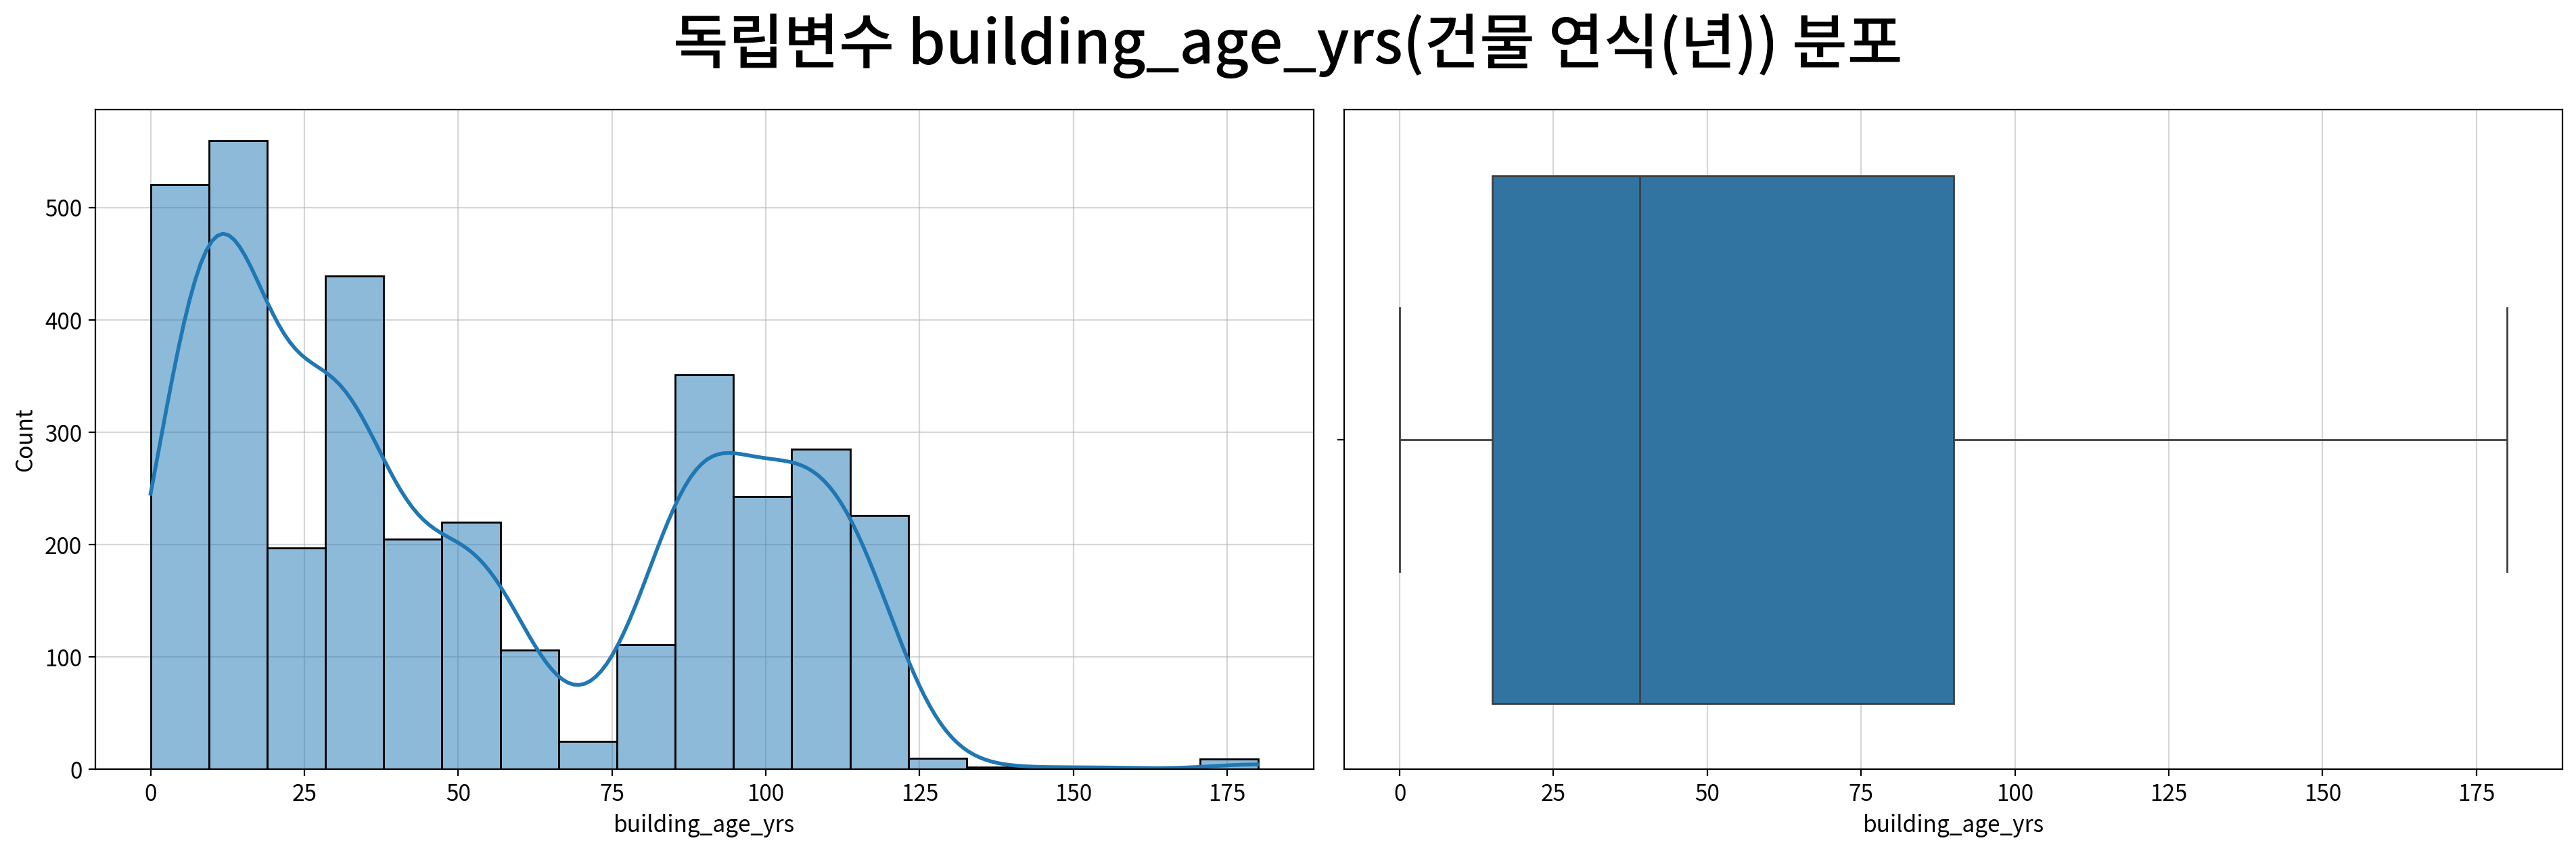

,building_age_yrs
count,3512
mean,51.958
std,39.420
min,0
25%,15.000
50%,39
75%,90.000
max,180
rel_diff,0.332
rdiff_flag,diff


In [19]:
# 2. 연속형 독립변수에 대한 단변량 분석

for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                           title=f"독립변수 {f}({column_means[f]}) 분포")

    my_plot.histplot(data=df3, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df3, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

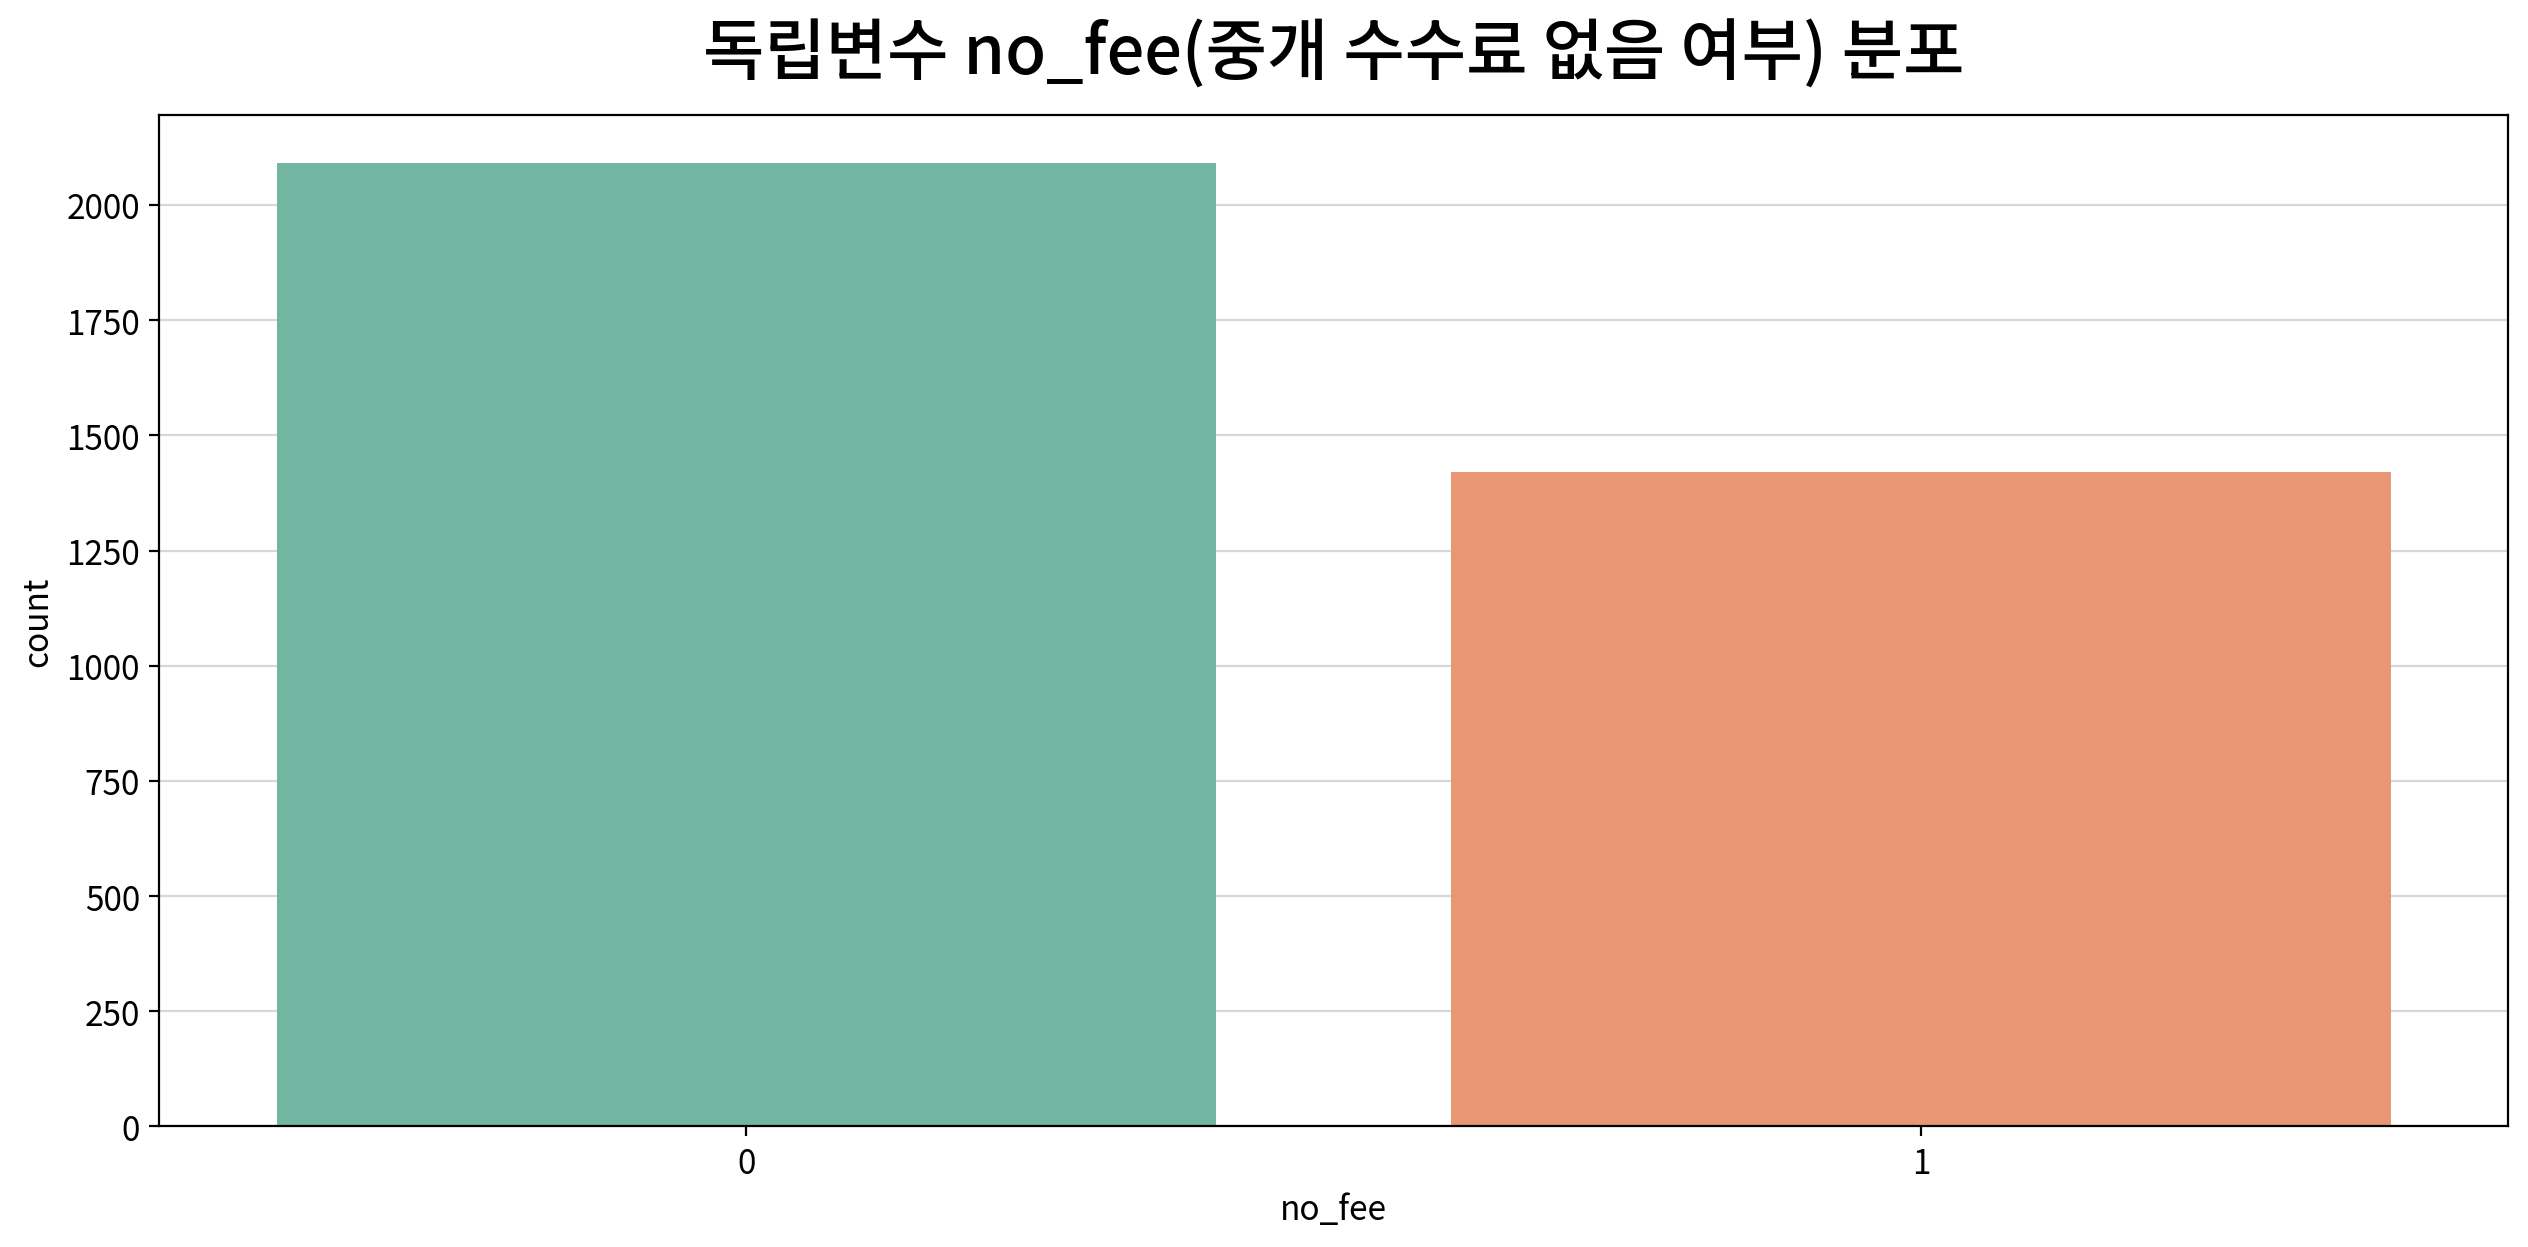

,count,unique,top,freq
no_fee,3512,2,0,2091


,빈도,비율
no_fee,,
0,2091,0.595
1,1421,0.405


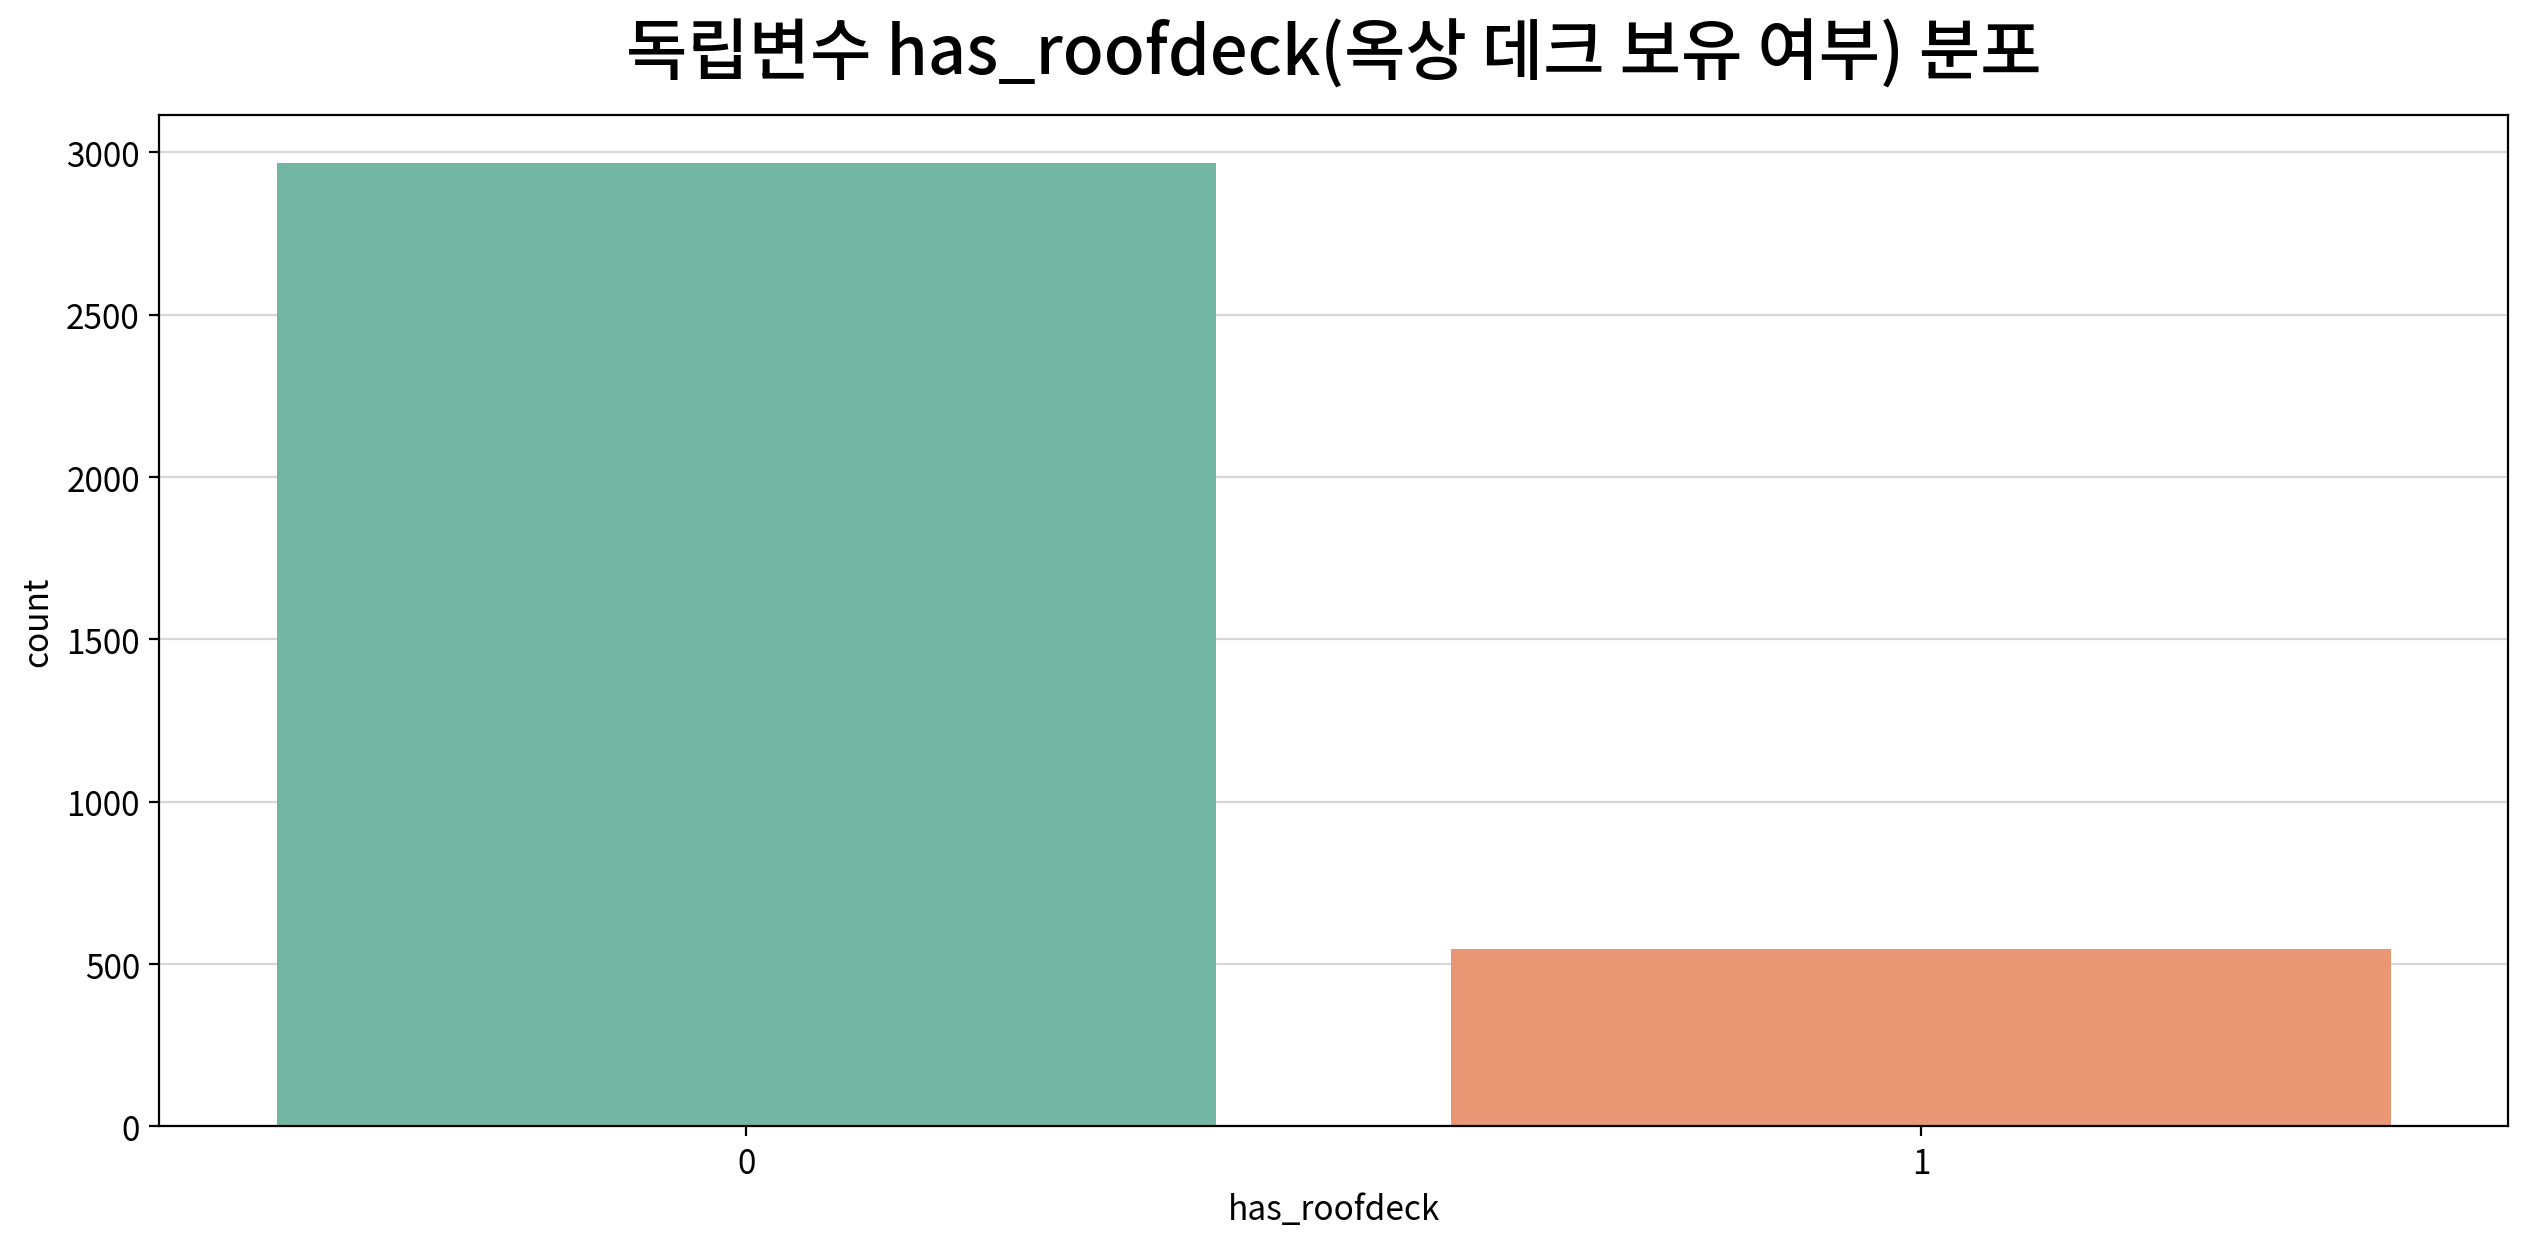

,count,unique,top,freq
has_roofdeck,3512,2,0,2967


,빈도,비율
has_roofdeck,,
0,2967,0.845
1,545,0.155


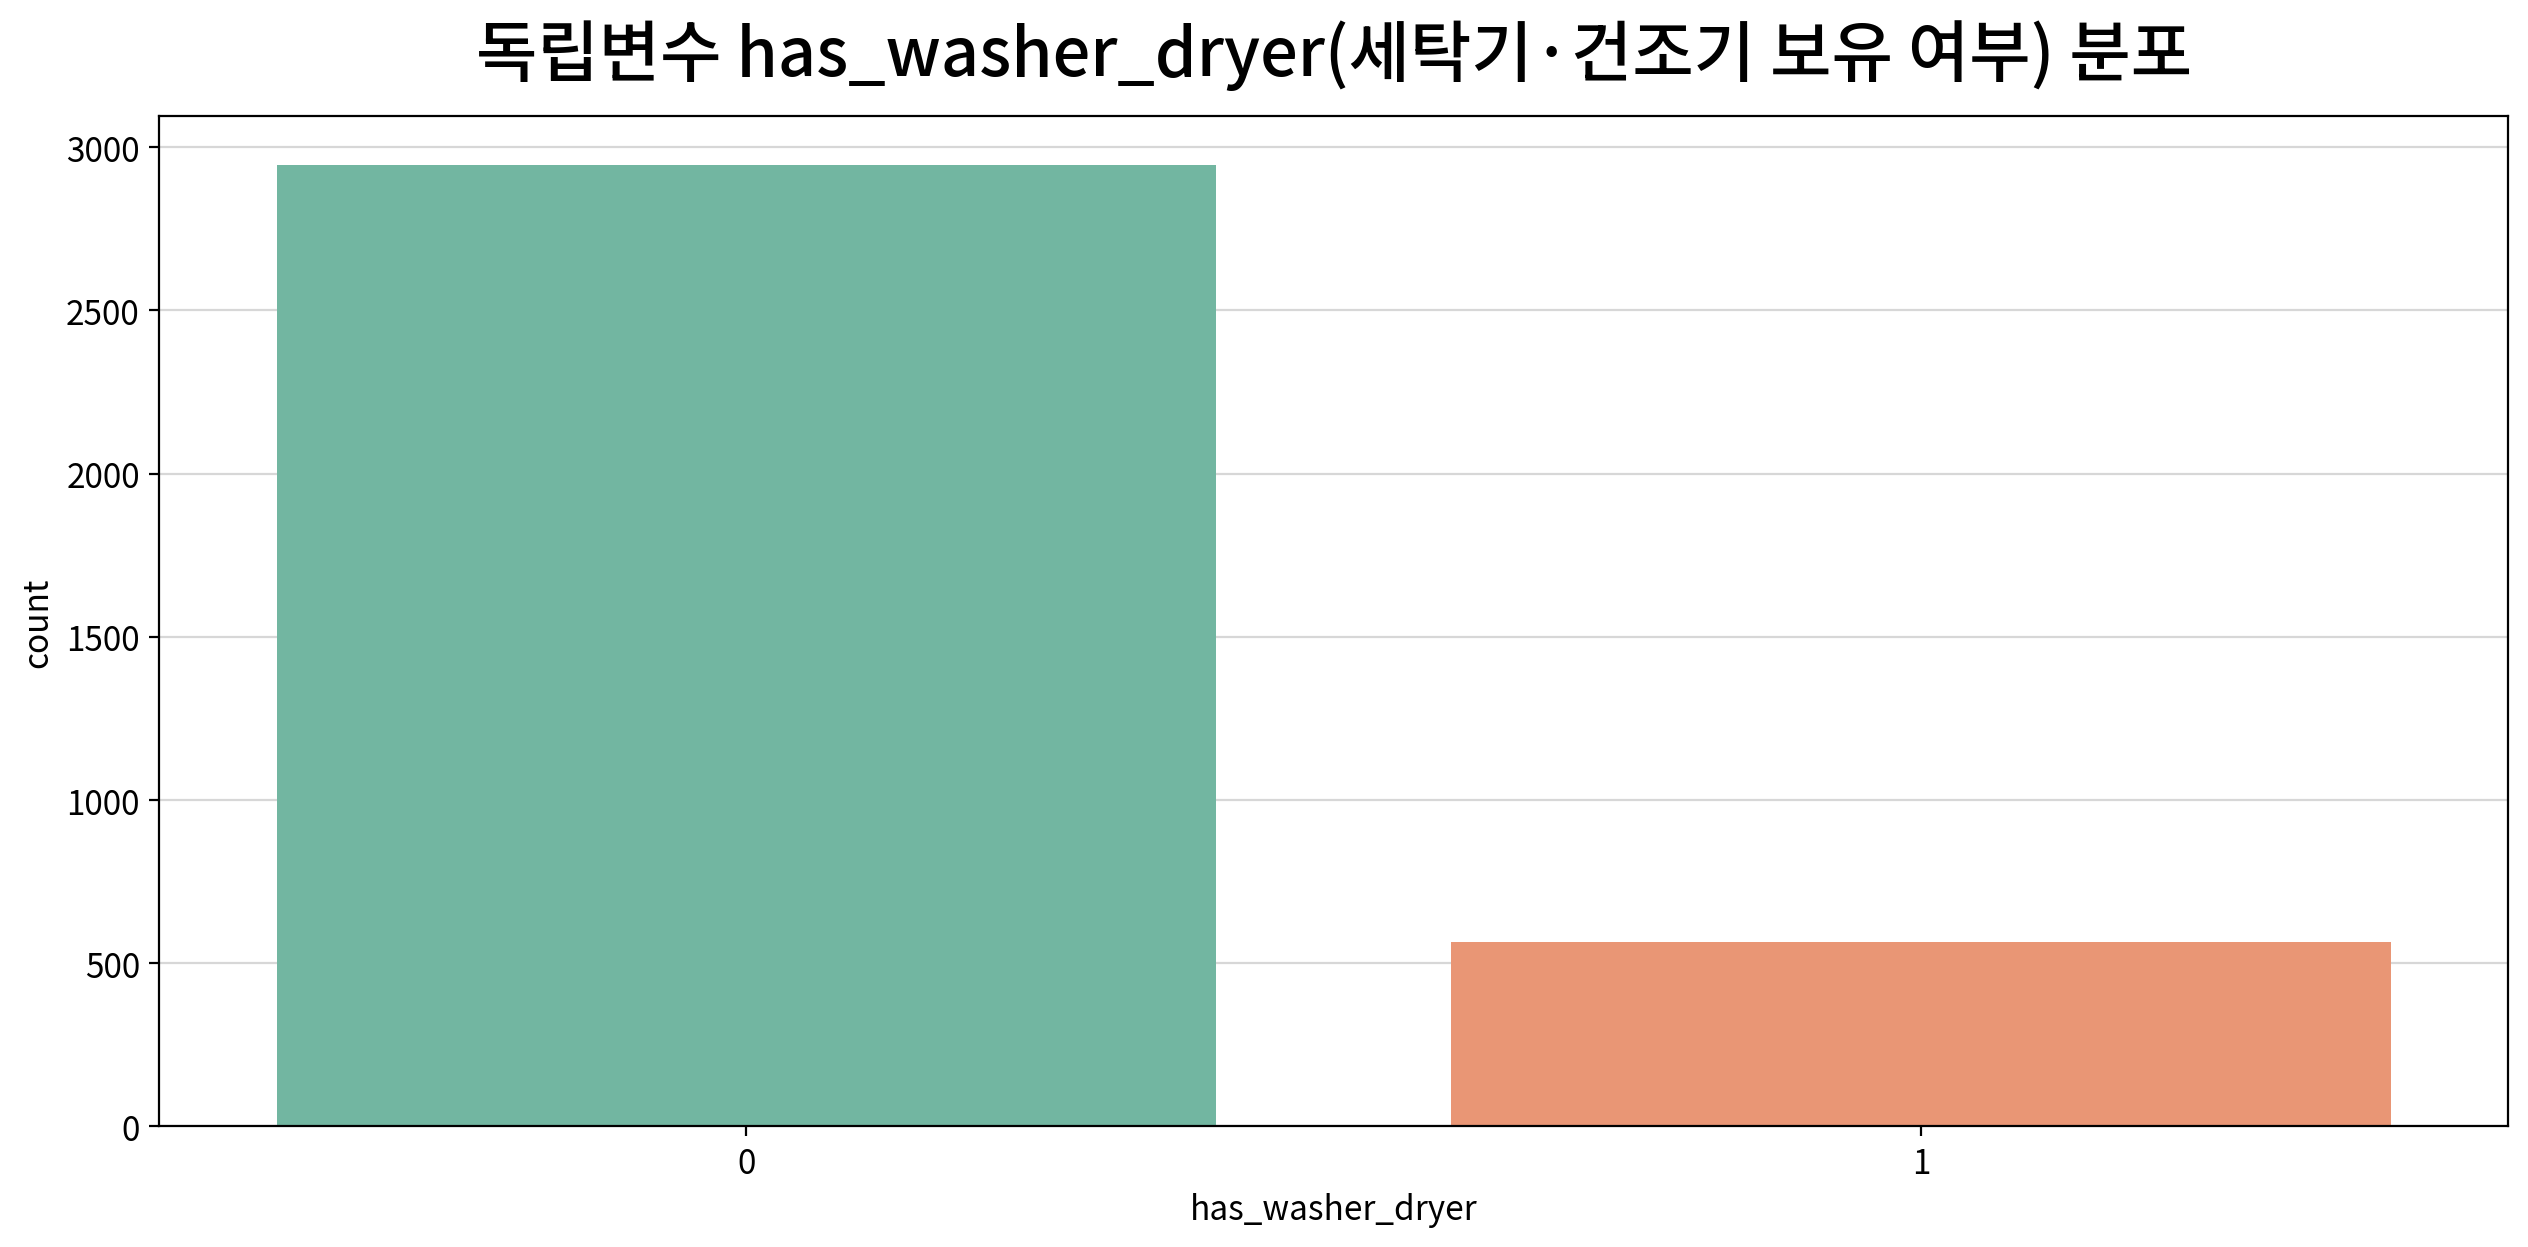

,count,unique,top,freq
has_washer_dryer,3512,2,0,2947


,빈도,비율
has_washer_dryer,,
0,2947,0.839
1,565,0.161


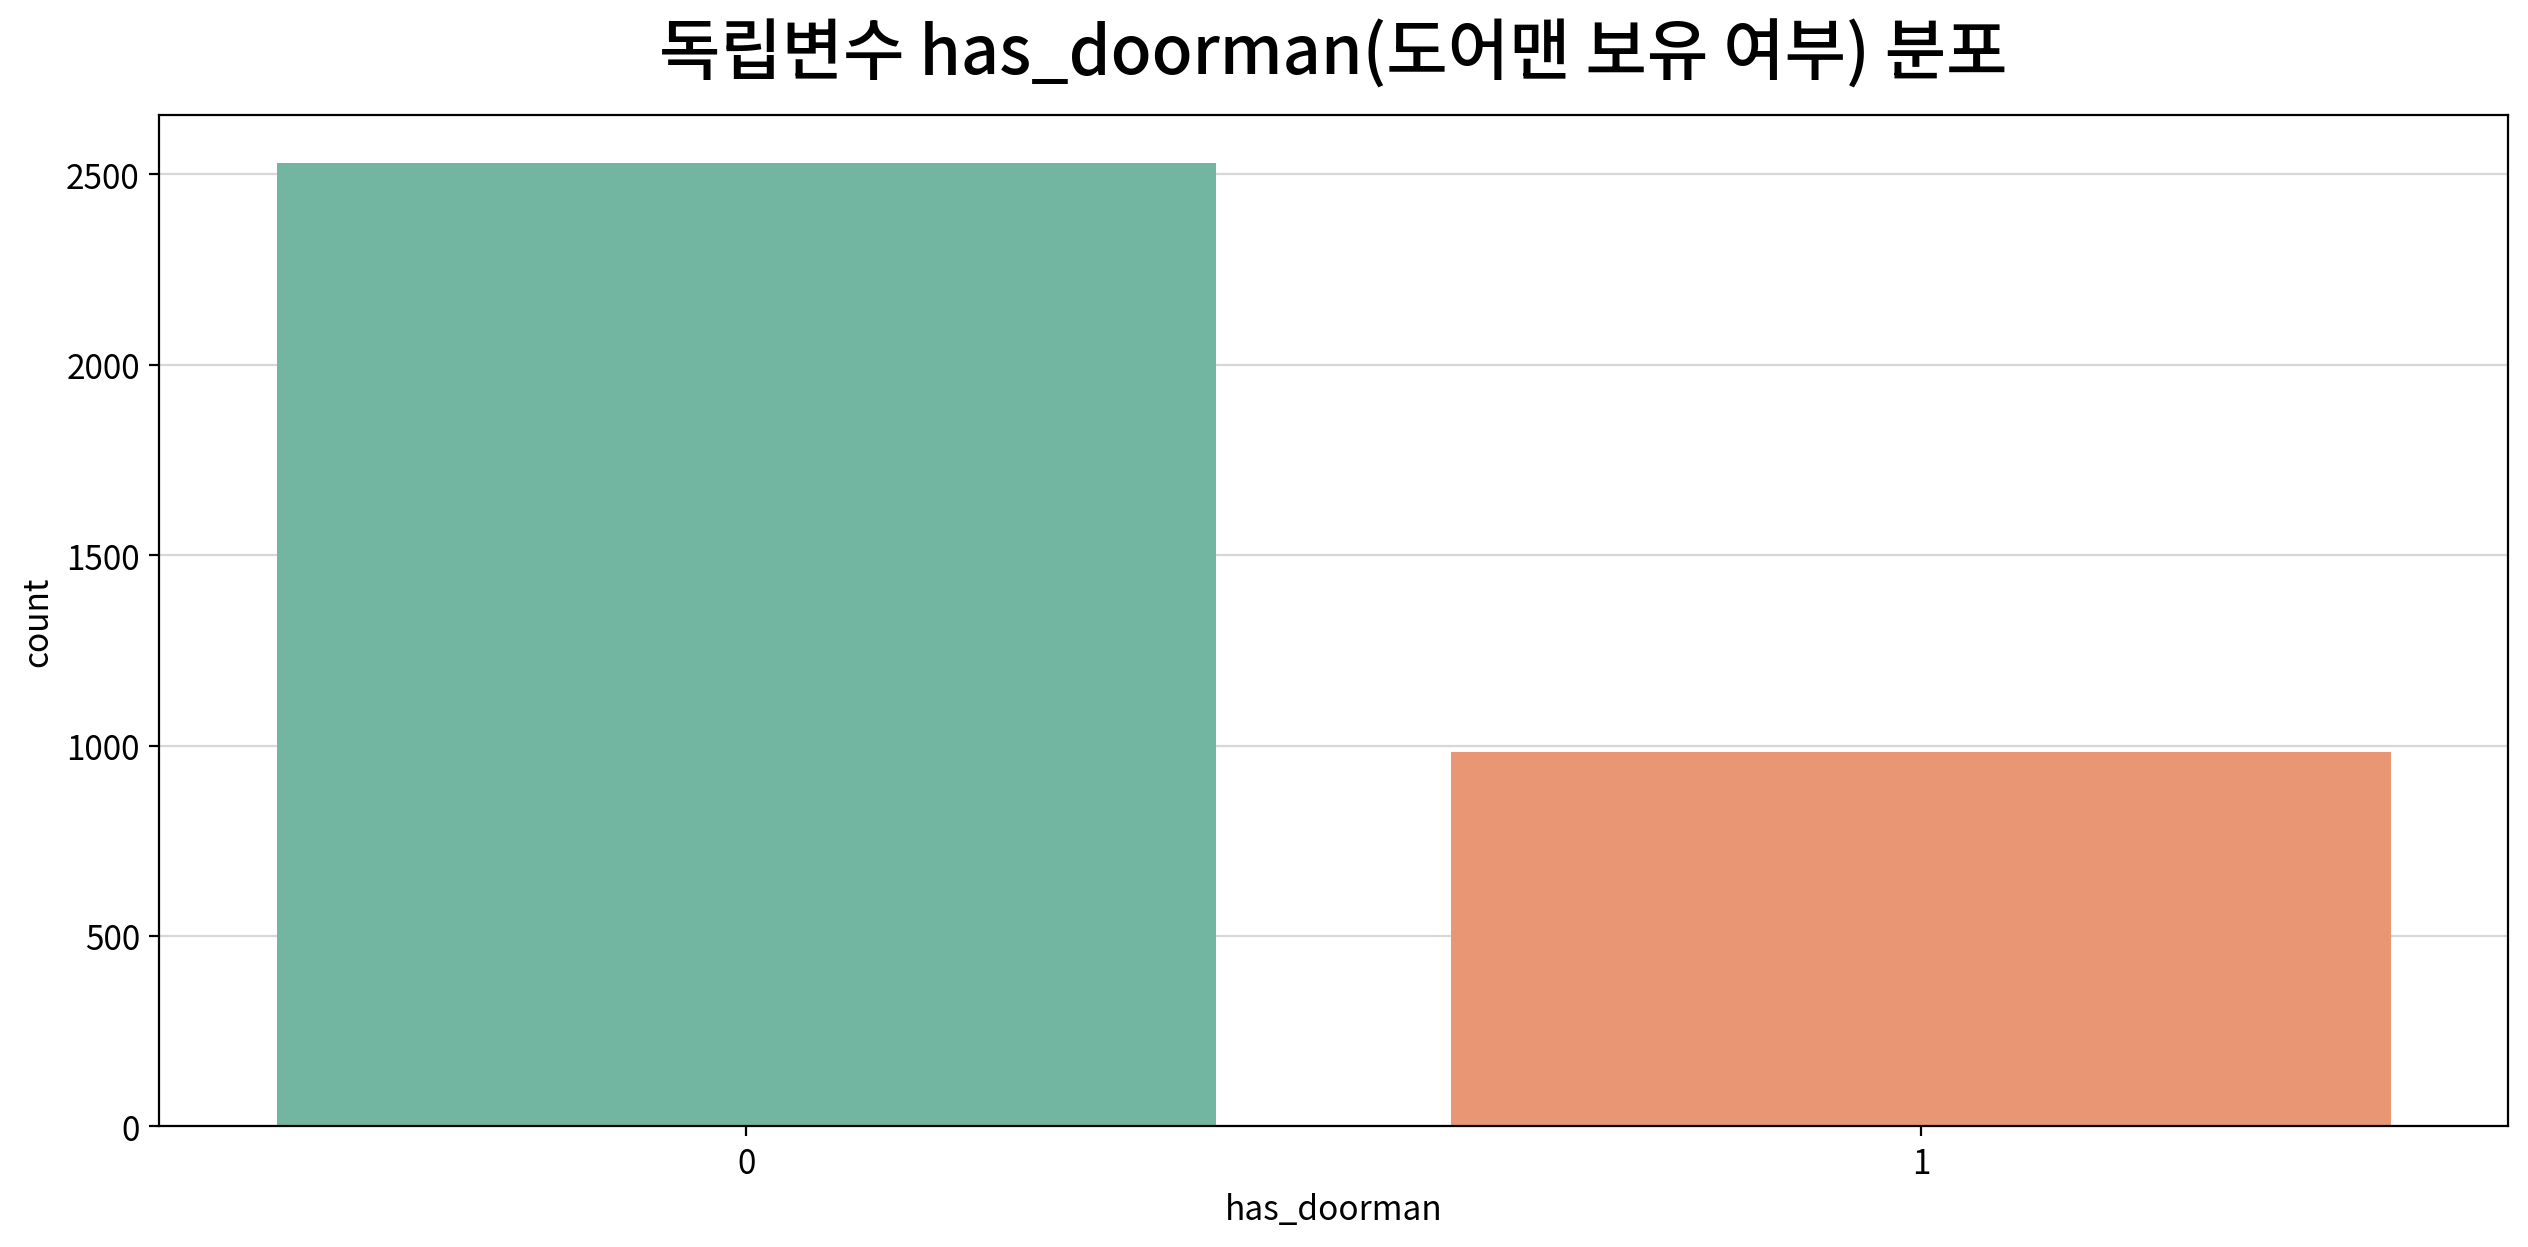

,count,unique,top,freq
has_doorman,3512,2,0,2529


,빈도,비율
has_doorman,,
0,2529,0.720
1,983,0.280


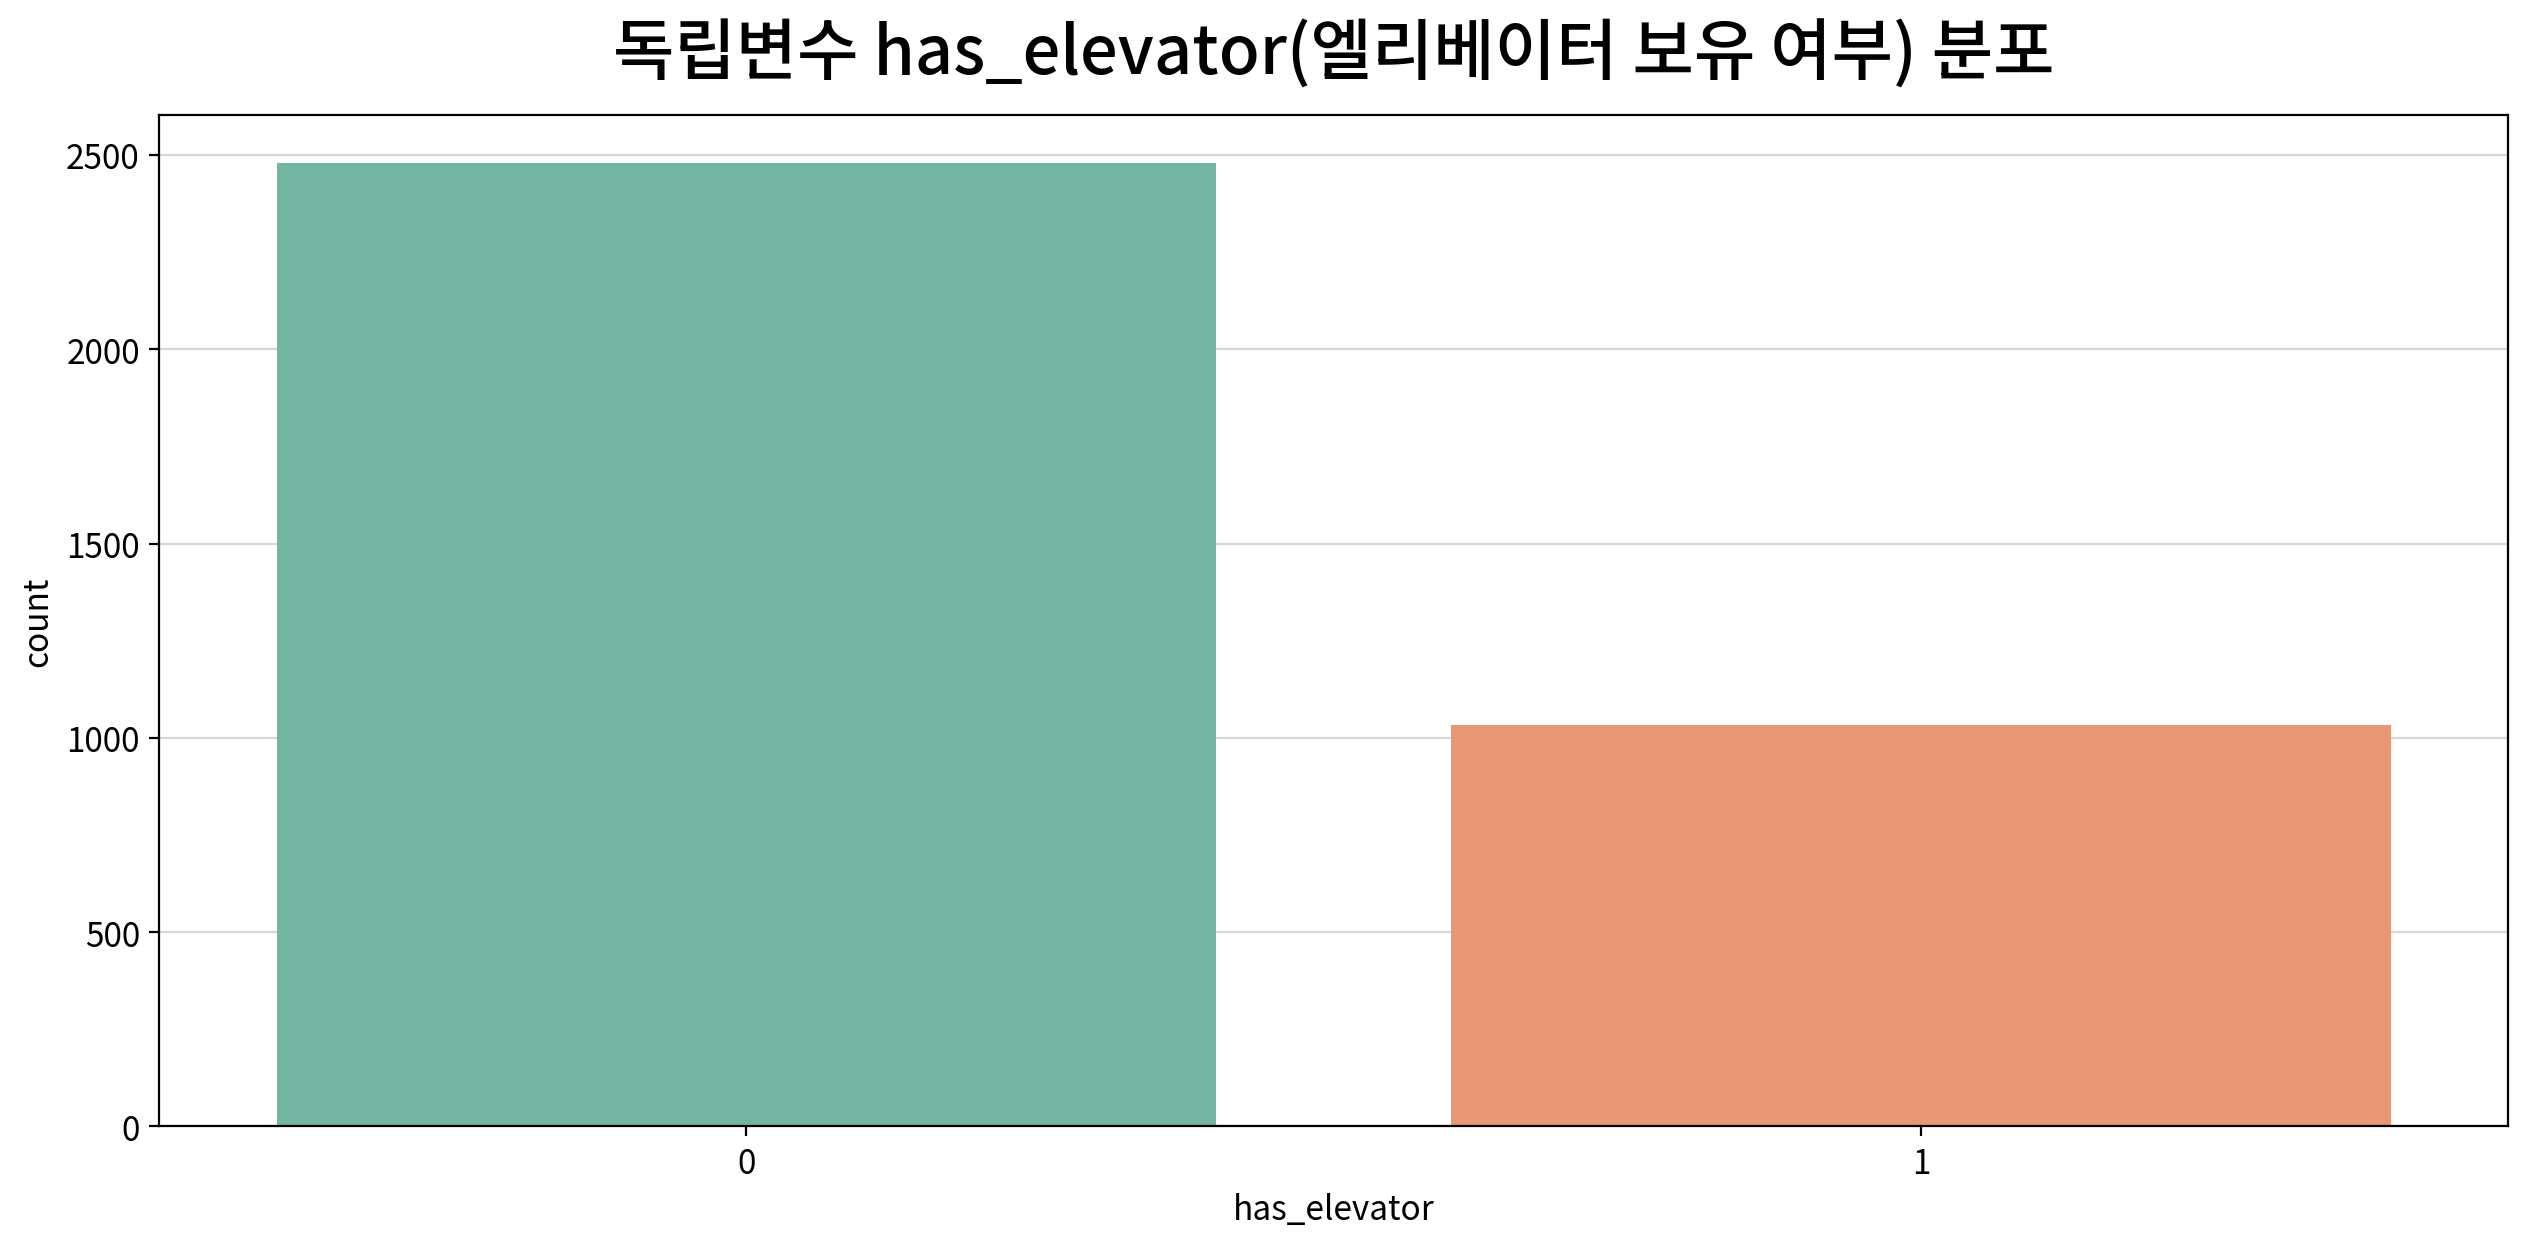

,count,unique,top,freq
has_elevator,3512,2,0,2479


,빈도,비율
has_elevator,,
0,2479,0.706
1,1033,0.294


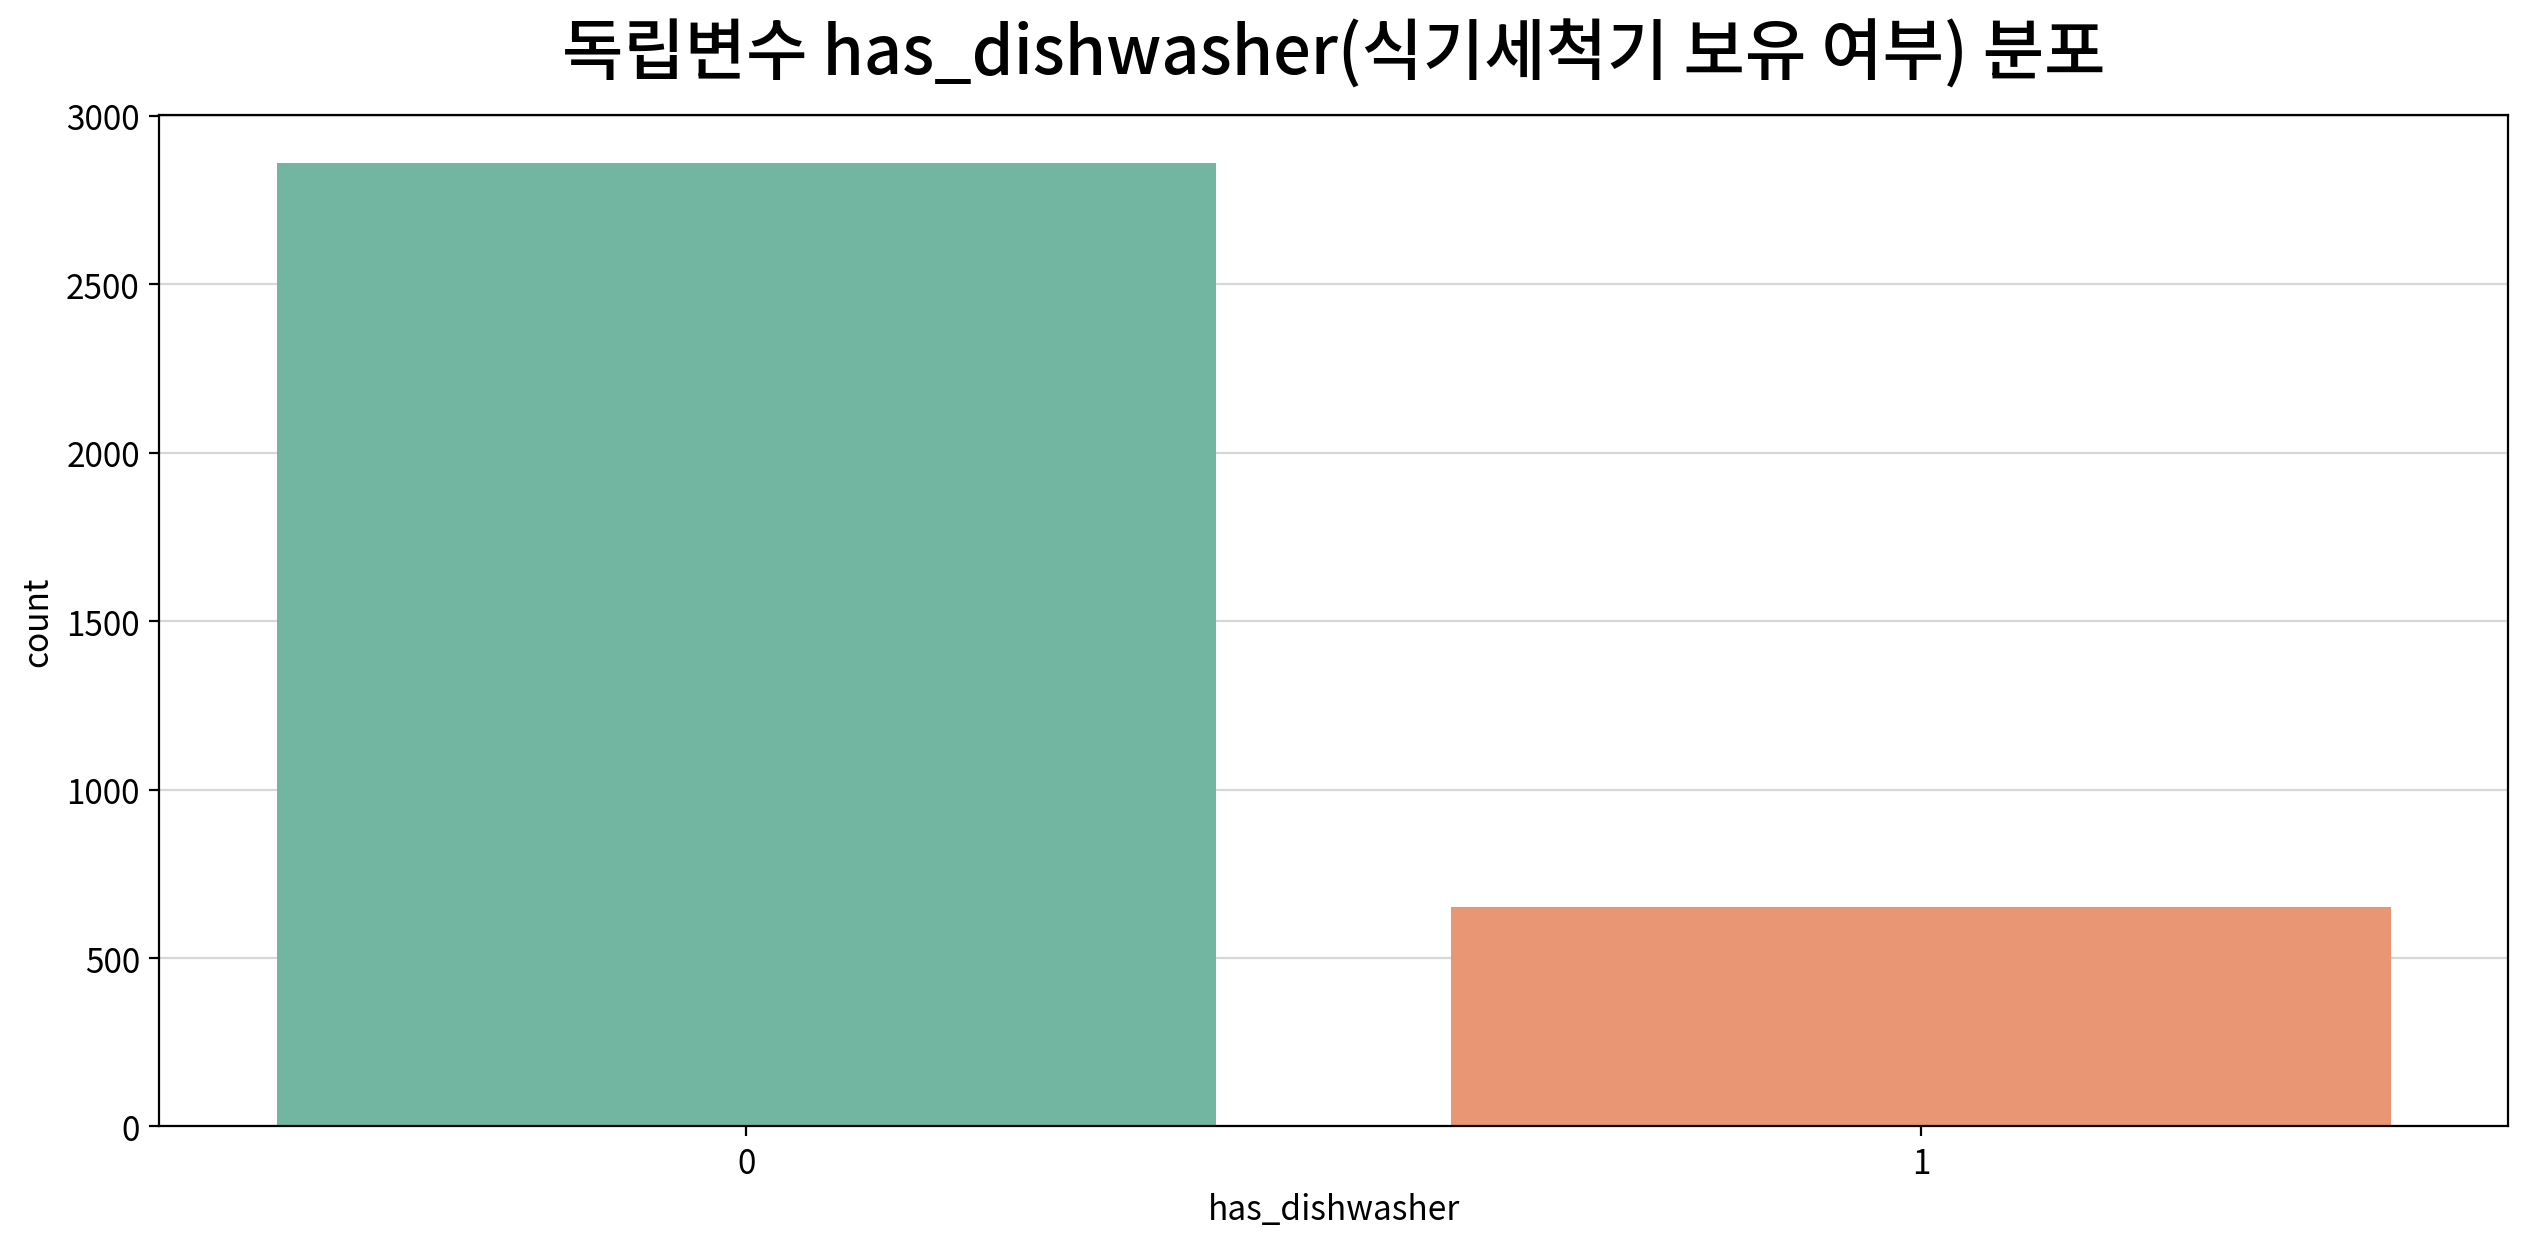

,count,unique,top,freq
has_dishwasher,3512,2,0,2860


,빈도,비율
has_dishwasher,,
0,2860,0.814
1,652,0.186


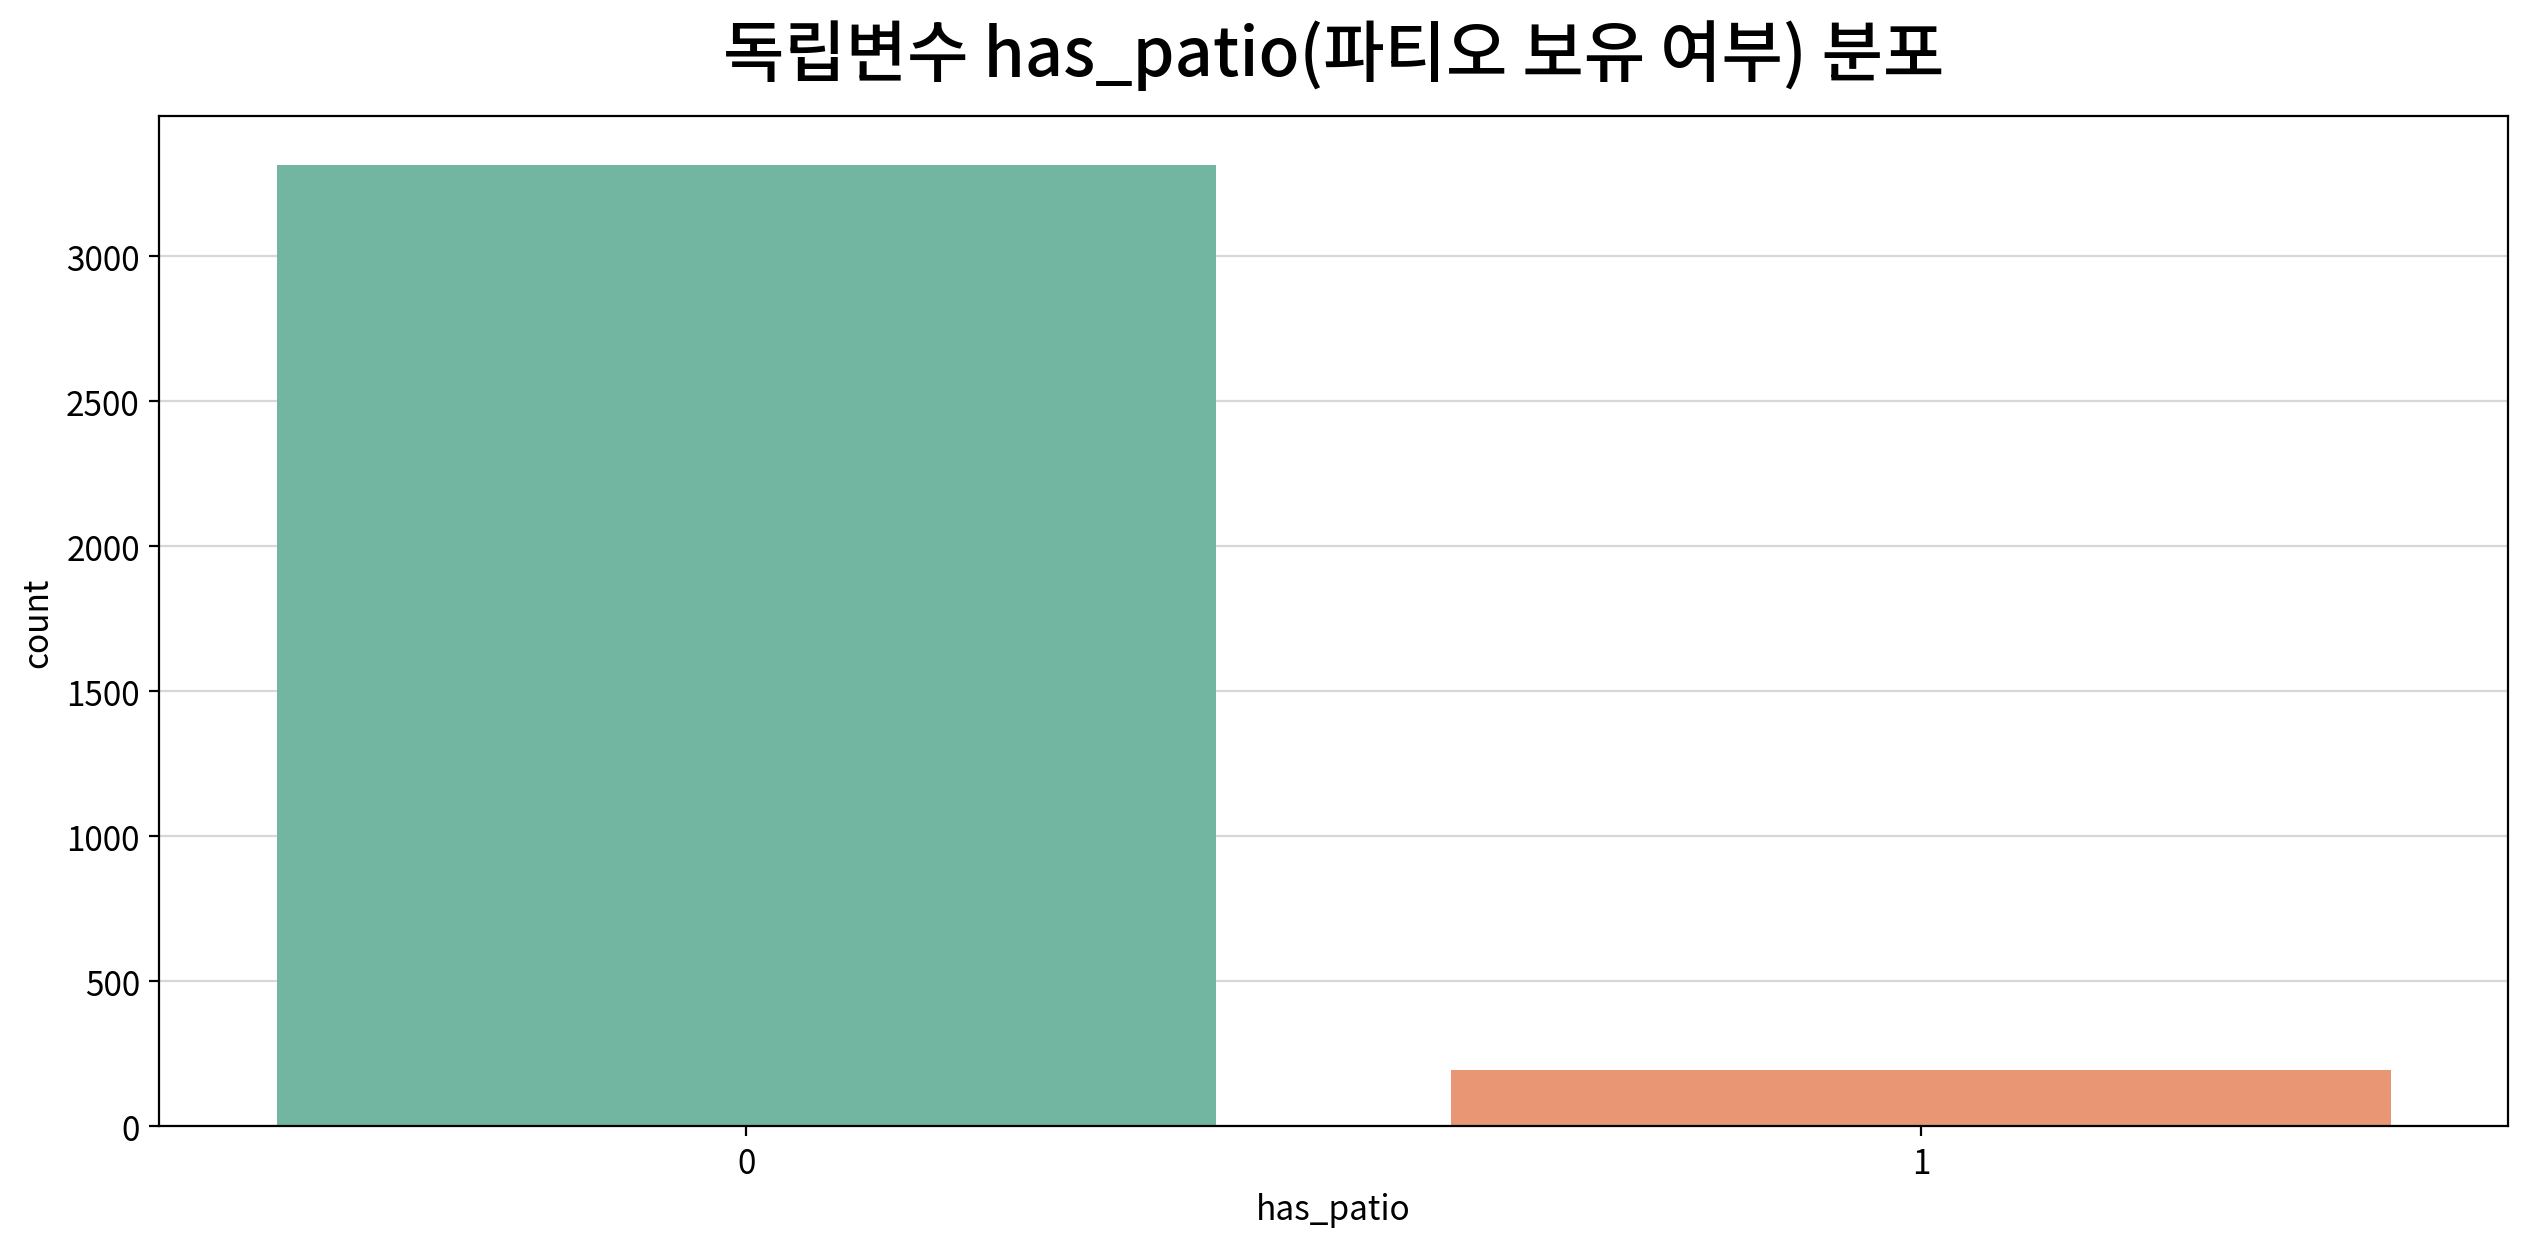

,count,unique,top,freq
has_patio,3512,2,0,3317


,빈도,비율
has_patio,,
0,3317,0.944
1,195,0.056


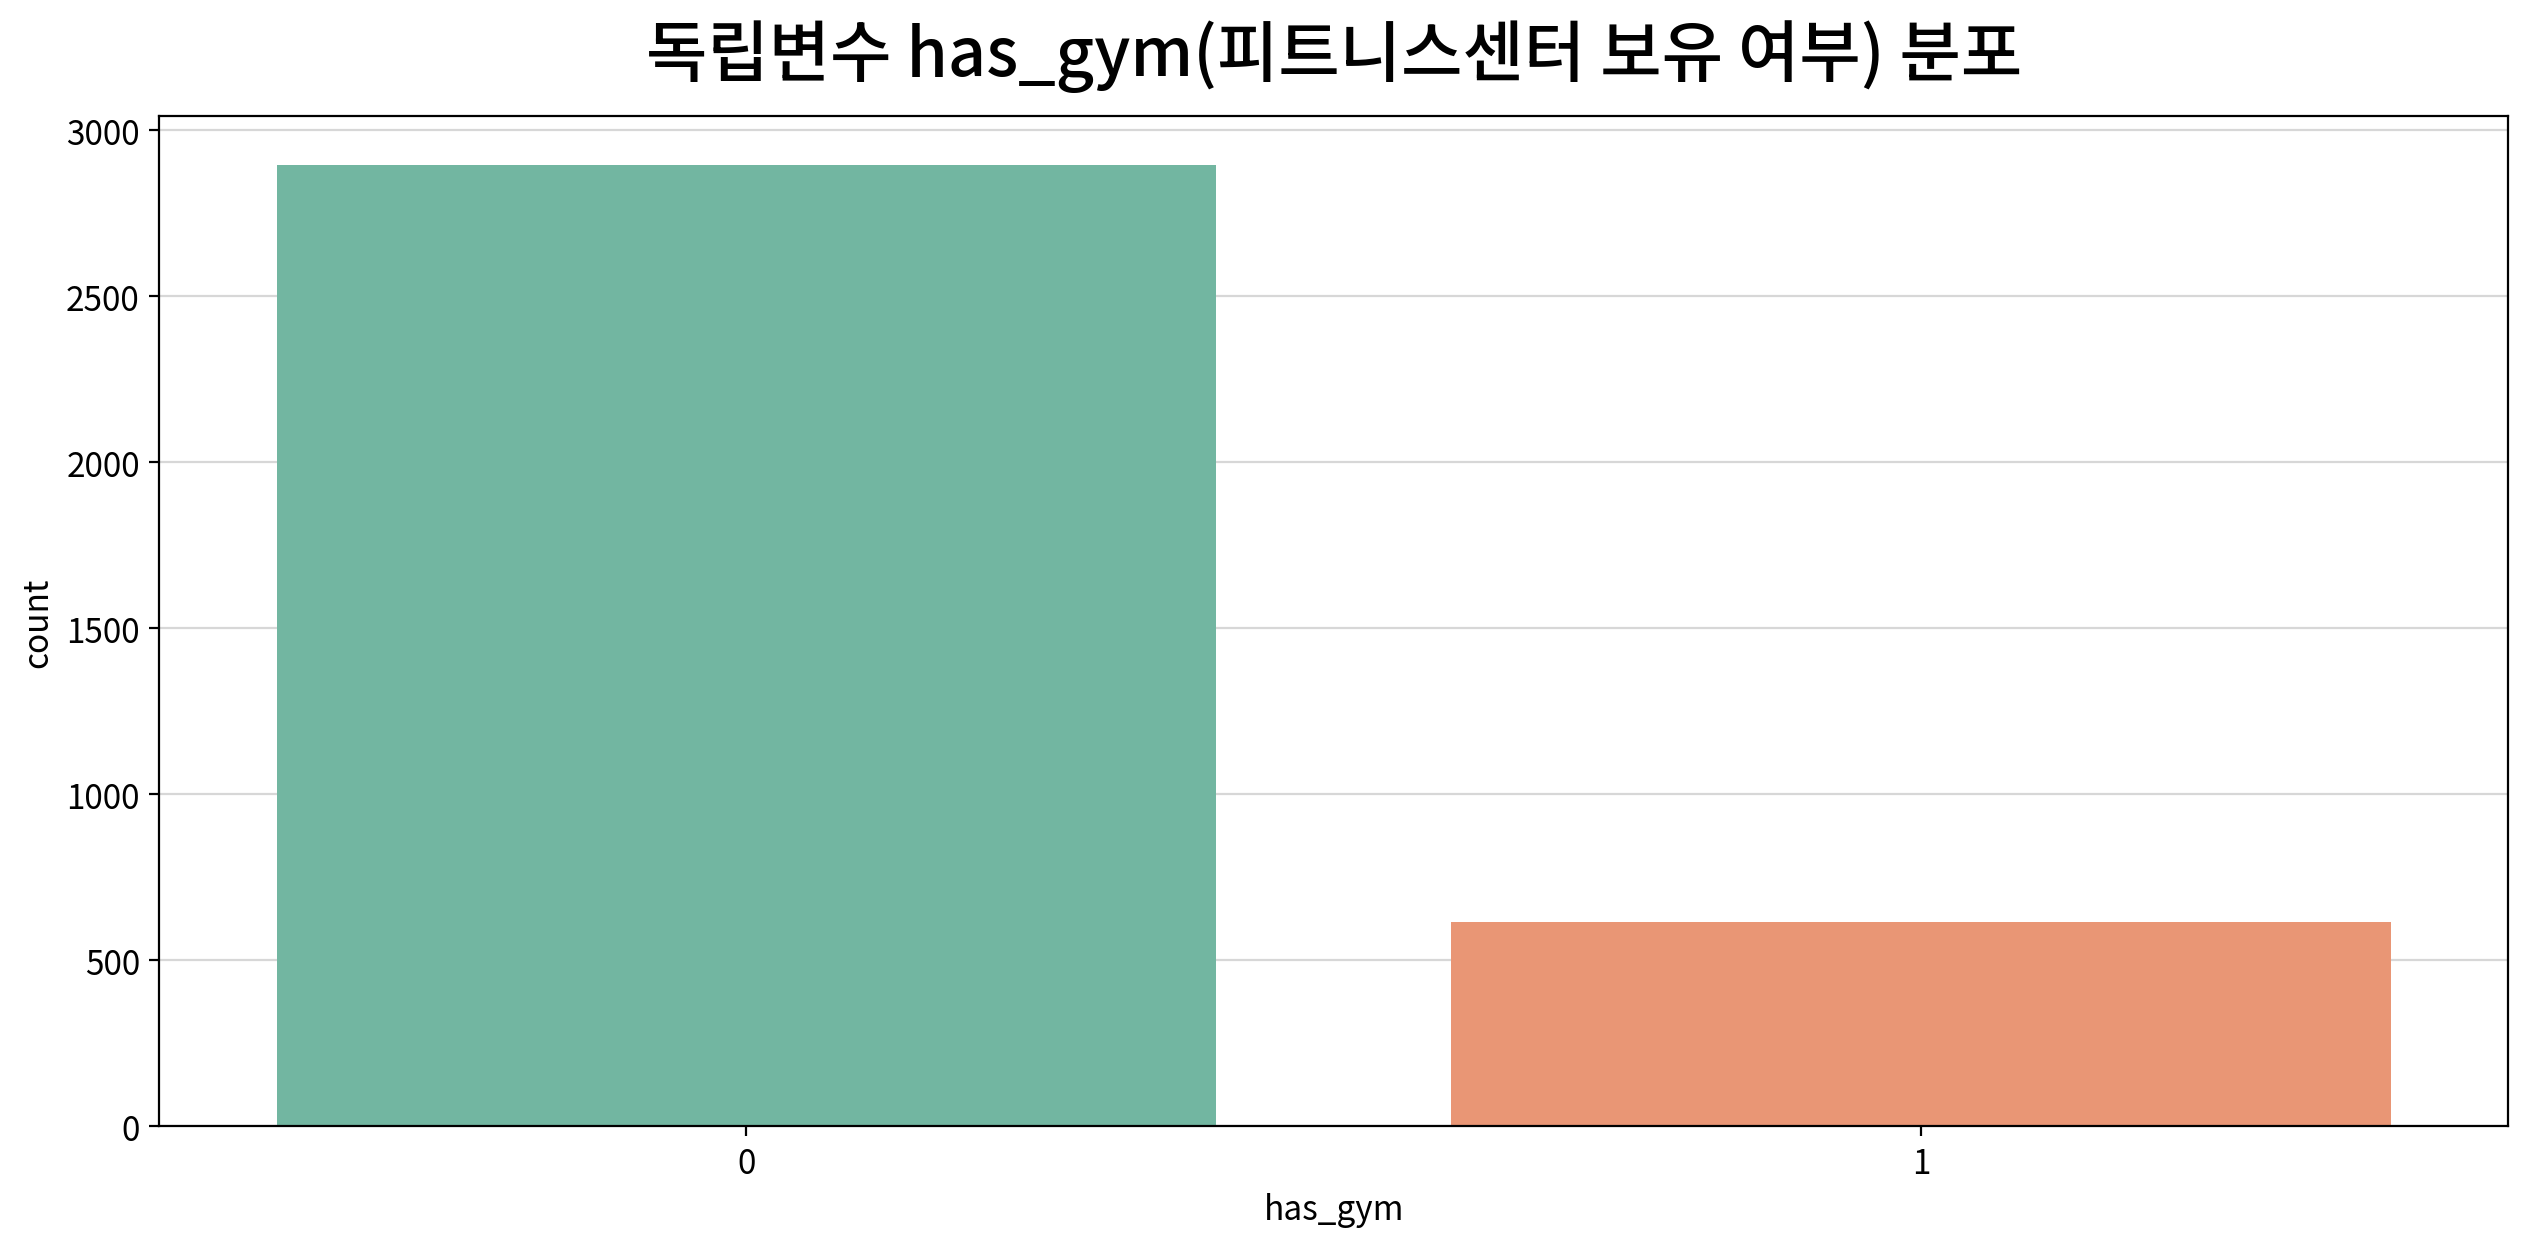

,count,unique,top,freq
has_gym,3512,2,0,2897


,빈도,비율
has_gym,,
0,2897,0.825
1,615,0.175


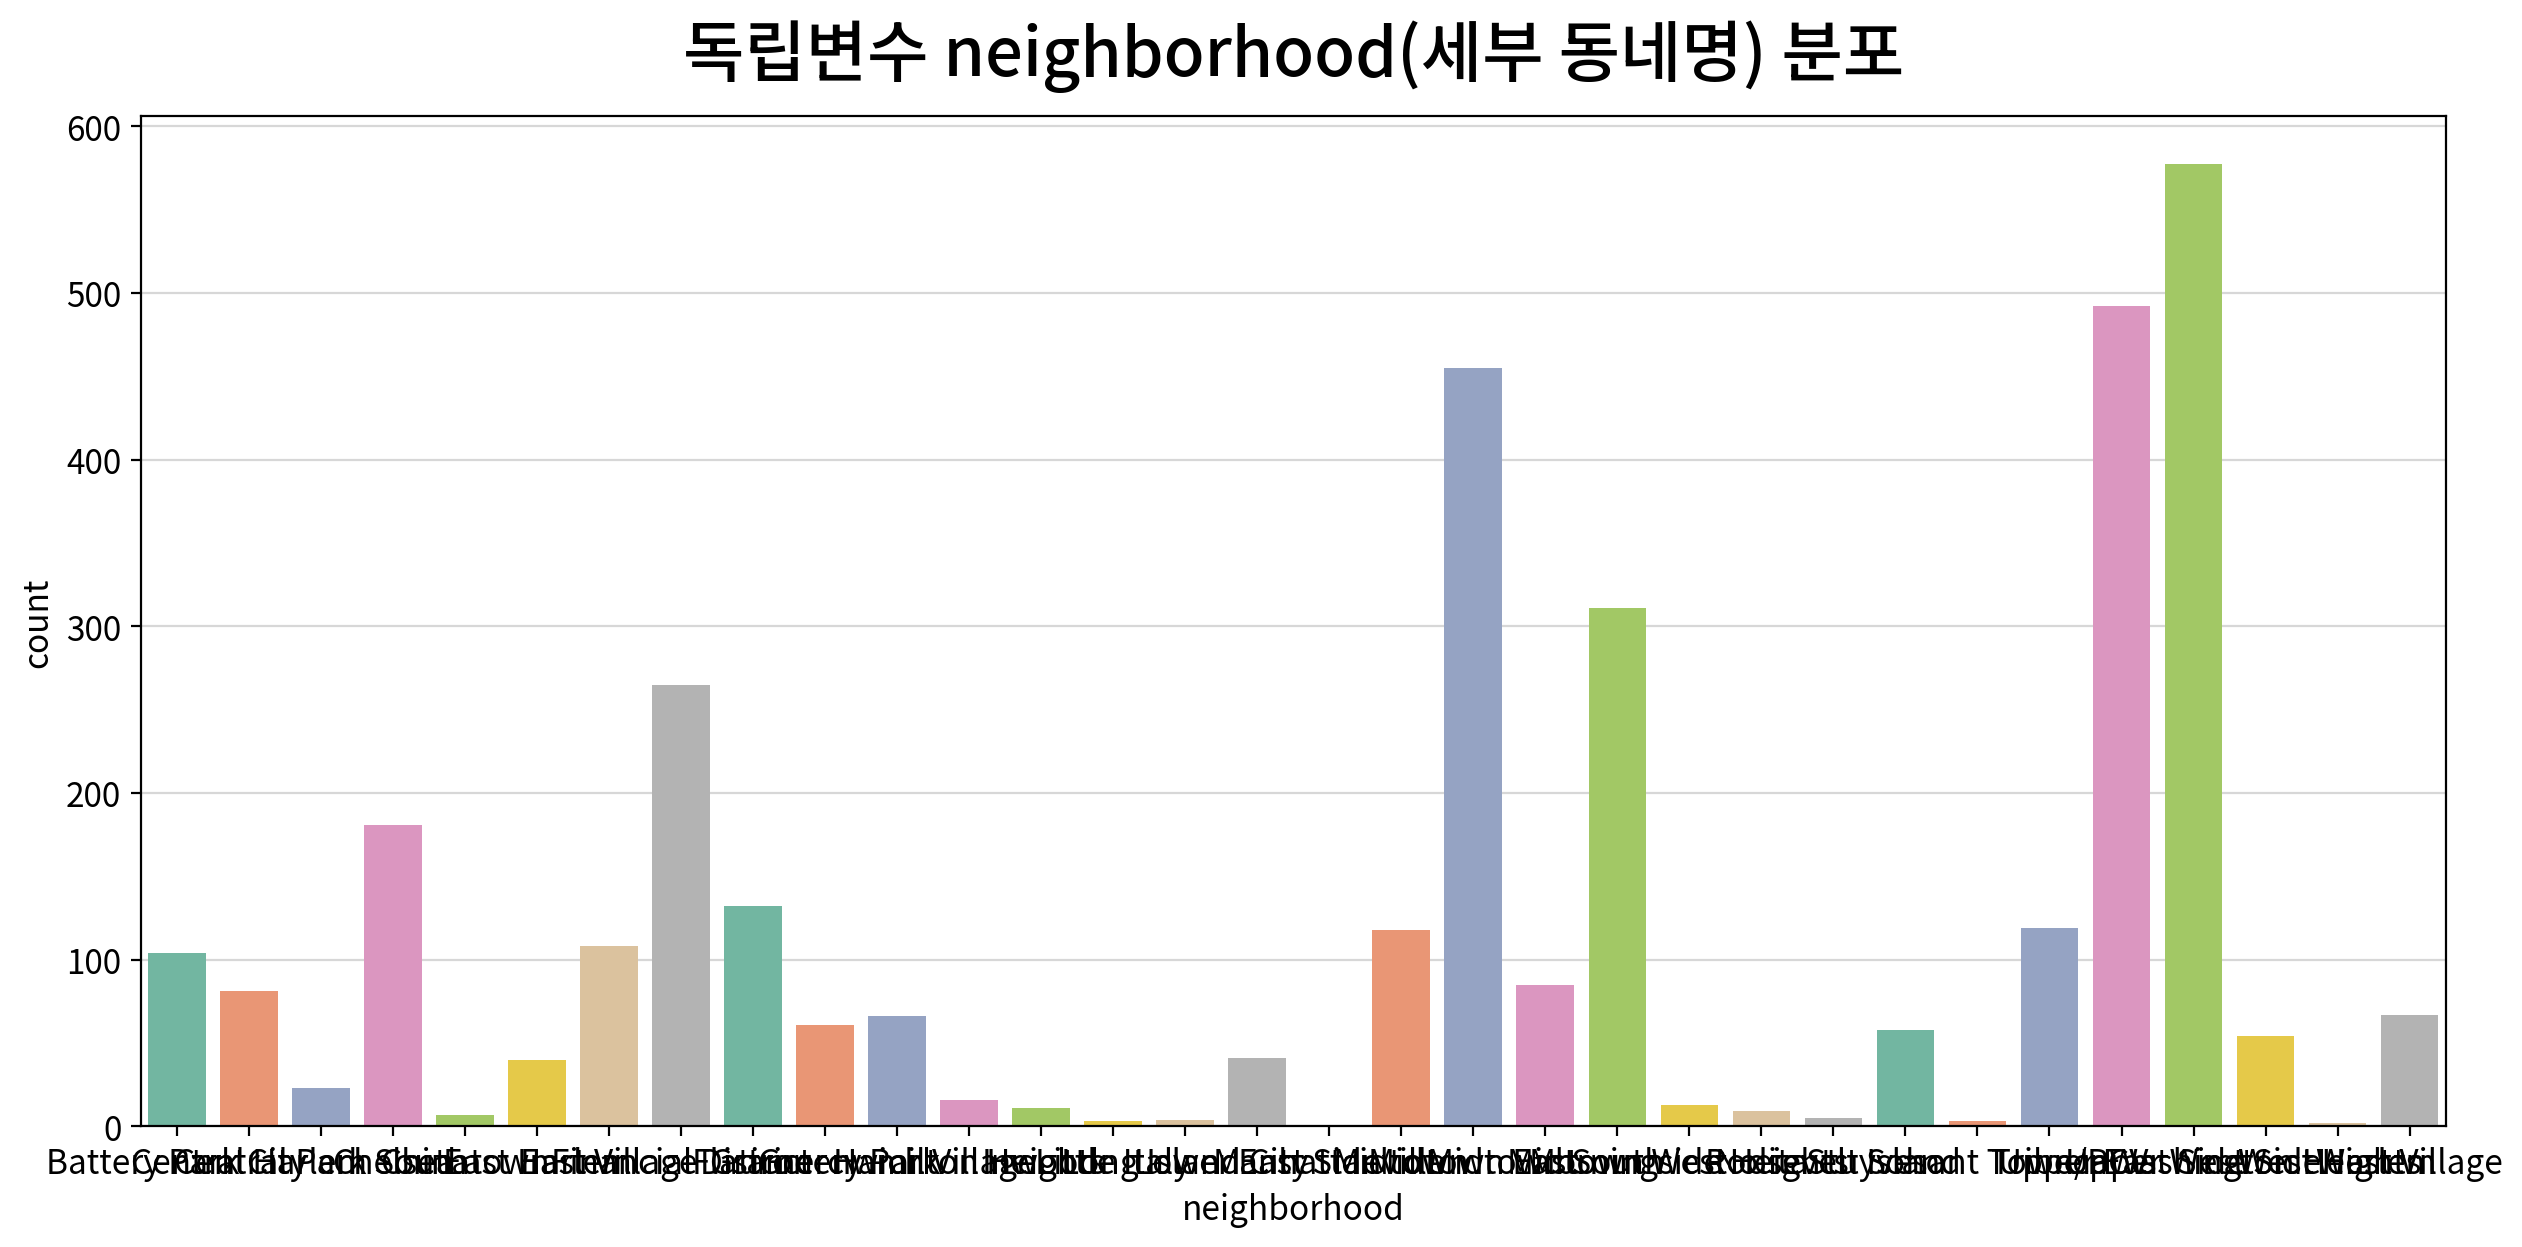

,count,unique,top,freq
neighborhood,3512,32,Upper West Side,577


,빈도,비율
neighborhood,,
Upper West Side,577,0.164
Upper East Side,492,0.140
Midtown East,455,0.130
Midtown West,311,0.089
Financial District,265,0.075
Chelsea,181,0.052
Flatiron,132,0.038
Tribeca,119,0.034
Midtown,118,0.034


In [20]:
# 3. 명목형 독립변수에 대한 단변량 분석

for n in nominal_cols:
    # 명목형 분포는 카운트플롯으로 처리한다.
    my_plot.countplot(data=df3, x=n, hue=n, palette="Set2", title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df3[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df3[n].value_counts(normalize=True)
    display(freq)

In [21]:
corr_list = []

for f in continuous_cols:
    corr_list.append(my_stats.correlation(df3, x=f, y=target, plot=False))

# 11개 결과를 한 표로 합쳐 상관계수 내림차순 정렬
corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
size_sqft,rent,Spearman,0.838,0.000,Strong,True,False,False,False,False,True
bathrooms,rent,Spearman,0.722,0.000,Strong,True,False,False,False,False,True
bedrooms,rent,Spearman,0.678,0.000,Moderate,True,False,False,False,False,True
floor,rent,Spearman,0.300,0.000,Weak,True,False,False,True,False,True
min_to_subway,rent,Spearman,-0.083,0.000,Weak,True,False,False,False,True,True
building_age_yrs,rent,Spearman,-0.253,0.000,Weak,True,False,False,False,False,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak        3
Strong      2
Moderate    1
Name: count, dtype: int64


### 1. 연속형 독립변수 → 월세

| 설명변수| 검정 방법|상관계수 | 부호| 계수의 크기 | 유의성|
| -------------------------- | -------- | -----: | ---- | ------ | ---------------- |
|`bedrooms`| Spearman |  0.678 | 양(+) | 중간 정도  | 유의함 (`p < .001`) |
|`bathrooms`| Spearman |  0.722 | 양(+) | 강함     | 유의함 (`p < .001`) |
`size_sqft`| Spearman |  0.838 | 양(+) | 매우 강함  | 유의함 (`p < .001`) |
|`min_to_subway`| Spearman | -0.083 | 음(-) | 매우 약함  | 유의함 (`p < .001`) |
|`floor`| Spearman |  0.300 | 양(+) | 약함     | 유의함 (`p < .001`) |
|`building_age_yrs`| Spearman | -0.253 | 음(-) | 약함     | 유의함 (`p < .001`) |

종속변수 `rent`가 정규성을 만족하지 못했기 때문에 모두 Spearman을 사용

#### 🧪 no_fee(중개 수수료 없음 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:5.947e-01 U_stat=1.501e+06


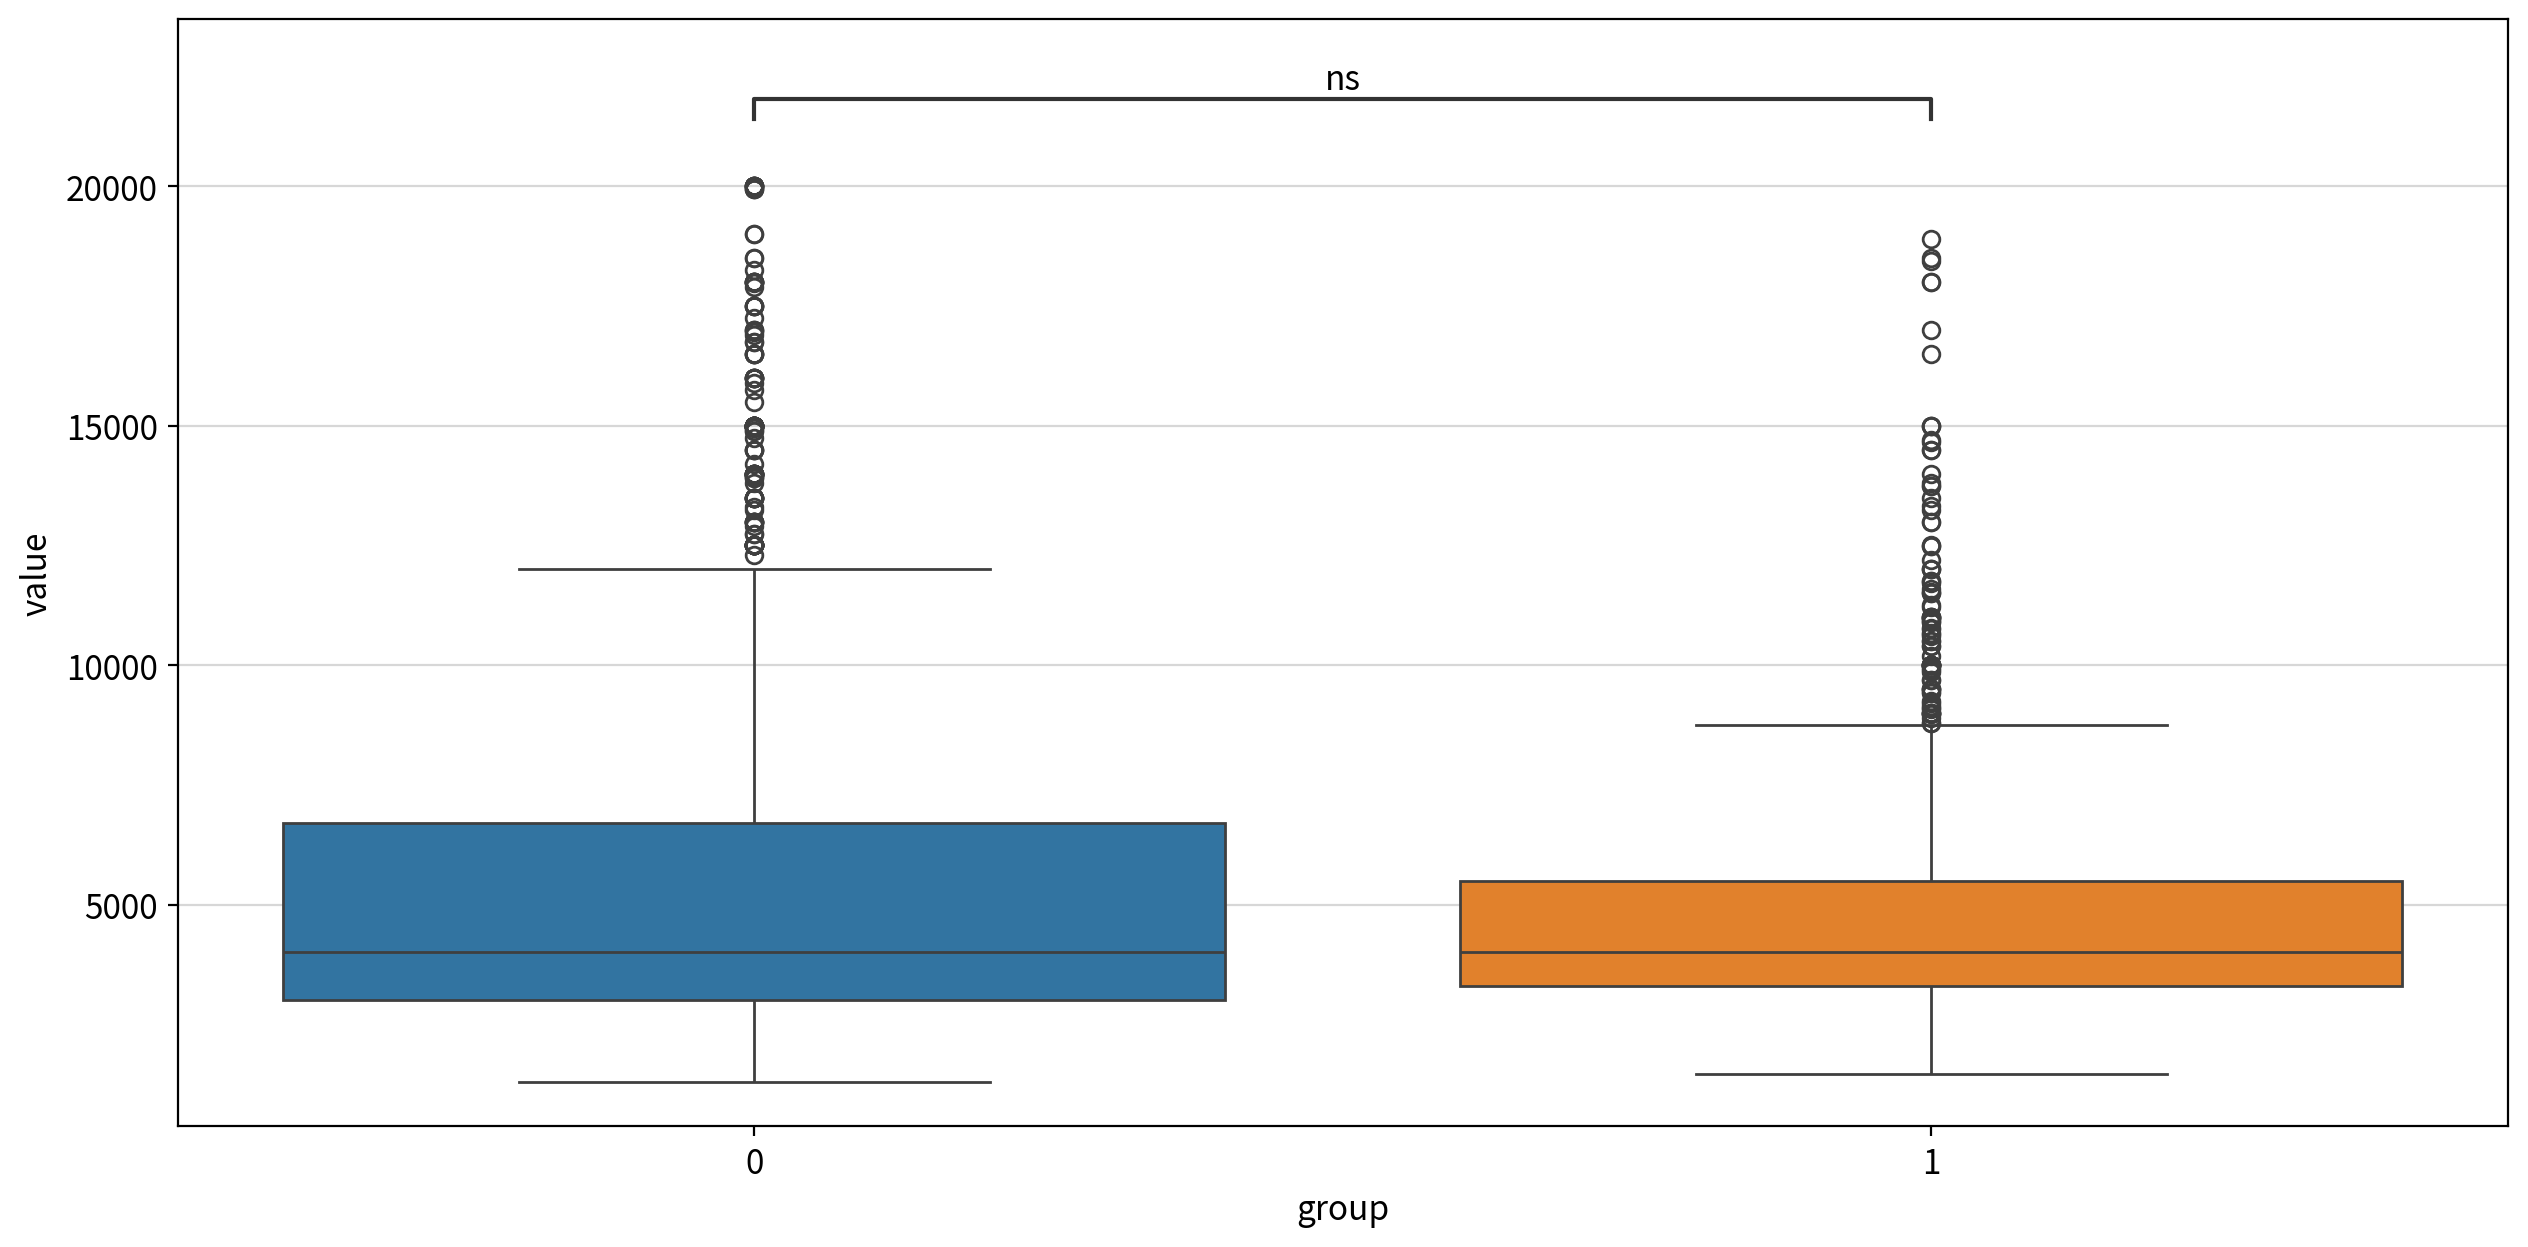

statistic  p-value  significant result
test                alternative                                         
Mann-Whitney U test two-sided   1501349.000    0.595        False  0 = 1
                    less        1501349.000    0.703        False  0 ≥ 1
                    greater     1501349.000    0.297        False  0 ≤ 1

#### 🧪 has_roofdeck(옥상 데크 보유 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:5.714e-02 U_stat=7.671e+05


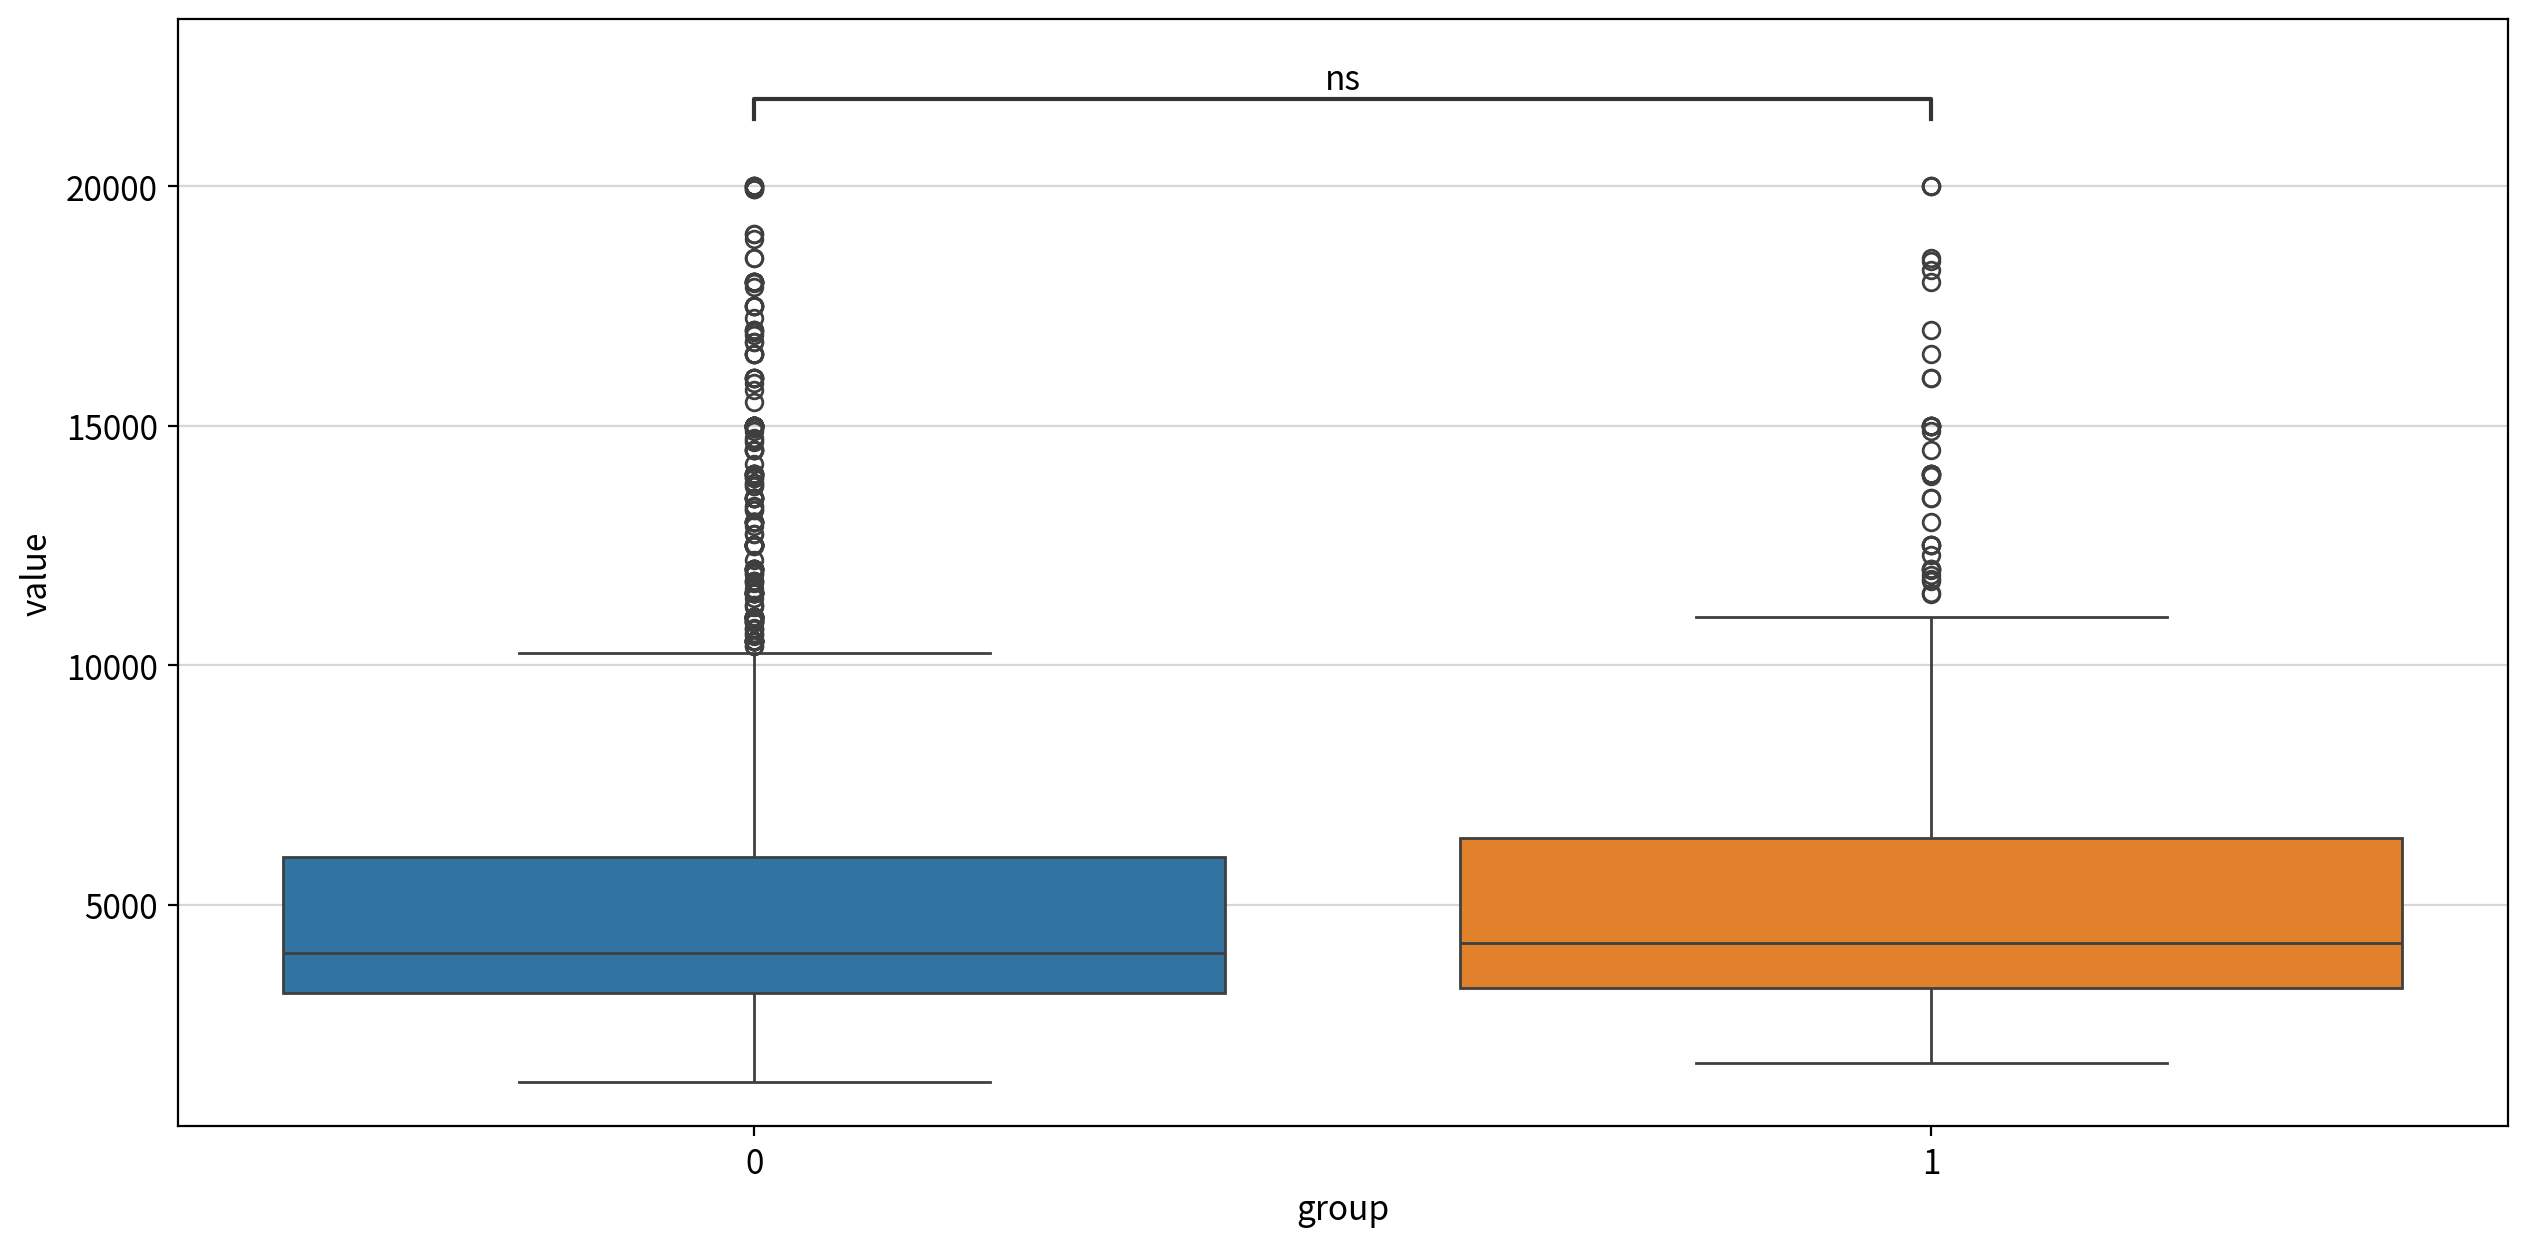

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   767120.500    0.057        False  0 = 1
                    less        767120.500    0.029         True  0 < 1
                    greater     767120.500    0.971        False  0 ≤ 1

#### 🧪 has_washer_dryer(세탁기·건조기 보유 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.526e-04 U_stat=7.489e+05


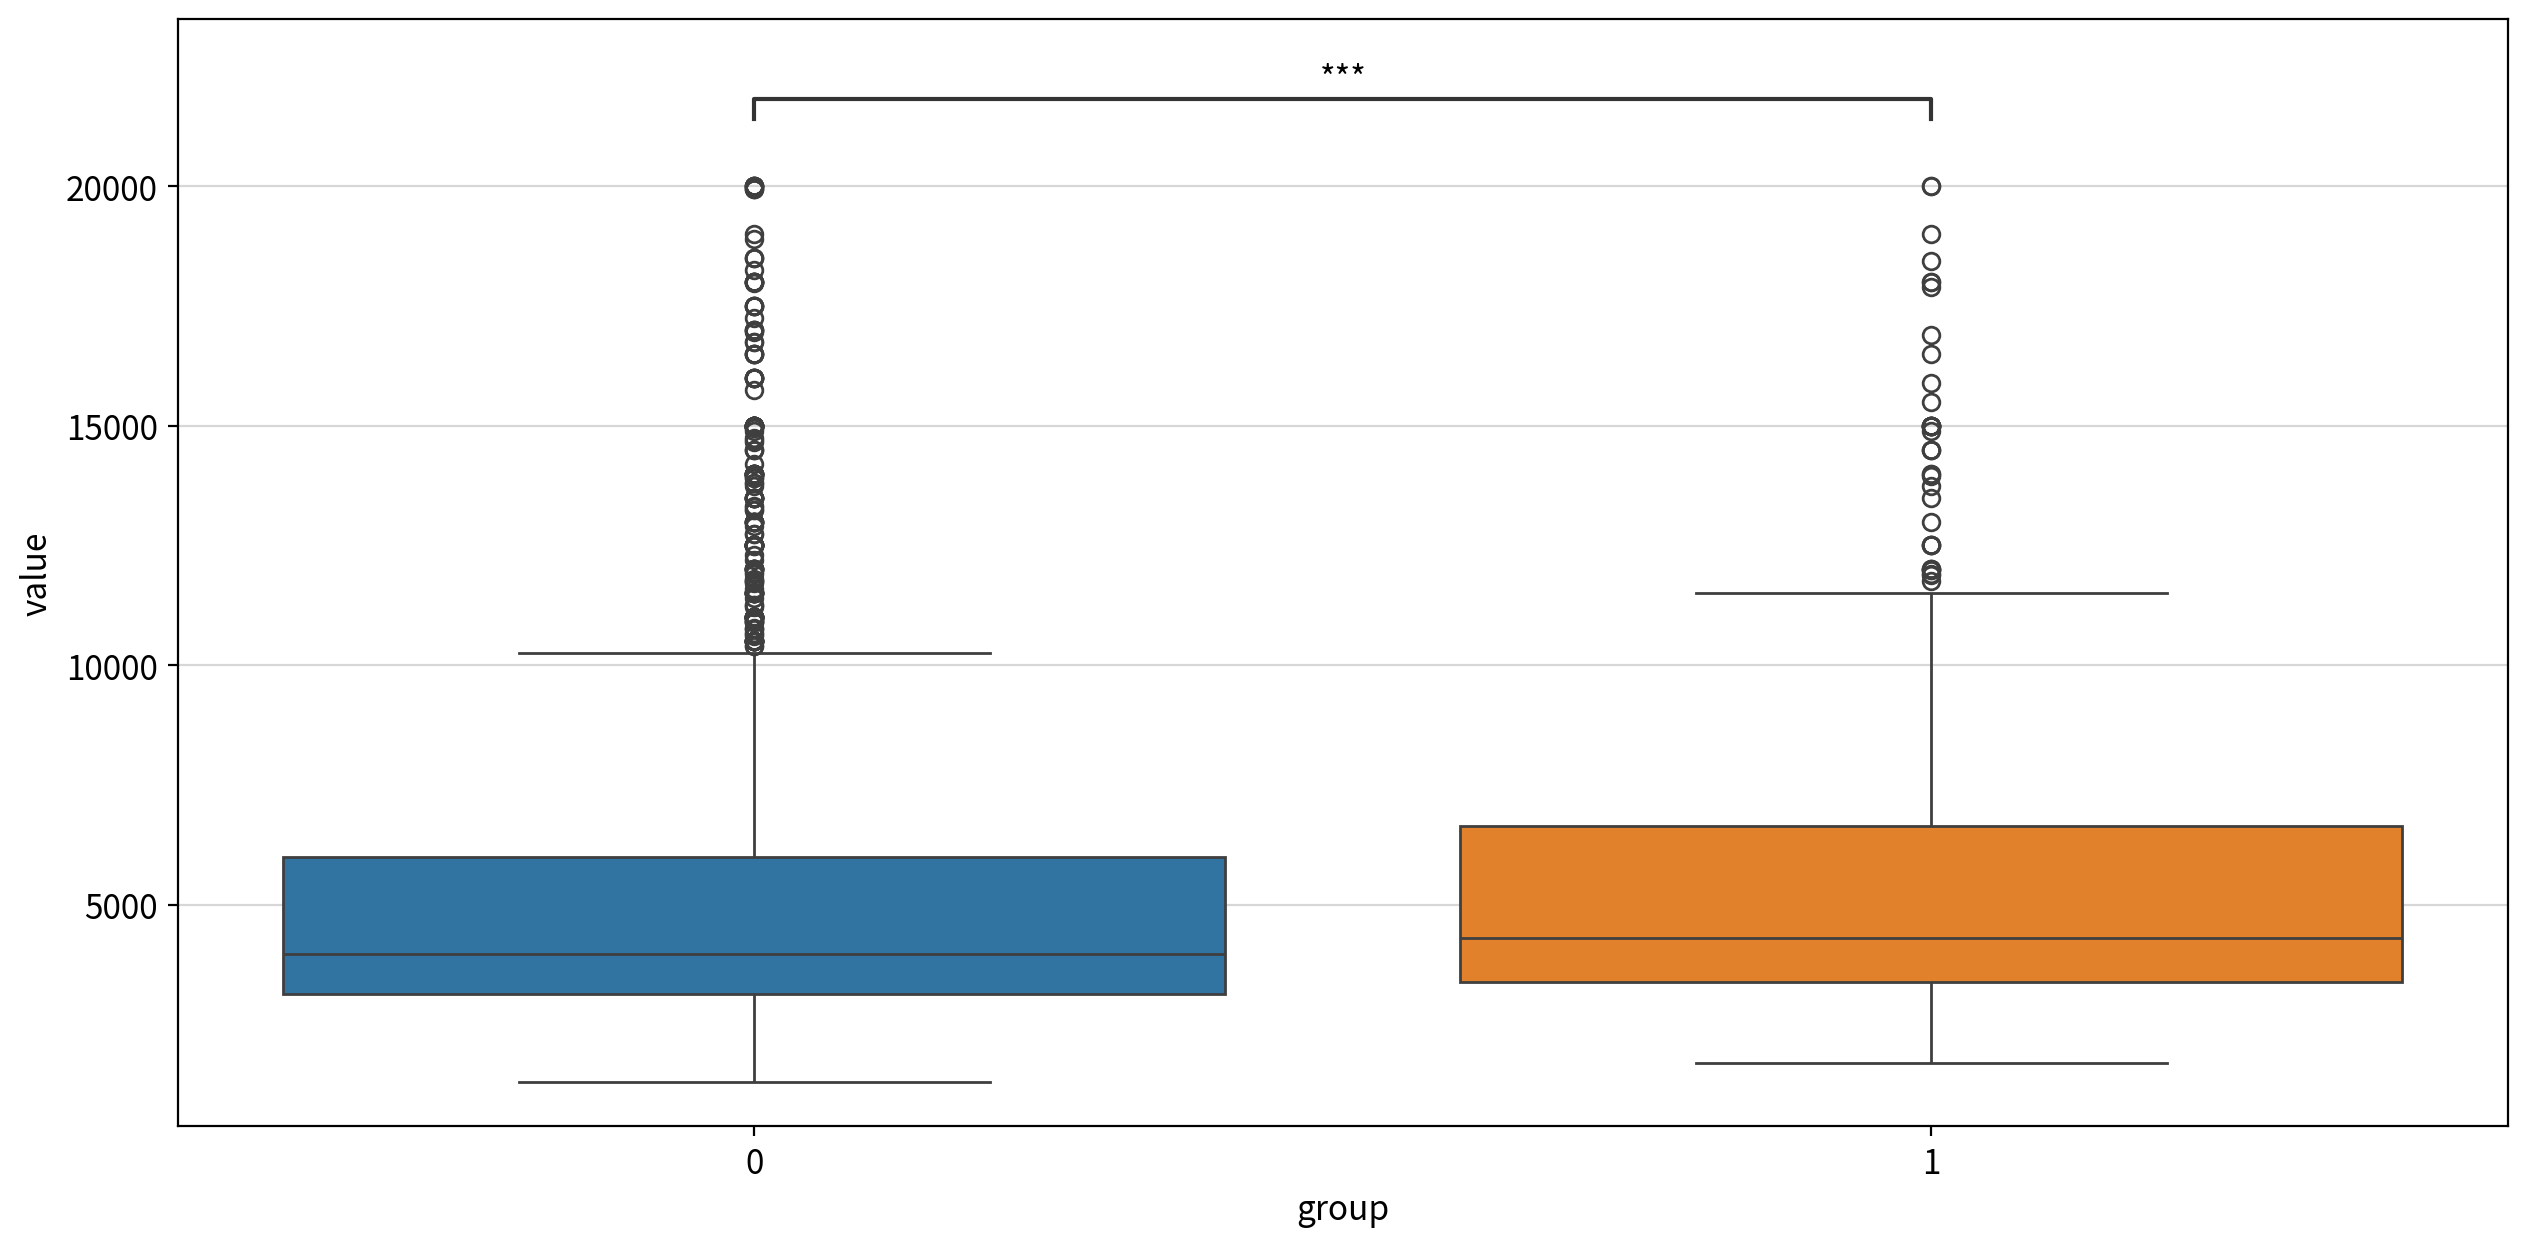

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   748924.500    0.000         True  0 ≠ 1
                    less        748924.500    0.000         True  0 < 1
                    greater     748924.500    1.000        False  0 ≤ 1

#### 🧪 has_doorman(도어맨 보유 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.051e-02 U_stat=1.174e+06


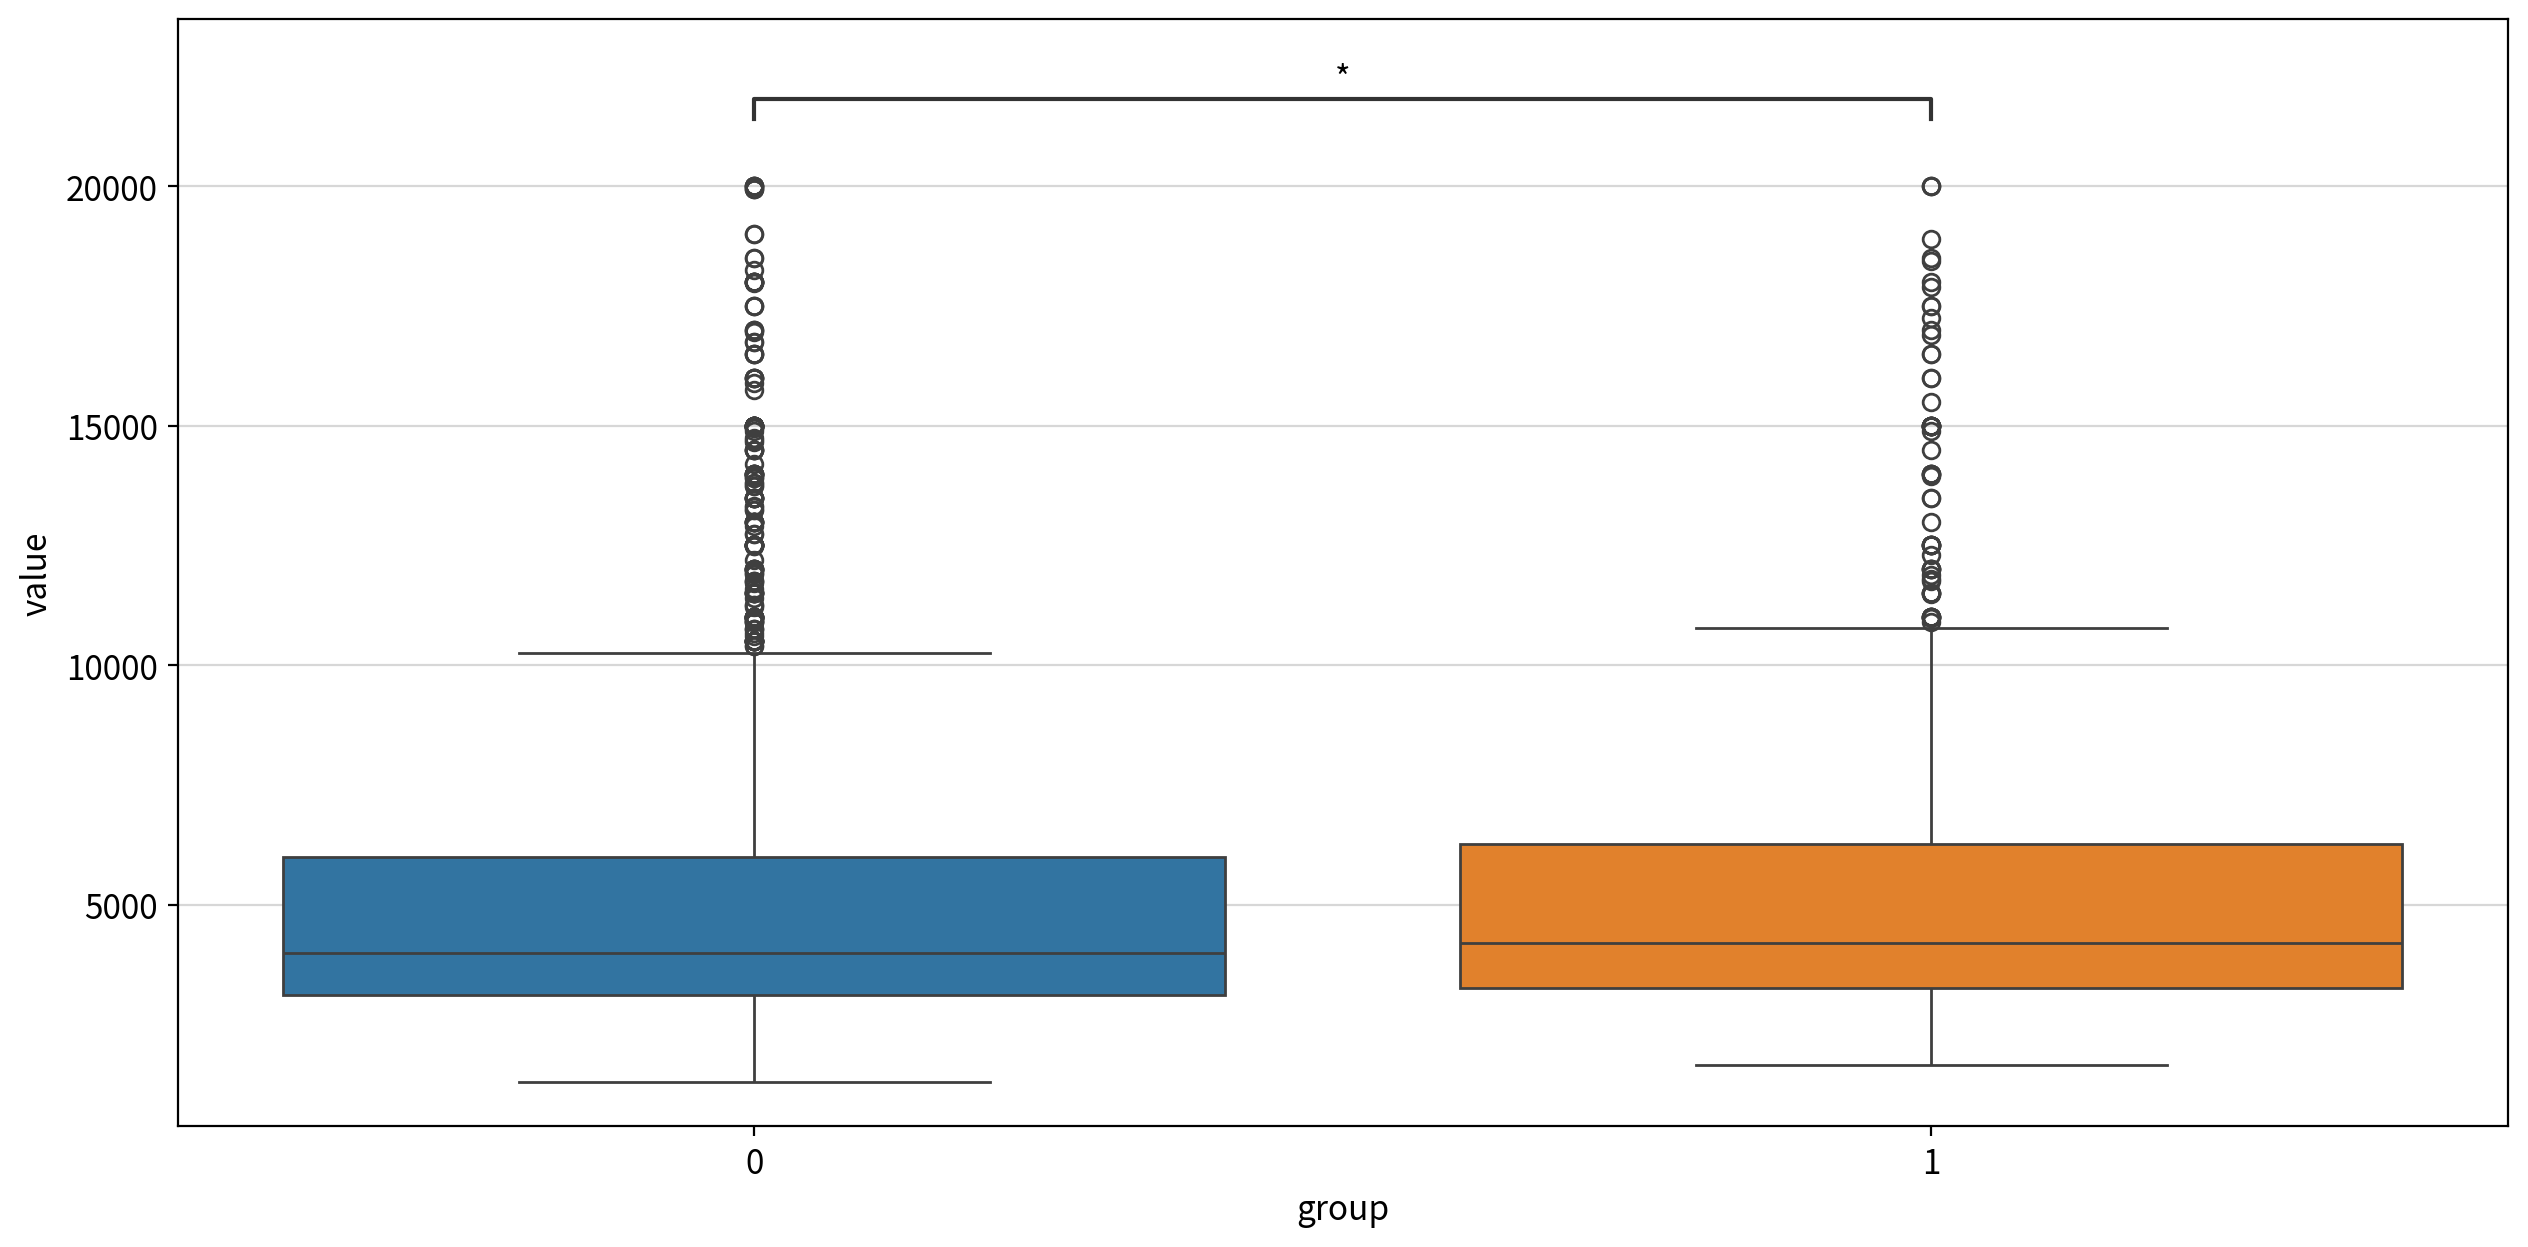

statistic  p-value  significant result
test                alternative                                         
Mann-Whitney U test two-sided   1173977.000    0.011         True  0 ≠ 1
                    less        1173977.000    0.005         True  0 < 1
                    greater     1173977.000    0.995        False  0 ≤ 1

#### 🧪 has_elevator(엘리베이터 보유 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:7.785e-04 U_stat=1.188e+06


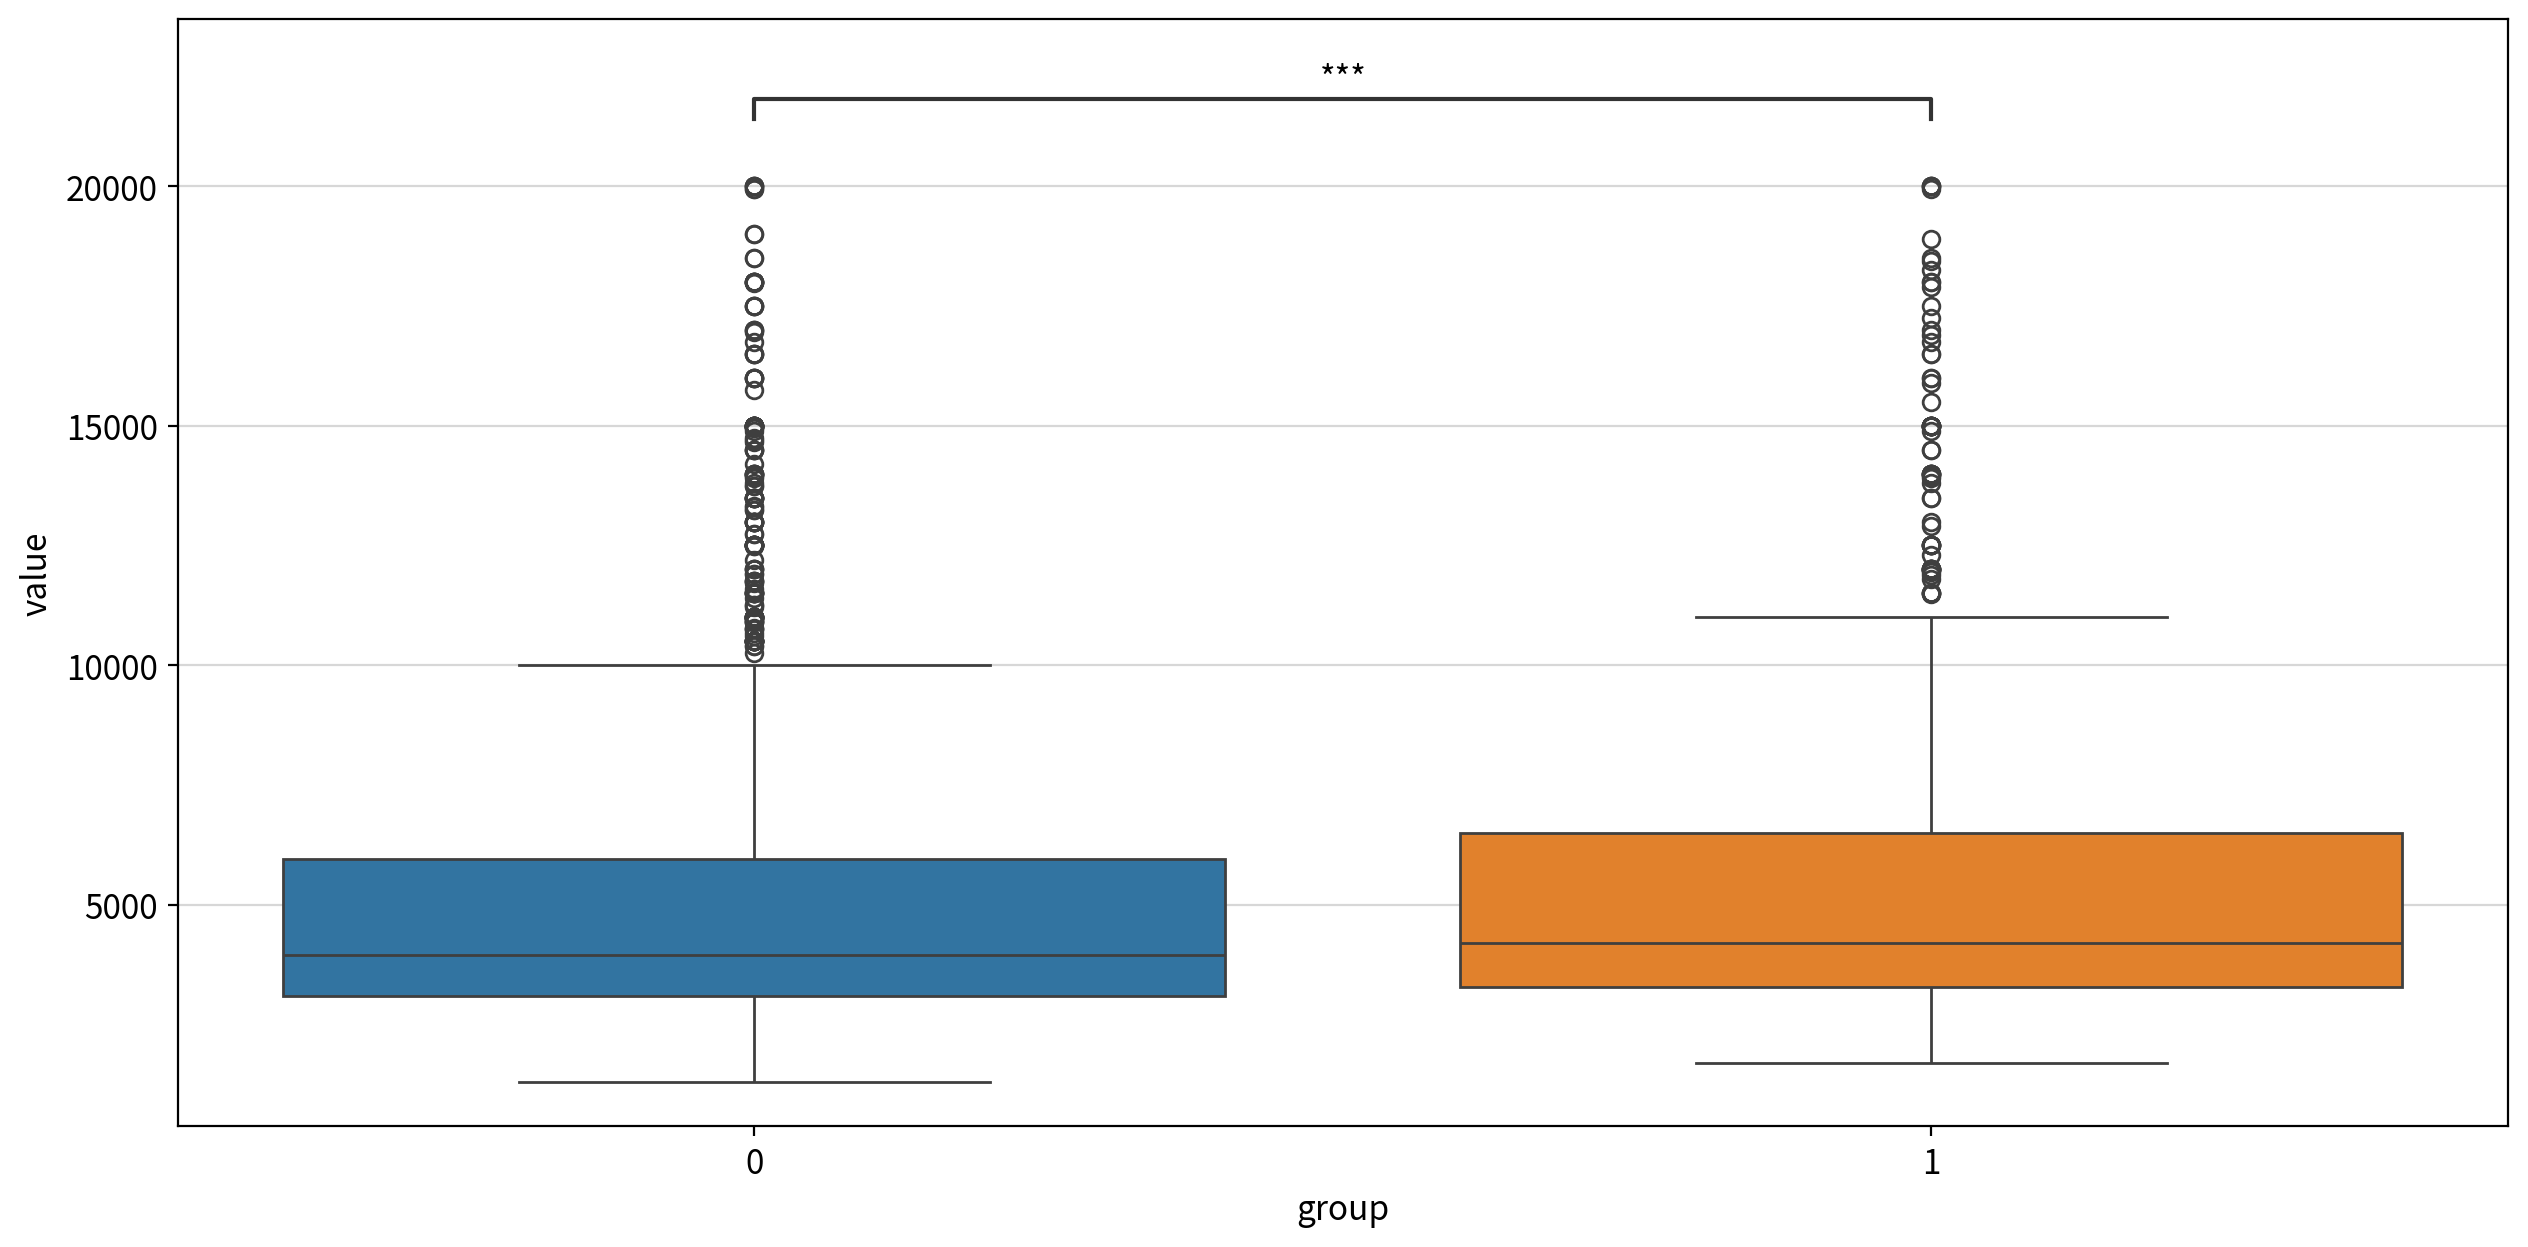

statistic  p-value  significant result
test                alternative                                         
Mann-Whitney U test two-sided   1188398.500    0.001         True  0 ≠ 1
                    less        1188398.500    0.000         True  0 < 1
                    greater     1188398.500    1.000        False  0 ≤ 1

#### 🧪 has_dishwasher(식기세척기 보유 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:2.400e-04 U_stat=8.466e+05


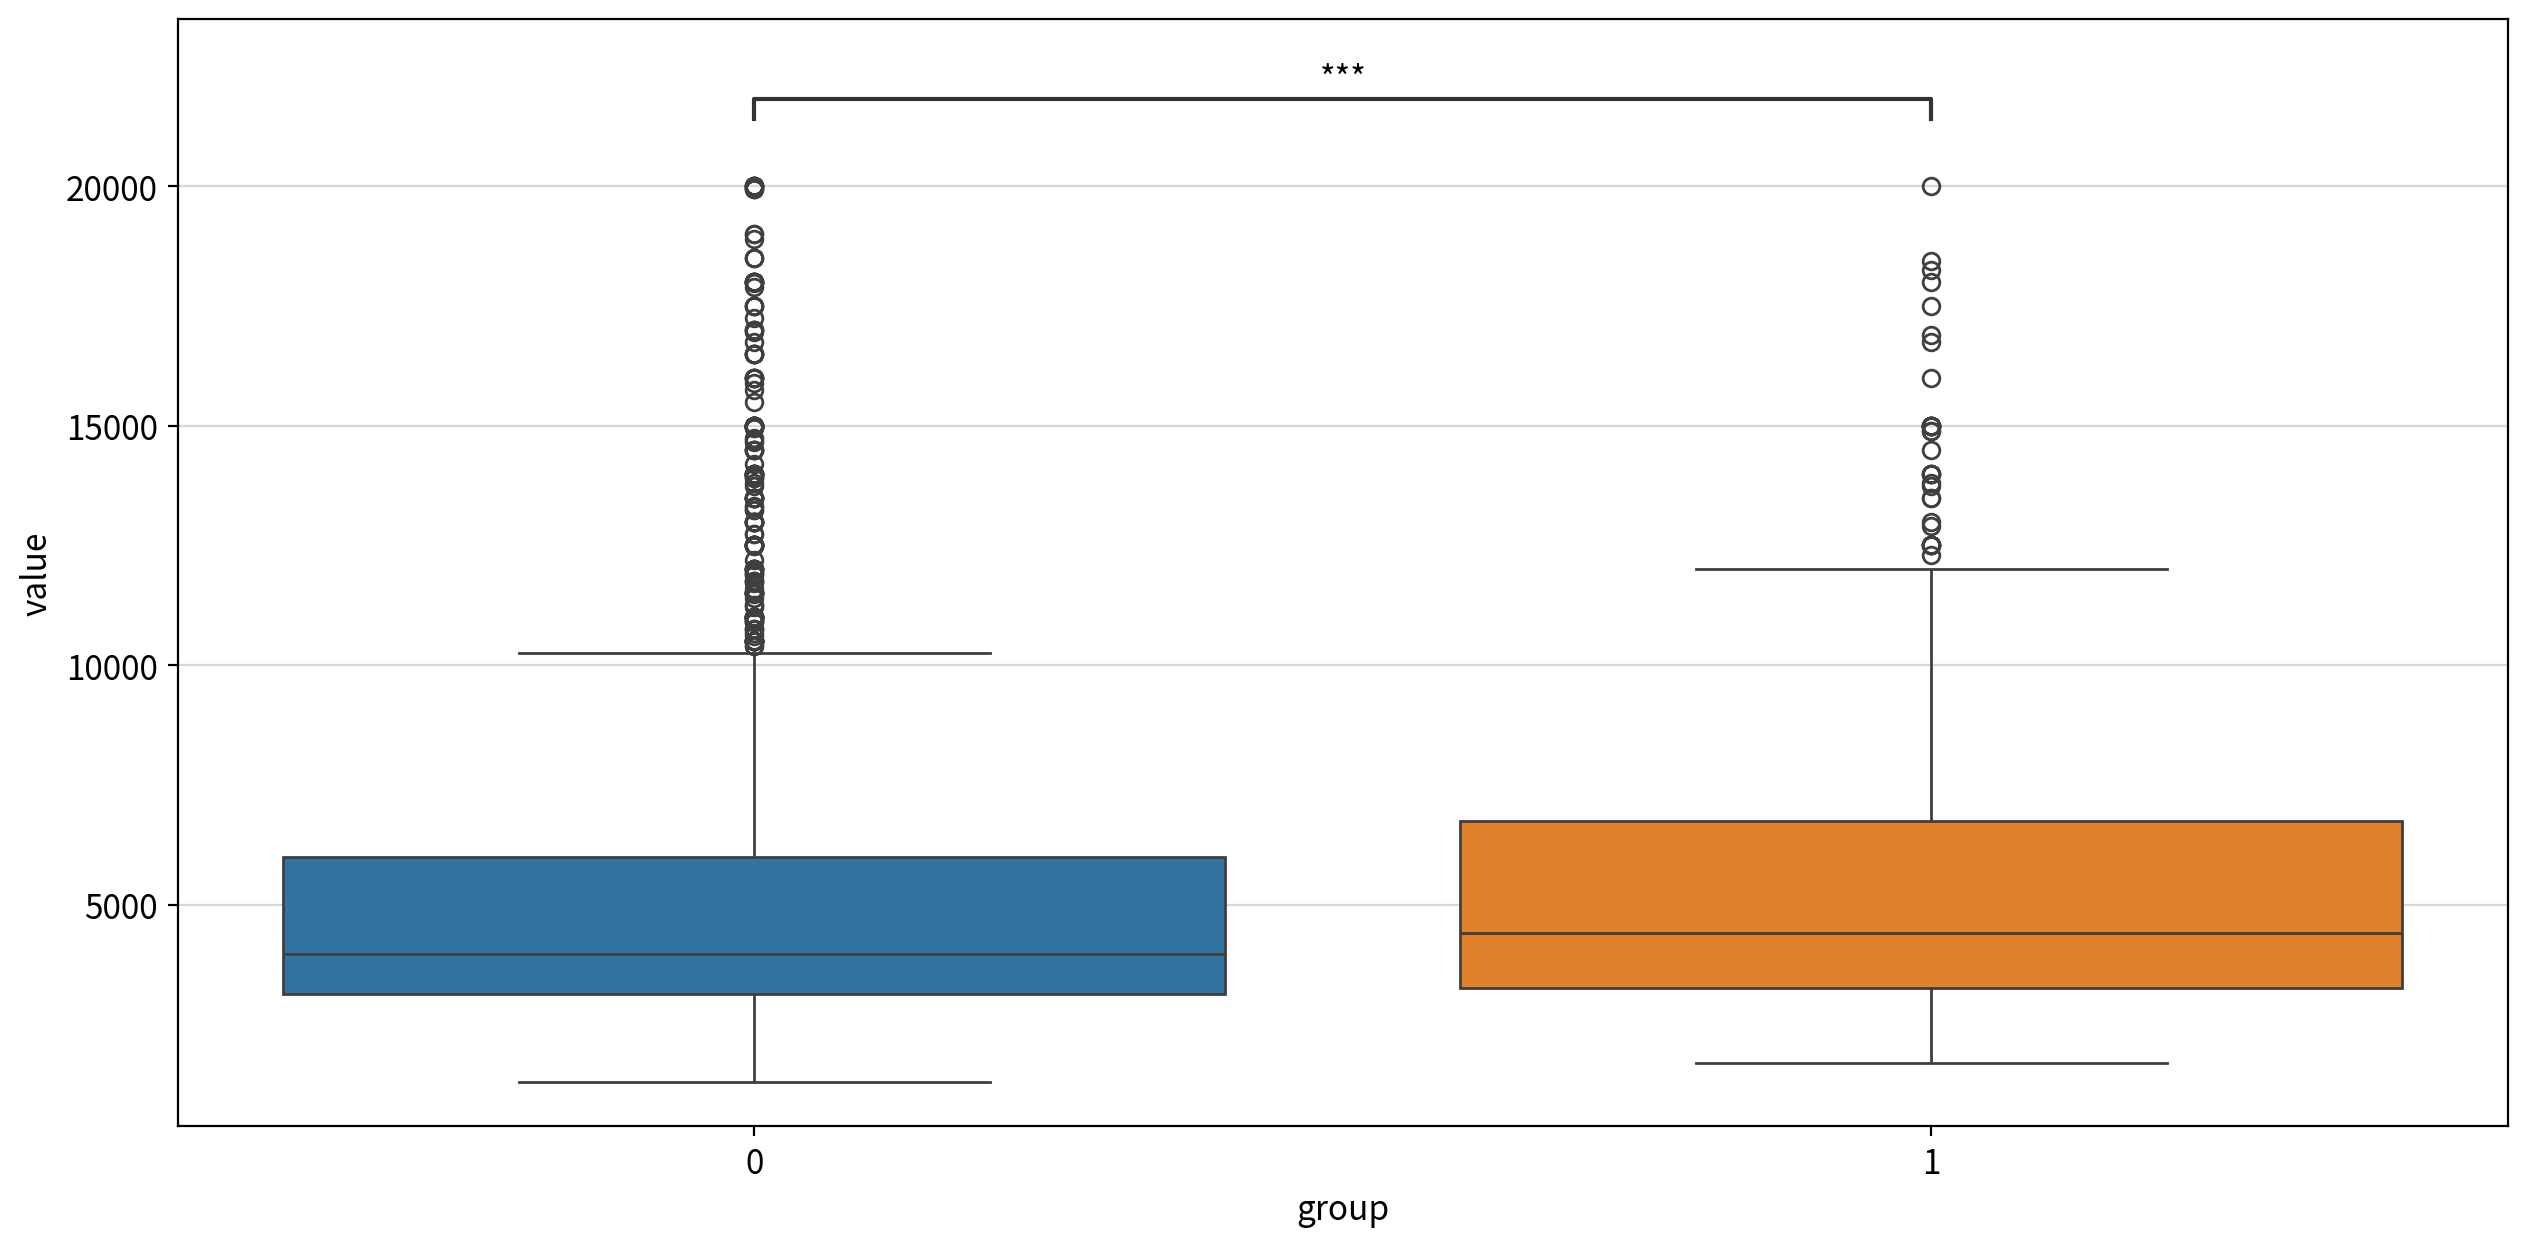

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   846552.000    0.000         True  0 ≠ 1
                    less        846552.000    0.000         True  0 < 1
                    greater     846552.000    1.000        False  0 ≤ 1

#### 🧪 has_patio(파티오 보유 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:5.701e-02 U_stat=2.972e+05


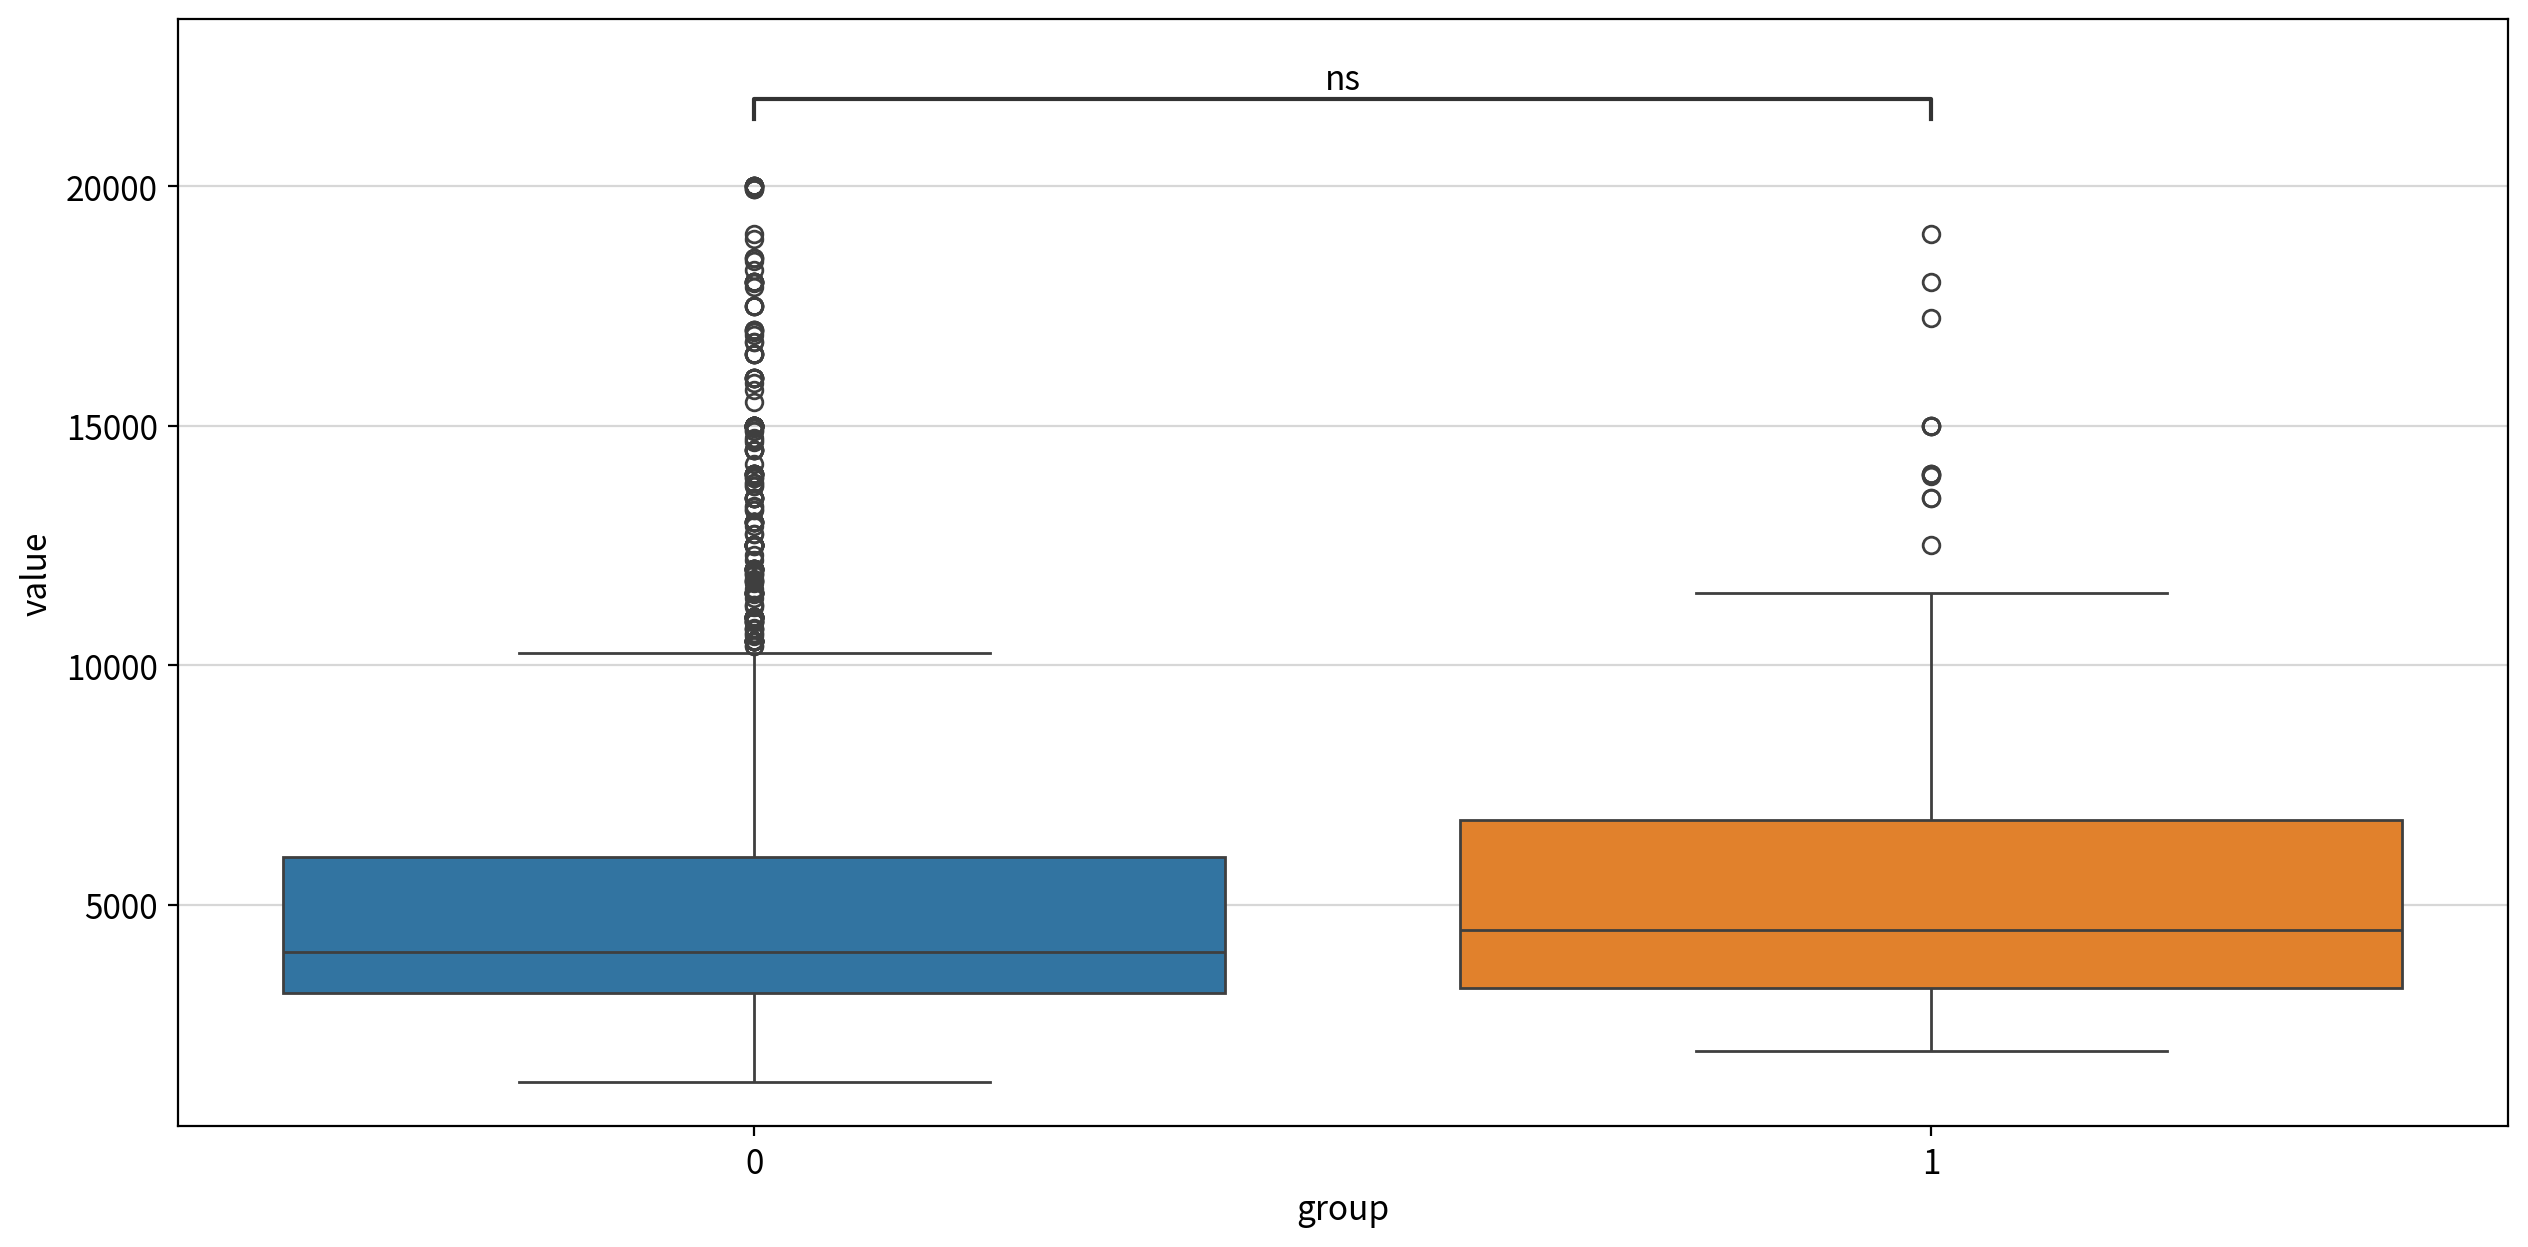

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   297217.500    0.057        False  0 = 1
                    less        297217.500    0.029         True  0 < 1
                    greater     297217.500    0.972        False  0 ≤ 1

#### 🧪 has_gym(피트니스센터 보유 여부) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:5.052e-02 U_stat=8.462e+05


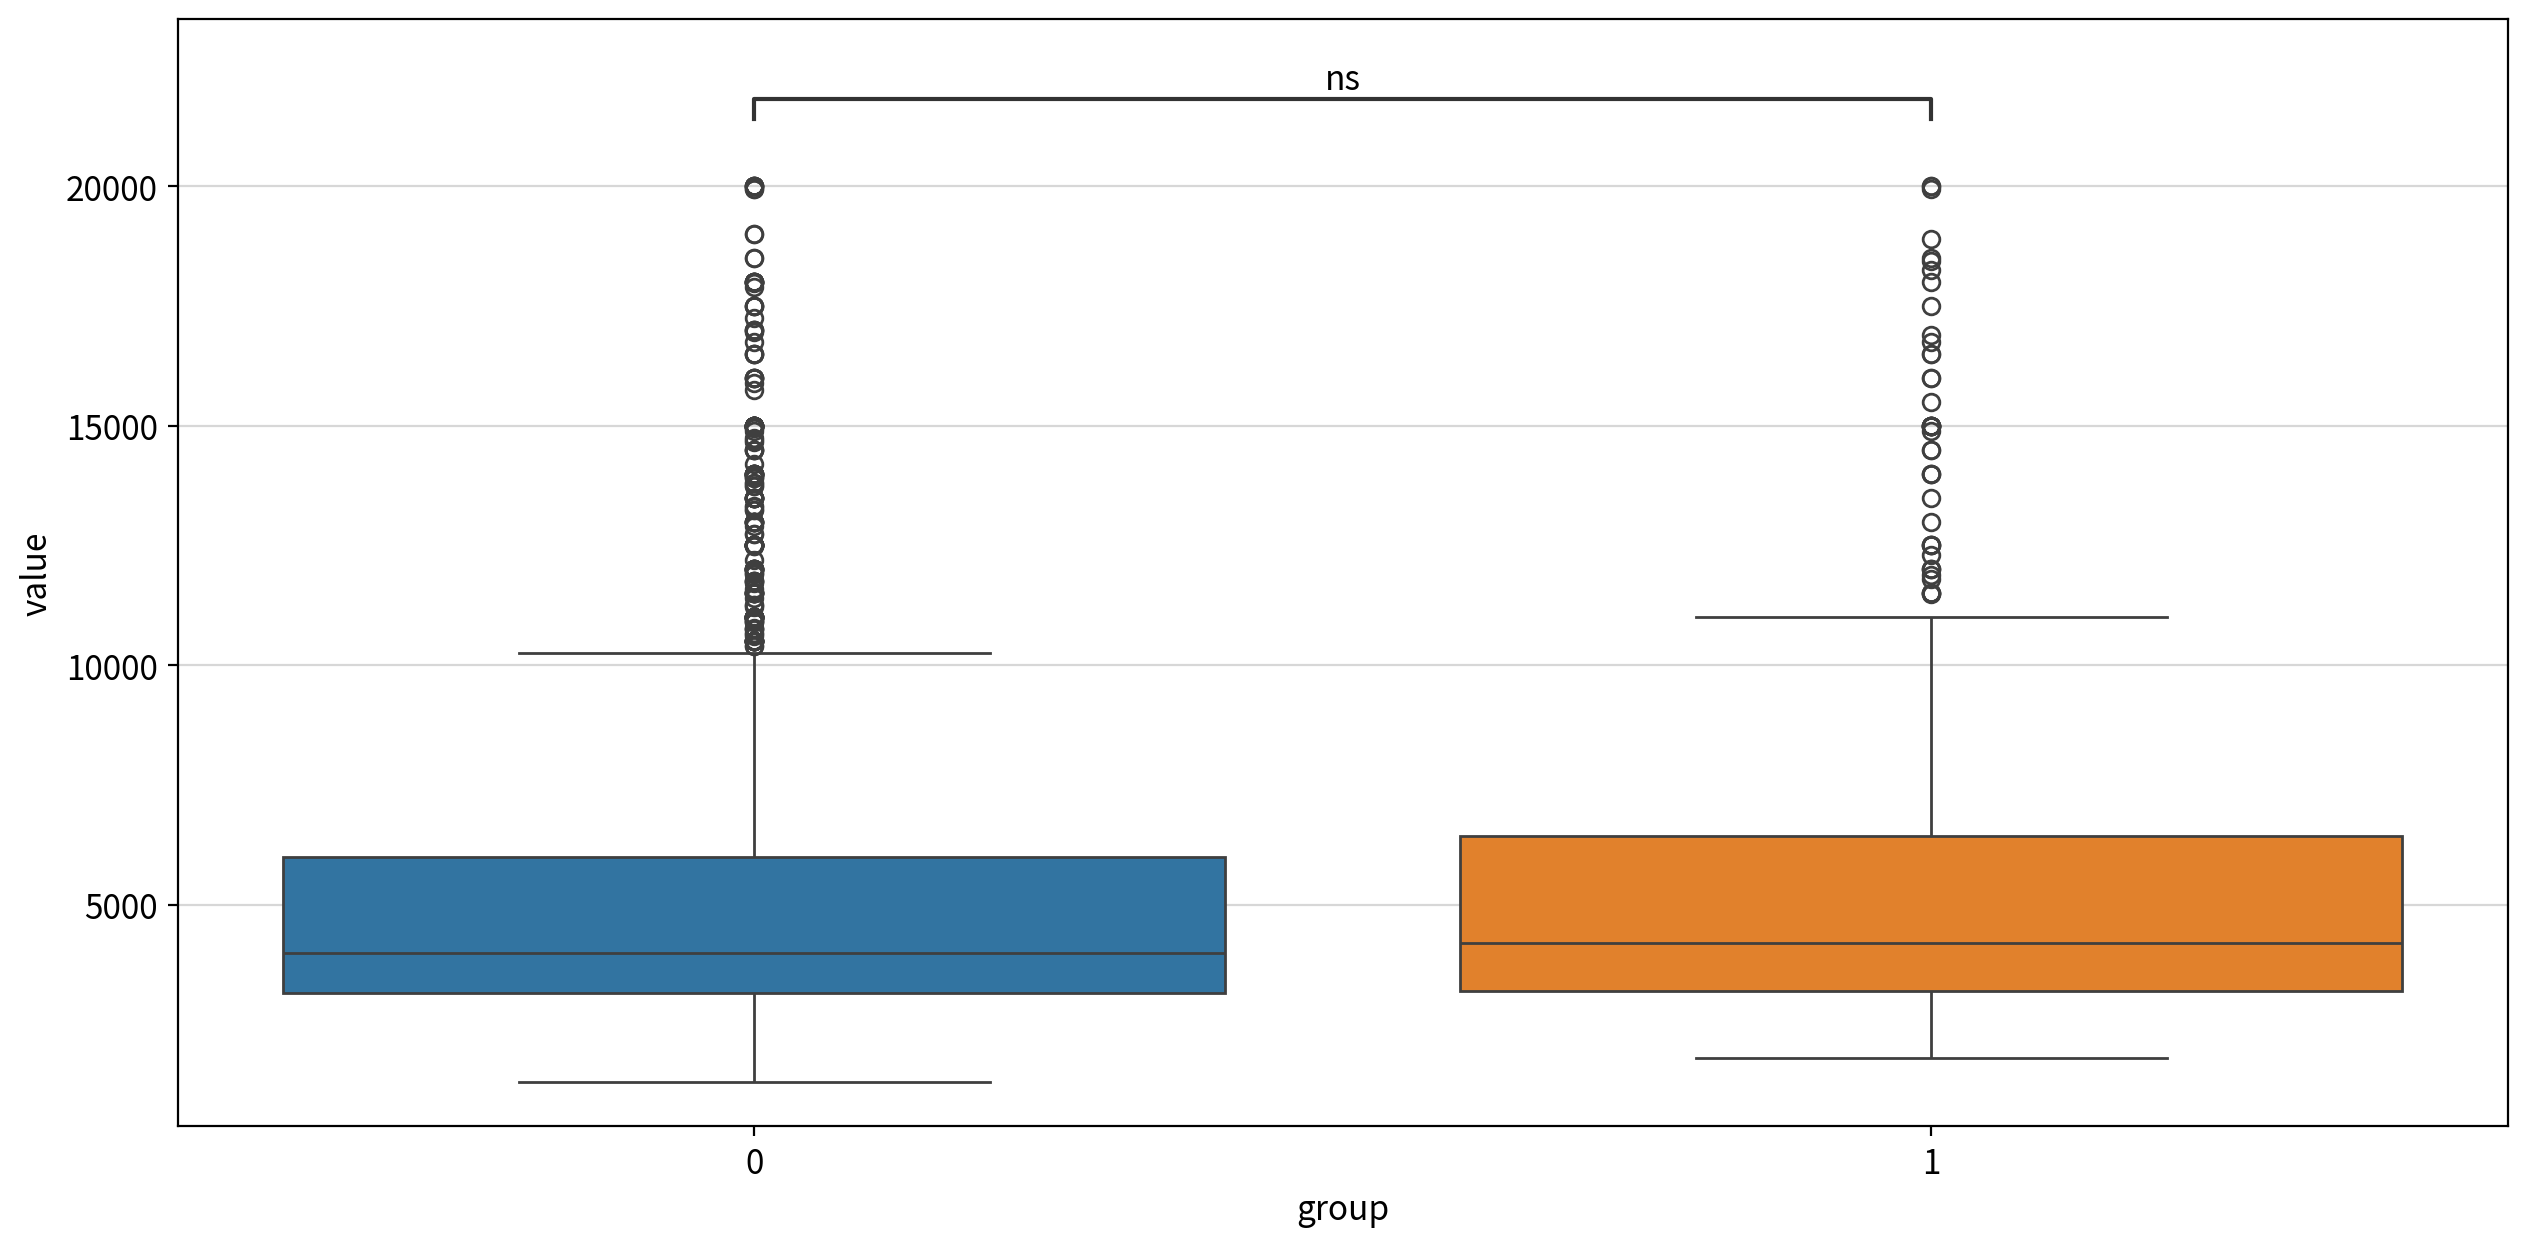

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided   846166.500    0.051        False  0 = 1
                    less        846166.500    0.025         True  0 < 1
                    greater     846166.500    0.975        False  0 ≤ 1

In [22]:
# 2. T-Test(x: 2집단 명목형 독립변수 -> y: 종속변수)
for n in nominal_cols:
    # 2개의 고유값을 가지는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df3, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                                          group1=wide_df.columns[0], group2=wide_df.columns[1]))

### 2. 2집단 명목형 독립변수 → 월세

|변수|사용된검정|유의확률|유의|
|---|---|---|---|
|`no_fee`|Mann-WhitneyU검정|p<0.595|비유의|
|`has_roofdeck`|Mann-WhitneyU검정|p<0.057|비유의|
|`has_washer_dryer`|Mann-WhitneyU검정|p<0.000|유의|
|`has_doorman`|Mann-WhitneyU검정|p<0.011|유의|
|`has_elevator`|Mann-WhitneyU검정|p<0.001|유의|
|`has_dishwasher`|Mann-WhitneyU검정|p<0.000|유의|
|`has_patio`|Mann-WhitneyU검정|p<0.057|비유의|
|`has_gym`|Mann-WhitneyU검정|p<0.051|비유의|

rent가 정규성에 위배되었기 때문에 모두 Mann-WhitneyU검정이 사용되었다<br>
모든 2집단 명목형 독립변수의 boxplot이 분포와 중앙값이 비슷하거나 한쪽에 포함되어있어 효과크기가 크지 않을것으로 예상된다.<br>
그러나 `no_fee`를 제외한 모든 변수들이 "유의하지 않음(p>0.05)"이지만 0.05에서 크게 벗어나지 않기 때문에 `no_fee`는 제외, 나머지는 보류한다.

In [23]:
# 3. ANOVA(x: 3집단 명목형 독립변수 -> y: 종속변수) 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) >= 3:
        print()  # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df3, y=target, between=n))
        display(my_stats.posthoc_oneway(df3, y=target, between=n, plot=False))

#### 🧪 neighborhood(세부 동네명) → rent

C:\Users/ITWILL/OneDrive/빅데이터 분석 수업자료\helpers\my_stats.py:89: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,neighborhood,31,105.321,37.699,0.000,0.128,Medium


C:\Users/ITWILL/OneDrive/빅데이터 분석 수업자료\helpers\my_stats.py:89: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s, p = normaltest(data[c].dropna())


비교한 조합 쌍: 496개
유의한 쌍: 220개
평균 차이가 가장 큰 쌍: (Manhattanville) vs (Soho) → 차이 7072.655, 효과크기 Negligible, p-value nan
평균 차이가 가장 작은 쌍: (Battery Park City) vs (West Village) → 차이 2.009, 효과크기 Negligible, p-value 1.000


c:\Users\ITWILL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pingouin\effsize.py:830: RuntimeWarning: Degrees of freedom <= 0 for slice
  poolsd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
c:\Users\ITWILL\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,Battery Park City,Central Harlem,5968.962,2980.765,2988.196,325.901,9.169,153.079,0.000,1.248,True,Large
1,Games-Howell,Battery Park City,Central Park South,5968.962,7506.957,-1537.995,802.293,-1.917,28.868,0.978,-0.499,False,Small
2,Games-Howell,Battery Park City,Chelsea,5968.962,6208.862,-239.900,366.309,-0.655,220.885,1.000,-0.080,False,Negligible
3,Games-Howell,Battery Park City,Chinatown,5968.962,2963.571,3005.390,458.369,6.557,16.015,0.001,1.041,True,Large
4,Games-Howell,Battery Park City,East Harlem,5968.962,2519.550,3449.412,303.589,11.362,122.895,0.000,1.360,True,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,Games-Howell,Upper West Side,West Harlem,5361.863,2406.000,2955.863,336.542,8.783,1.463,0.169,0.878,False,Large
492,Games-Howell,Upper West Side,West Village,5361.863,5970.970,-609.107,449.374,-1.355,80.866,1.000,-0.180,False,Negligible
493,Games-Howell,Washington Heights,West Harlem,2539.333,2406.000,133.333,325.615,0.409,1.282,1.000,0.162,False,Negligible
494,Games-Howell,Washington Heights,West Village,2539.333,5970.970,-3431.637,441.250,-7.777,74.844,0.000,-1.282,True,Large


### 3. 3집단 이상 명목형 독립변수 → 월세

neighborhood는 통계적으로 유의하며 효과크기는 중간이다.
그러나 가장 큰 평균 차이가 나는 쌍은 (Manhattanville) vs (Soho) → 차이 7072.655, 효과크기 Negligible, p-value nan으로 Manhattanville는 값이 1개, soho는 58개로 표본차이가 7072.655의 차이를 만들어 유의해졌을 가능성이 있기 때문에 해당 변수는 이대로 모델에 투입하기 부적절하다고 판단함.

## 미션4. "겹치는 축은 무엇인가?"

In [24]:
corr = my_stats.multi_correlation(df3, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs
bedrooms,1.000,0.722,0.828,0.042,0.046,0.007
bathrooms,0.722,1.000,0.763,0.008,0.138,-0.115
size_sqft,0.828,0.763,1.000,-0.009,0.134,-0.064
min_to_subway,0.042,0.008,-0.009,1.000,0.020,-0.160
floor,0.046,0.138,0.134,0.020,1.000,-0.408
building_age_yrs,0.007,-0.115,-0.064,-0.160,-0.408,1.000


,max-y,max-coef,count,columns
x,,,,
bedrooms,size_sqft,0.828,2,"size_sqft, bathrooms"
size_sqft,bedrooms,0.828,2,"bedrooms, bathrooms"
bathrooms,size_sqft,0.763,2,"size_sqft, bedrooms"
building_age_yrs,floor,-0.408,0,-
floor,building_age_yrs,-0.408,0,-
min_to_subway,building_age_yrs,-0.160,0,-


bedrooms, bathrooms, size_sqft는 서로 높은 상관계수로 묶여있다.<br>
셋 중 하나의 변수를 사용한다면 가장 효과크기가 컸던 size_sqft를 사용해야 한다고 판단했다.<br>
다만 bedrooms와 bathrooms 또한 유의하며 효과크기가 moderate와 strong이었기 때문에 단순히 버리지 말고 파생변수로써 활용한다.<br>
bedrooms와 bathrooms 모두 기술통계량에서 25%와 50%의 값이 동일하게 1이고 1이 아닌데이터에 대해서 원룸, 침실분리형 원룸/ 독립욕실없음(공용욕실)로 1이나 아니냐로 거주공간의 특성이 바뀌기 때문에 1이상인지 미만인지로 파생변수를 만든다면 거주공간의 특성에 따른 명목형 변수로써 활용할 수 있을것으로 판단된다.<br>
size_sqft는 1. 매우 유의하고 2. 효과크기가 가장 크며 3. 공간적 특성을 대표하는 변수로써 1순위 변수이다.

# 3부. 데이터를 다시 만드는 단계
## 미션 5. "없는 변수를 만든다"

|관점|아이디어|
|----|----|
|원룸·공용화장실|"bathroom = 0" or "bedroom = 0" (0,1)|
|편의시설을 몇 개나 갖췄나|has_* 일곱 개의 합(0~7)|
|동네에서 큰 집인가 작은 집인가|전용 면적 / 그 동네 평균 전용 면적|
|동네에서 높은 층인가|층 / 그 동네 평균 층|

#### 비율형 파생변수 생성

In [25]:
# 전용 면적 / 그 동네 평균 전용 면적 : 동네에서 큰 집인가 작은 집인가
df3["neighborhood_mean_size"] = (
    df3.groupby("neighborhood")["size_sqft"].transform("mean")
)

df3["relative_size"] = (
    df3["size_sqft"] / df3["neighborhood_mean_size"]
)

# 층 / 그 동네 평균 층
df3["neighborhood_mean_floor"] = (
    df3.groupby("neighborhood")["floor"].transform("mean")
)

df3["relative_floor"] = (
    df3["floor"] / df3["neighborhood_mean_floor"]
)

# 컬럼 의미 갱신
column_means.update({
    "relative_size":    "동네 대비 전용 면적",
    "relative_floor":        "동네 대비 층",
})

derived_continuous = ["relative_size", "relative_floor"]

df3[derived_continuous].head()

,relative_size,relative_floor
0,0.471,0.167
1,2.169,0.157
2,0.880,2.198
3,1.057,1.257
4,3.436,1.022


#### 생성한 파생변수 점검

In [26]:
# 분모로 사용한 변수의 최솟값 점검 (0이 있으면 inf 가 발생한다)
display(Markdown("### 분모로 사용한 변수의 최솟값"))
print(df3[["neighborhood_mean_size", "neighborhood_mean_floor"]].min())

check = df3[derived_continuous]

display(Markdown("### 파생 결과에 결측치가 생기지 않았는지 확인"))
print(check.isna().sum())

display(Markdown("### 파생 결과에 무한대가 생기지 않았는지 확인"))
inf_count = check.isin([np.inf, -np.inf]).sum()
print(inf_count)
print(f"\n무한대가 생긴 행: {int(inf_count.sum())}건")
print(f"동네 평균 면적: {(df3['neighborhood_mean_size'] == 0).sum()}건")
print(f"동네 평균 면적: {(df3['neighborhood_mean_floor'] == 0).sum()}건")

### 분모로 사용한 변수의 최솟값

neighborhood_mean_size    433.333
neighborhood_mean_floor     2.938
dtype: float64


### 파생 결과에 결측치가 생기지 않았는지 확인

relative_size     0
relative_floor    0
dtype: int64


### 파생 결과에 무한대가 생기지 않았는지 확인

relative_size     0
relative_floor    0
dtype: int64

무한대가 생긴 행: 0건
동네 평균 면적: 0건
동네 평균 면적: 0건


#### 범주형 파생변수 생성

In [27]:
# 침실, 욕실 제약여부 : 원룸이거나 독립욕실이 없는 주택
df3["bed_bath_constraint"] = ((df3["bathrooms"] == 0) | (df3["bedrooms"].isin([0, 0.5]))).astype("category")

# 편의시설 점수 : has_변수의 합(0~7)
has_cols = [
    "has_roofdeck",
    "has_washer_dryer",
    "has_doorman",
    "has_elevator",
    "has_dishwasher",
    "has_patio",
    "has_gym"
]

df3["amenity_count"] =df3[has_cols].astype(int).sum(axis=1)

column_means.update({
    "bed_bath_constraint":  "침실욕실 제약",
    "amenity_count":  "편의시설 개수"
})

for n in ["bed_bath_constraint", "amenity_count"]:
    freq = df3[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df3[n].value_counts(normalize=True)
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) 분포"))
    display(freq)

#### ▶︎ bed_bath_constraint(침실욕실 제약) 분포

,빈도,비율
bed_bath_constraint,,
False,2848,0.811
True,664,0.189


#### ▶︎ amenity_count(편의시설 개수) 분포

,빈도,비율
amenity_count,,
0,1995,0.568
1,366,0.104
2,291,0.083
4,281,0.080
3,261,0.074
5,187,0.053
6,119,0.034
7,12,0.003


#### 2차 파생변수

In [28]:
# 편의시설 개수 / 동네 편의시설 개수 평균 : 동네 대비 편의시설 개수
df3["neighborhood_amenity_mean"] = (
    df3.groupby("neighborhood")["amenity_count"]
       .transform("mean")
)

df3["relative_amenity_ratio"] = (
    df3["amenity_count"]
    / df3["neighborhood_amenity_mean"]
)

# 컬럼 의미 갱신
column_means.update({
    "relative_amenity_ratio":    "동네 대비 편의시설 비율"
})

derived_continuous = ["relative_size", "relative_floor", "relative_amenity_ratio"]

df3[derived_continuous].head()

,relative_size,relative_floor,relative_amenity_ratio
0,0.471,0.167,2.718
1,2.169,0.157,0.000
2,0.880,2.198,2.088
3,1.057,1.257,2.694
4,3.436,1.022,2.974


#### 2차 파생변수 점검

In [29]:
# 분모로 사용한 변수의 최솟값 점검 (0이 있으면 inf 가 발생한다)
display(Markdown("### 분모로 사용한 변수의 최솟값"))
print(df3[["neighborhood_amenity_mean"]].min())

check = df3[derived_continuous]

display(Markdown("### 파생 결과에 결측치가 생기지 않았는지 확인"))
print(check.isna().sum())

display(Markdown("### 파생 결과에 무한대가 생기지 않았는지 확인"))
inf_count = check.isin([np.inf, -np.inf]).sum()
print(inf_count)
print(f"\n무한대가 생긴 행: {int(inf_count.sum())}건")
print(f"동네 평균 면적: {(df3['neighborhood_amenity_mean'] == 0).sum()}건")

### 분모로 사용한 변수의 최솟값

neighborhood_amenity_mean   0.000
dtype: float64


### 파생 결과에 결측치가 생기지 않았는지 확인

relative_size             0
relative_floor            0
relative_amenity_ratio    3
dtype: int64


### 파생 결과에 무한대가 생기지 않았는지 확인

relative_size             0
relative_floor            0
relative_amenity_ratio    0
dtype: int64

무한대가 생긴 행: 0건
동네 평균 면적: 3건


In [30]:
# relative_amenity_ratio가 결측인 행
ratio_na = df3["relative_amenity_ratio"].isna()

# 그중 분자와 분모가 모두 0인 행
zero_both = (
    (df3["amenity_count"] == 0) &
    (df3["neighborhood_amenity_mean"] == 0)
)

print(f"편의시설 비율 결측치: {ratio_na.sum()}개")
print(f"분자와 분모가 모두 0인 행: {zero_both.sum()}개")
print(f"결측치이면서 분자·분모가 모두 0인 행: {(ratio_na & zero_both).sum()}개")

편의시설 비율 결측치: 3개
분자와 분모가 모두 0인 행: 3개
결측치이면서 분자·분모가 모두 0인 행: 3개


In [31]:
# 결측값의 원인은 분자와 분모가 모두 0
# "relative_amenity_ratio"는 동네 편의시설 대비 주택 편의시설 비율이기 때문에 분자와 분모 모두 0인 경우의 값을 1로 대체한다.
df3["relative_amenity_ratio"] = (
    df3["relative_amenity_ratio"].fillna(1)
)

In [32]:
# 분모로 사용한 변수의 최솟값 점검 (0이 있으면 inf 가 발생한다)
display(Markdown("### 분모로 사용한 변수의 최솟값"))
print(df3[["neighborhood_amenity_mean"]].min())

check = df3[derived_continuous]

display(Markdown("### 파생 결과에 결측치가 생기지 않았는지 확인"))
print(check.isna().sum())

display(Markdown("### 파생 결과에 무한대가 생기지 않았는지 확인"))
inf_count = check.isin([np.inf, -np.inf]).sum()
print(inf_count)
print(f"\n무한대가 생긴 행: {int(inf_count.sum())}건")

### 분모로 사용한 변수의 최솟값

neighborhood_amenity_mean   0.000
dtype: float64


### 파생 결과에 결측치가 생기지 않았는지 확인

relative_size             0
relative_floor            0
relative_amenity_ratio    0
dtype: int64


### 파생 결과에 무한대가 생기지 않았는지 확인

relative_size             0
relative_floor            0
relative_amenity_ratio    0
dtype: int64

무한대가 생긴 행: 0건


## 미션6. "동네 32개를 다시 그린다"


In [33]:
# 동네별 비율
neighborhood_ratio = df3["neighborhood"].value_counts(normalize=True)

# 전체의 1% 미만인 동네
rare_neighborhoods = neighborhood_ratio[
    neighborhood_ratio < 0.01
].index

# 문자열로 변환 → OTHER로 교체 → category로 변환
df3["neighborhood_grp"] = (
    df3["neighborhood"]
    .astype("string")
    .where(
        ~df3["neighborhood"].isin(rare_neighborhoods),
        "OTHER"
    )
    .astype("category")
)

In [34]:
df3["neighborhood_grp"].value_counts()

neighborhood_grp
Upper West Side       577
Upper East Side       492
Midtown East          455
Midtown West          311
Financial District    265
Chelsea               181
Flatiron              132
Tribeca               119
Midtown               118
East Village          108
Battery Park City     104
OTHER                  97
Midtown South          85
Central Harlem         81
West Village           67
Greenwich Village      66
Gramercy Park          61
Soho                   58
Washington Heights     54
Lower East Side        41
East Harlem            40
Name: count, dtype: int64

In [35]:
column_means

{'rent': '월 임대료(USD)',
 'bedrooms': '침실 수',
 'bathrooms': '욕실 수',
 'size_sqft': '전용면적(제곱피트)',
 'min_to_subway': '지하철역까지 소요시간(분)',
 'floor': '층수',
 'building_age_yrs': '건물 연식(년)',
 'no_fee': '중개 수수료 없음 여부',
 'has_roofdeck': '옥상 데크 보유 여부',
 'has_washer_dryer': '세탁기·건조기 보유 여부',
 'has_doorman': '도어맨 보유 여부',
 'has_elevator': '엘리베이터 보유 여부',
 'has_dishwasher': '식기세척기 보유 여부',
 'has_patio': '파티오 보유 여부',
 'has_gym': '피트니스센터 보유 여부',
 'neighborhood': '세부 동네명',
 'borough': '자치구',
 'relative_size': '동네 대비 전용 면적',
 'relative_floor': '동네 대비 층',
 'bed_bath_constraint': '침실욕실 제약',
 'amenity_count': '편의시설 개수',
 'relative_amenity_ratio': '동네 대비 편의시설 비율'}

In [36]:
neighborhood_profile = (
    df3
    .groupby("neighborhood", observed=True)
    .agg(
        listing_count=("neighborhood", "size"),
        mean_rent=("rent", "mean"),
        mean_size=("size_sqft", "mean"),
        mean_floor=("floor", "mean"),
        mean_building_age=("building_age_yrs", "mean"),
        mean_subway_time=("min_to_subway", "mean"),
        mean_amenity_count=("amenity_count", "mean")
    )
    .reset_index()
)

StandardScaler 적용 (5개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
mean_size       433.33 ~ 1396.84          -2.35 ~ 2.58
mean_floor          2.94 ~ 24.50          -1.14 ~ 2.53
mean_building_age       4.00 ~ 111.00          -2.23 ~ 1.89
mean_amenity_count         0.00 ~ 2.33          -2.01 ~ 2.21
mean_subway_time        1.50 ~ 14.20          -1.06 ~ 3.42


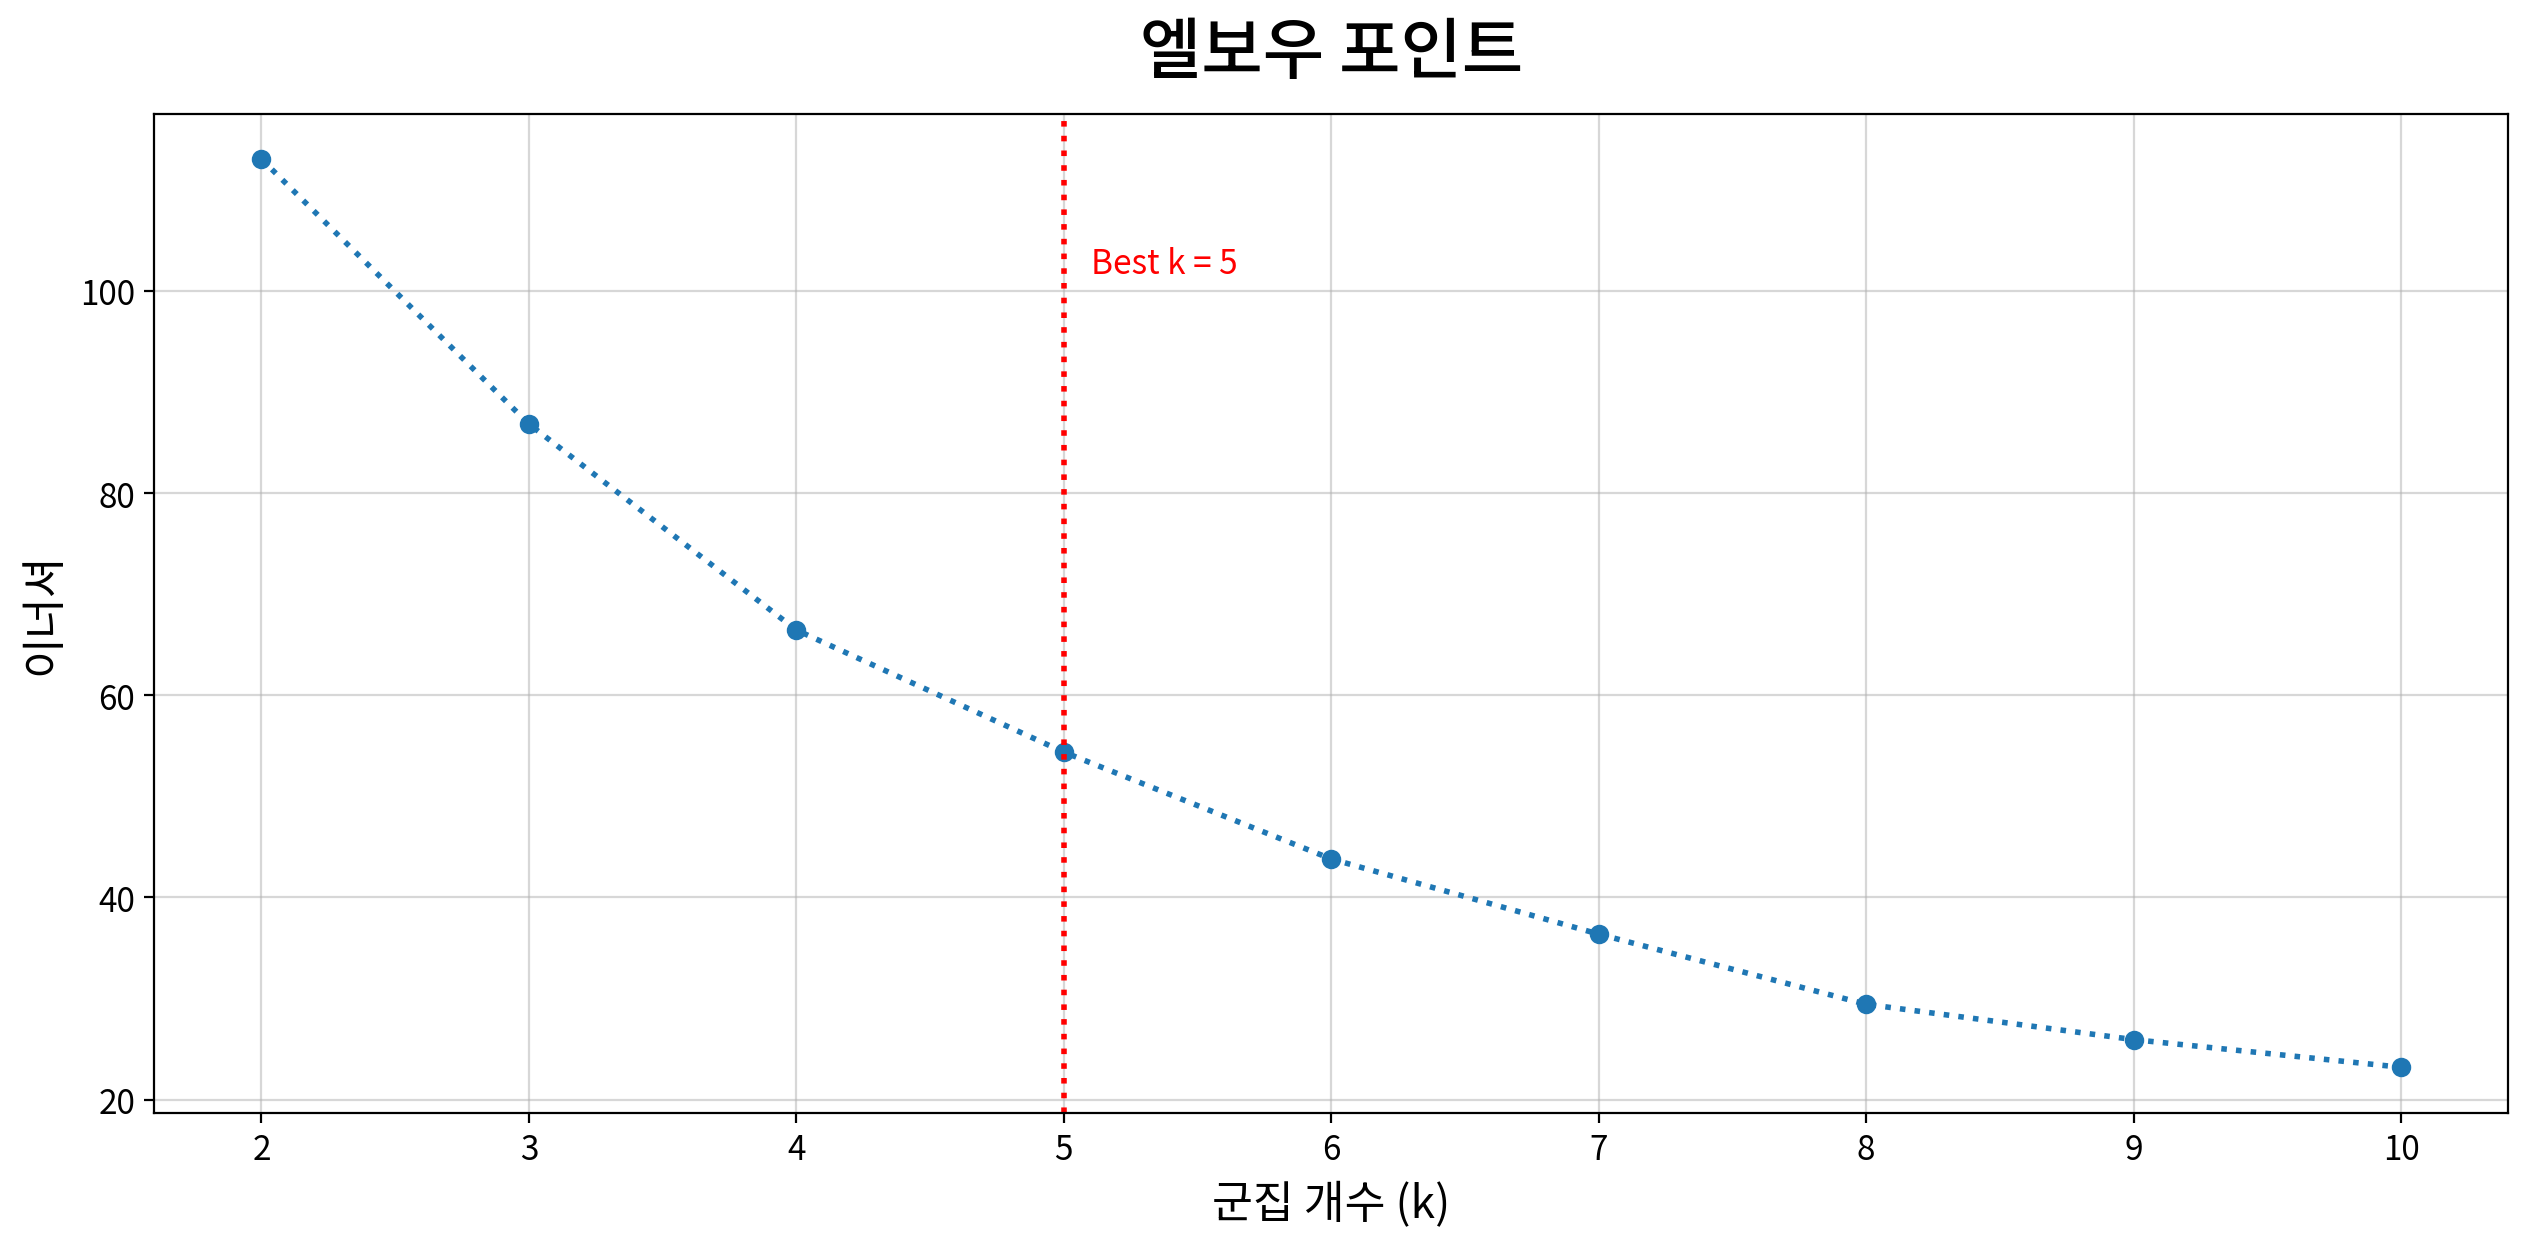

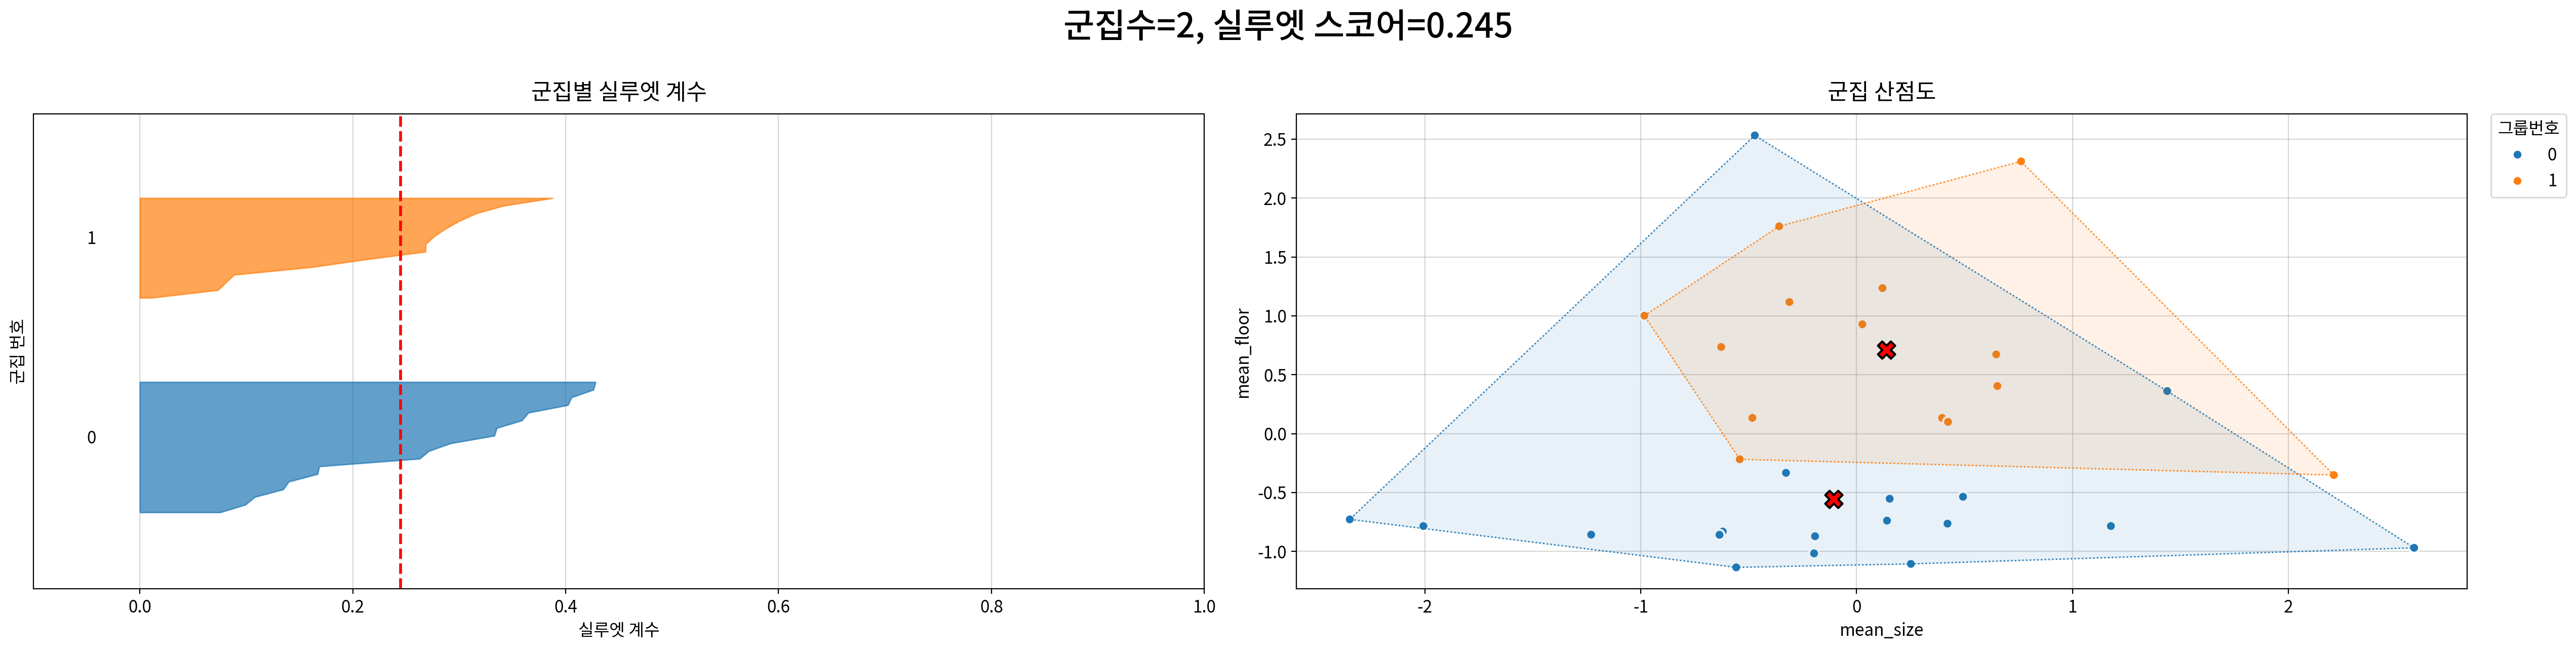

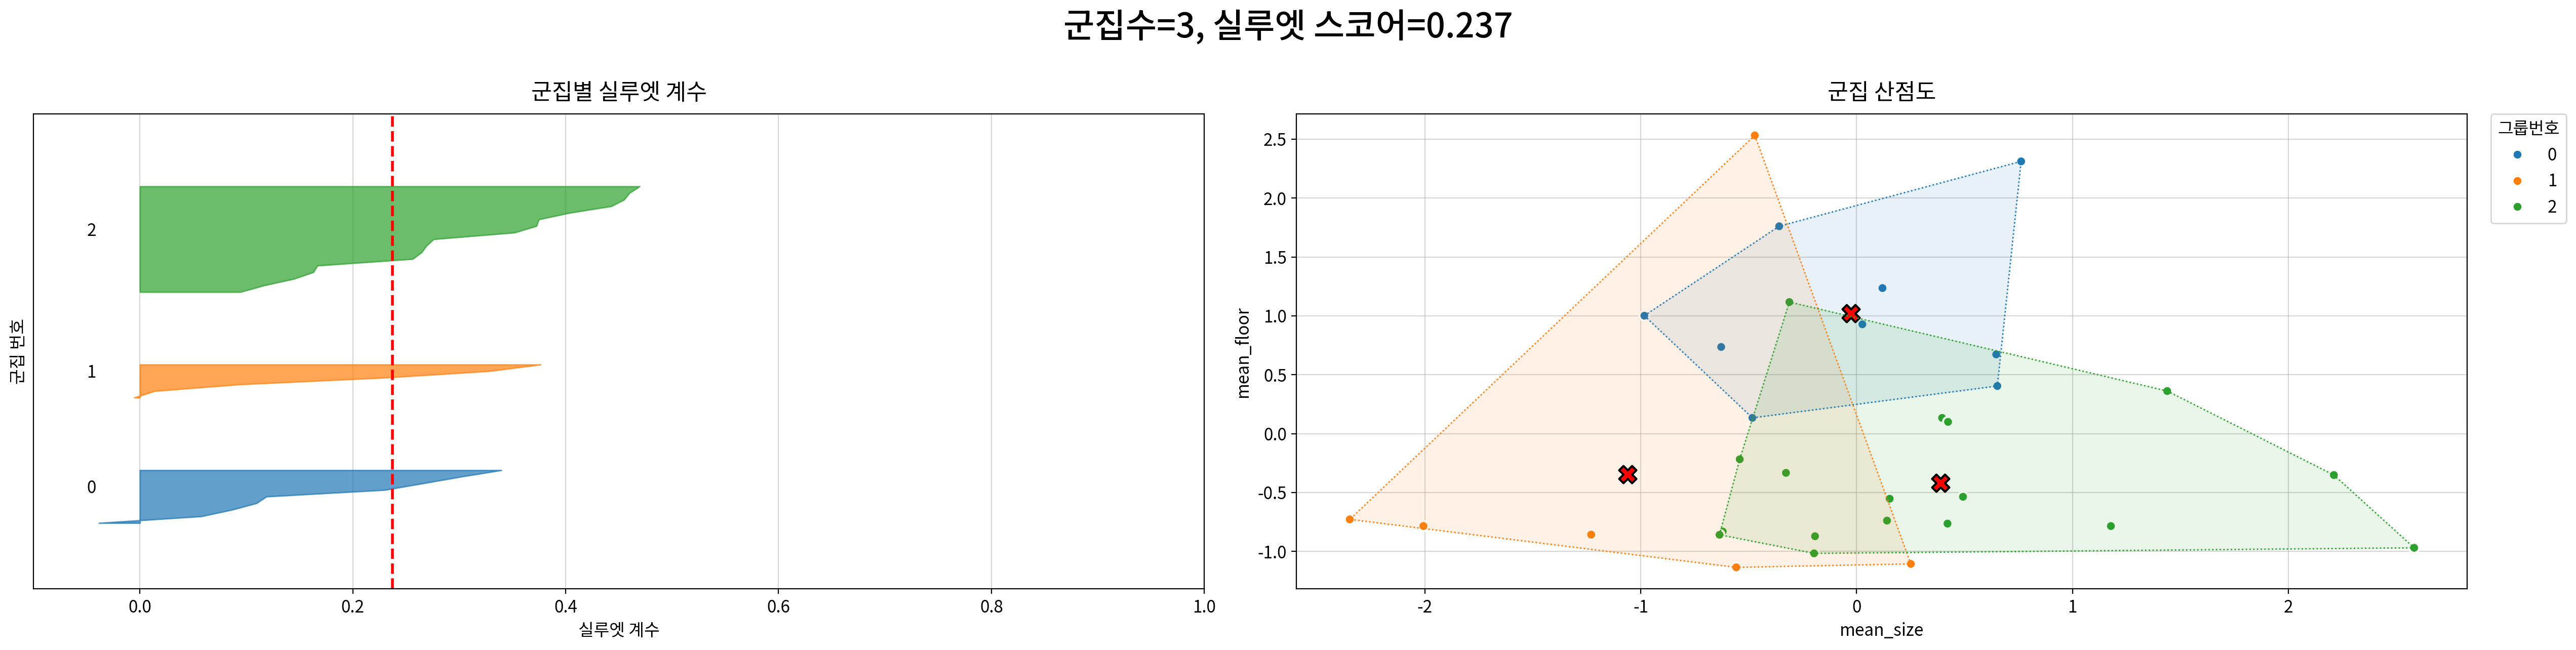

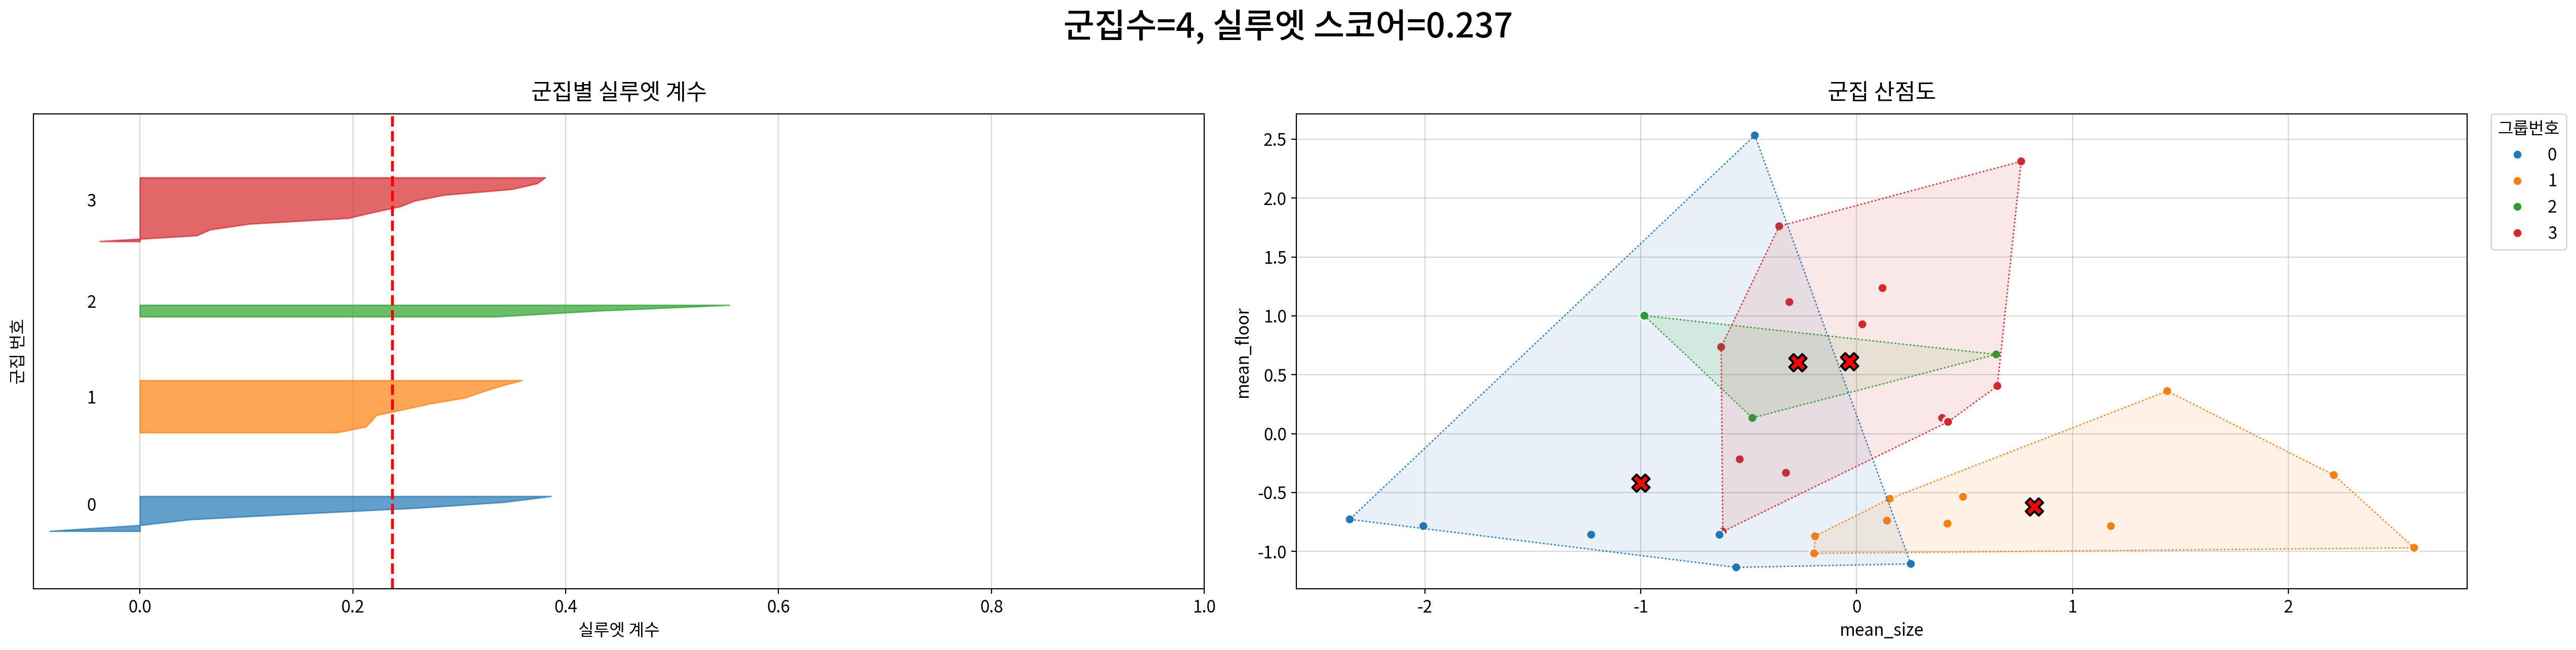

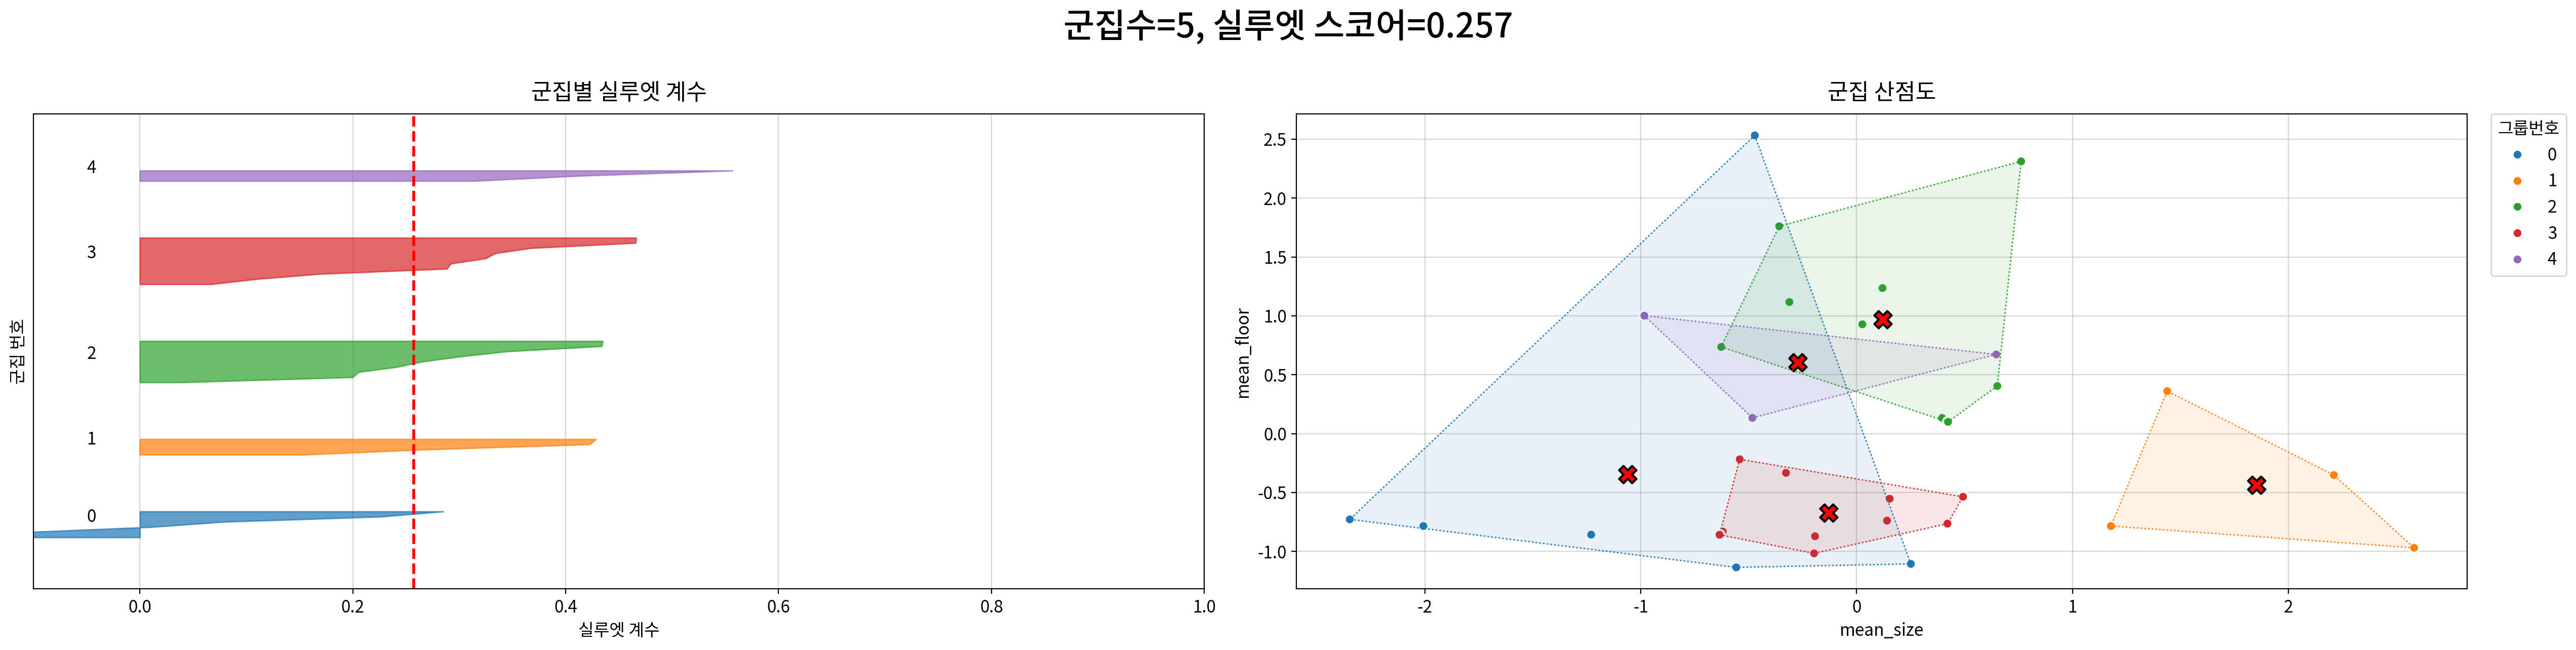

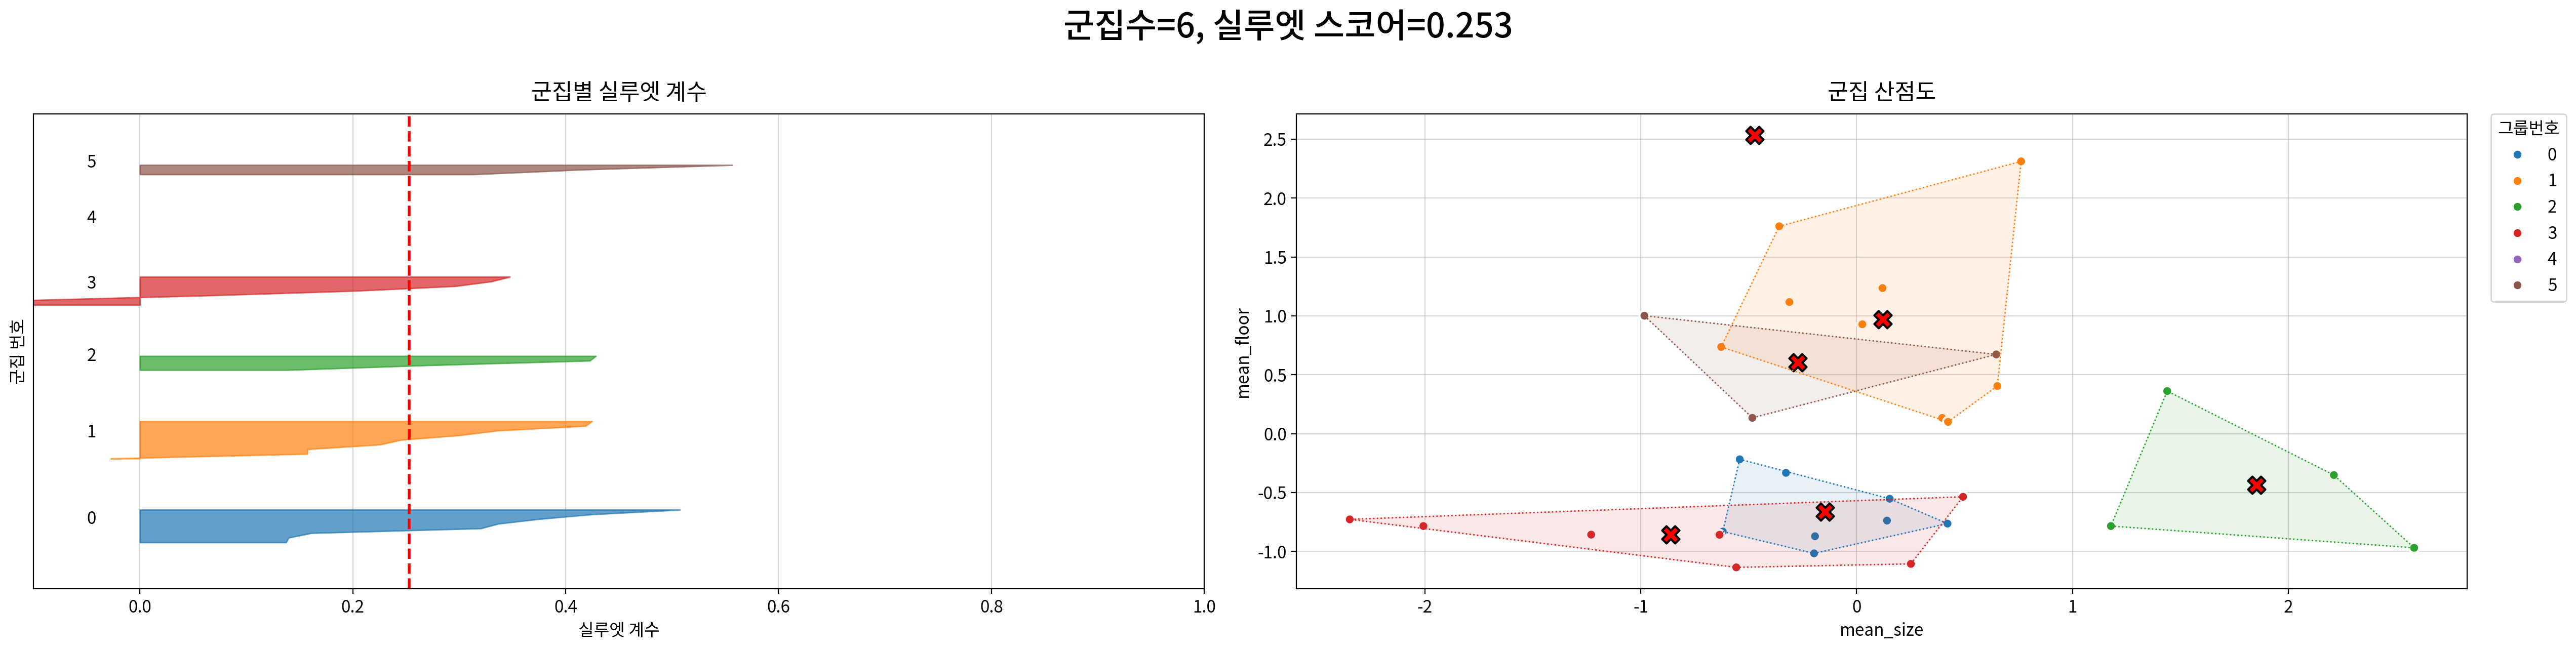

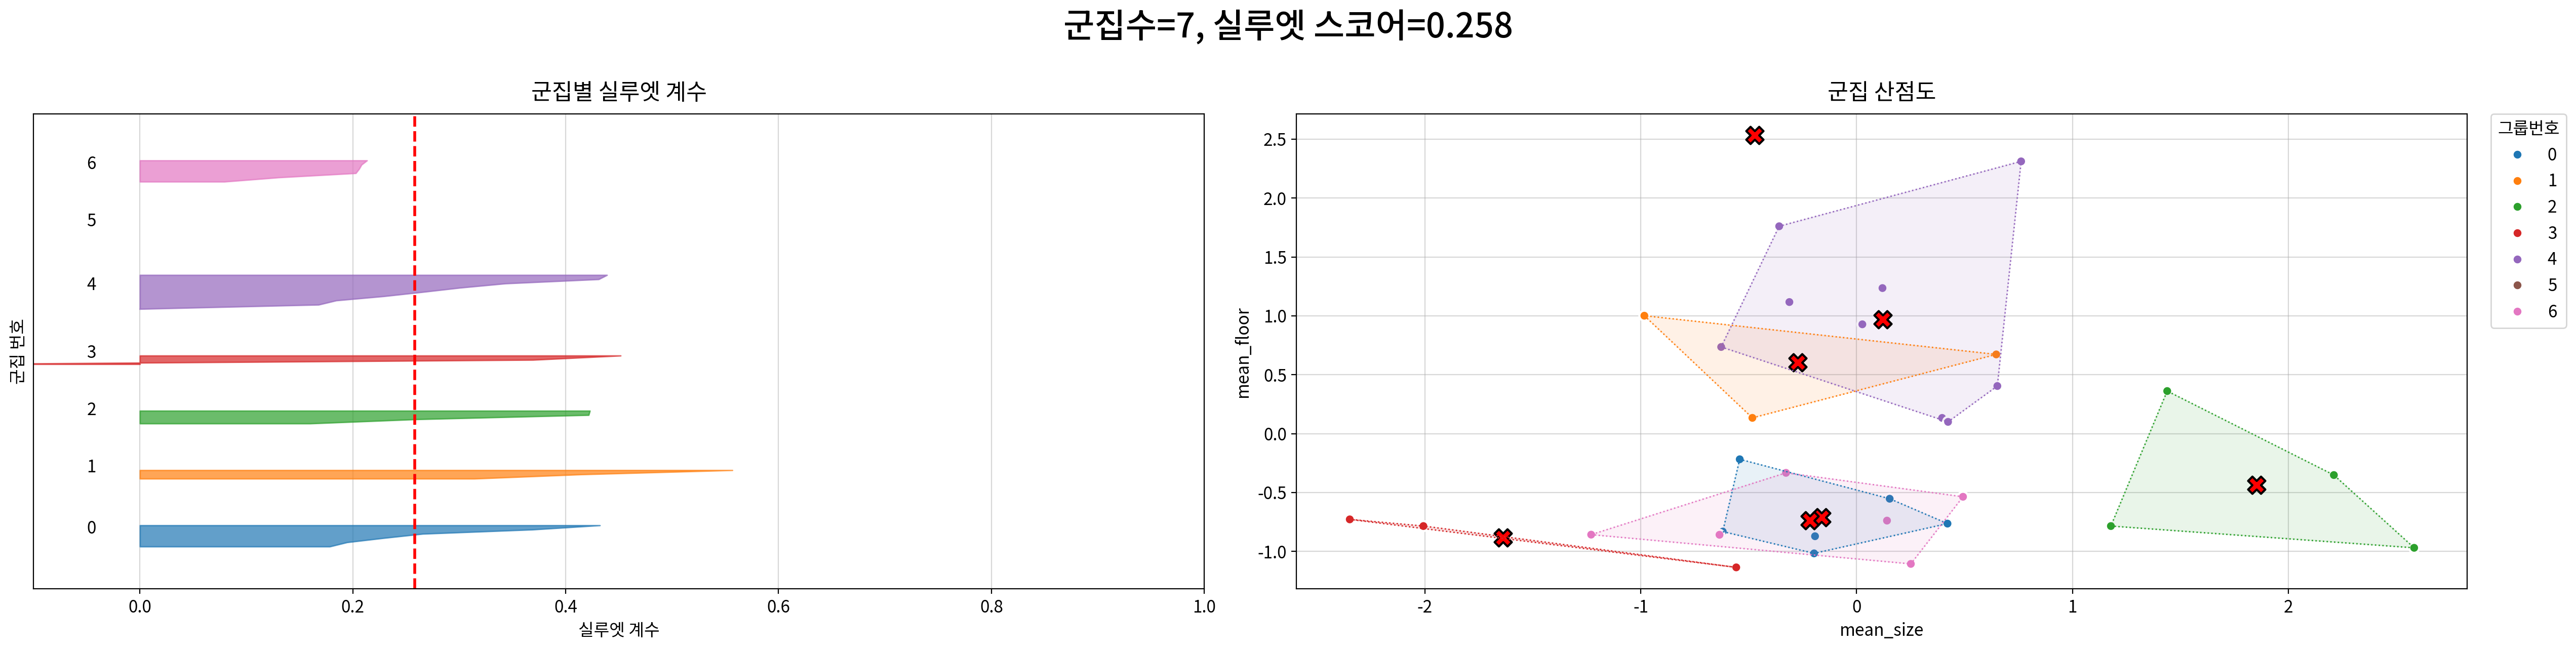

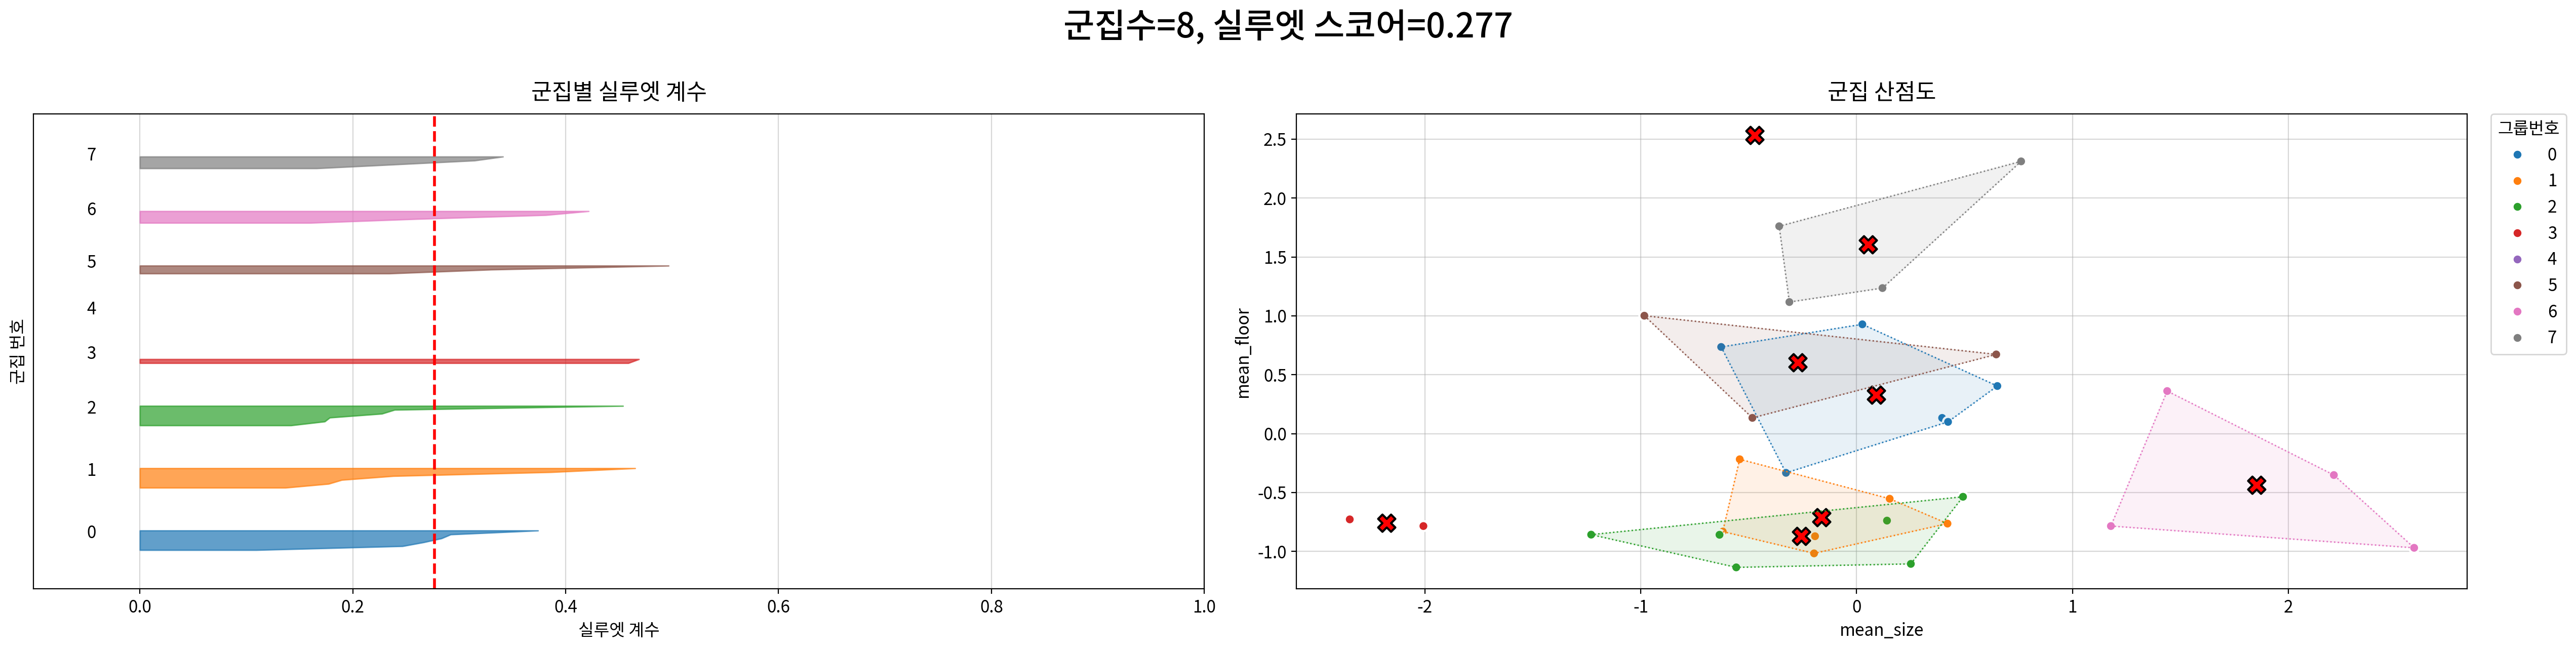

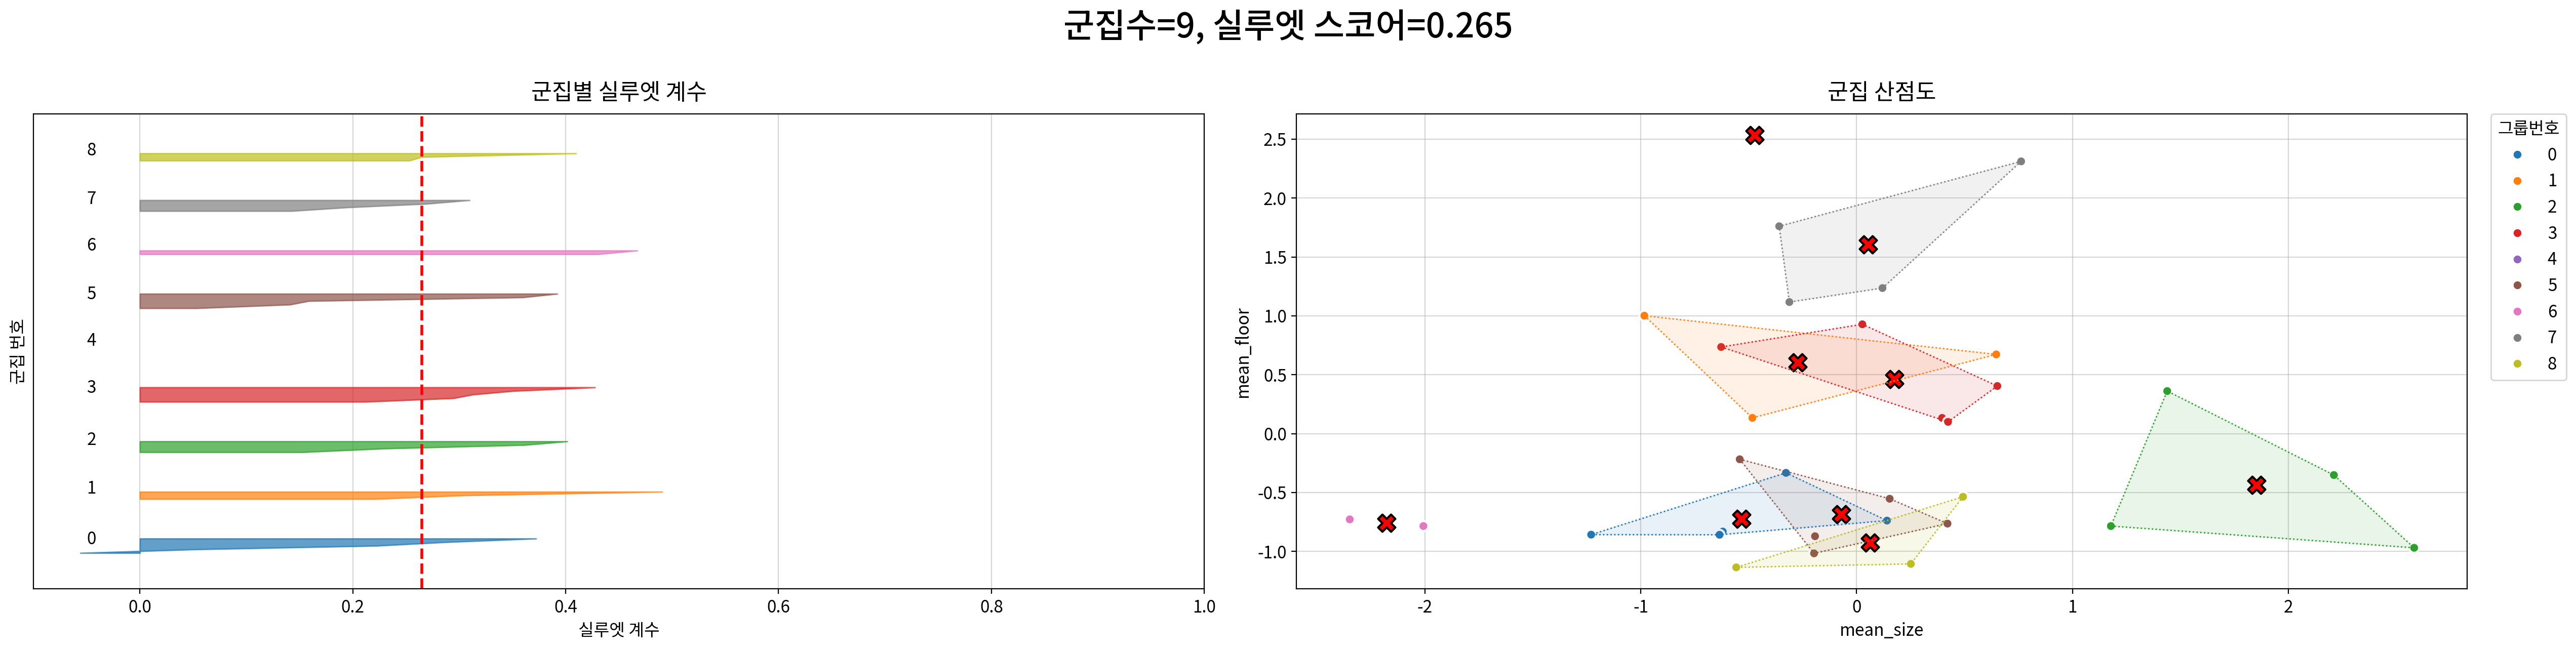

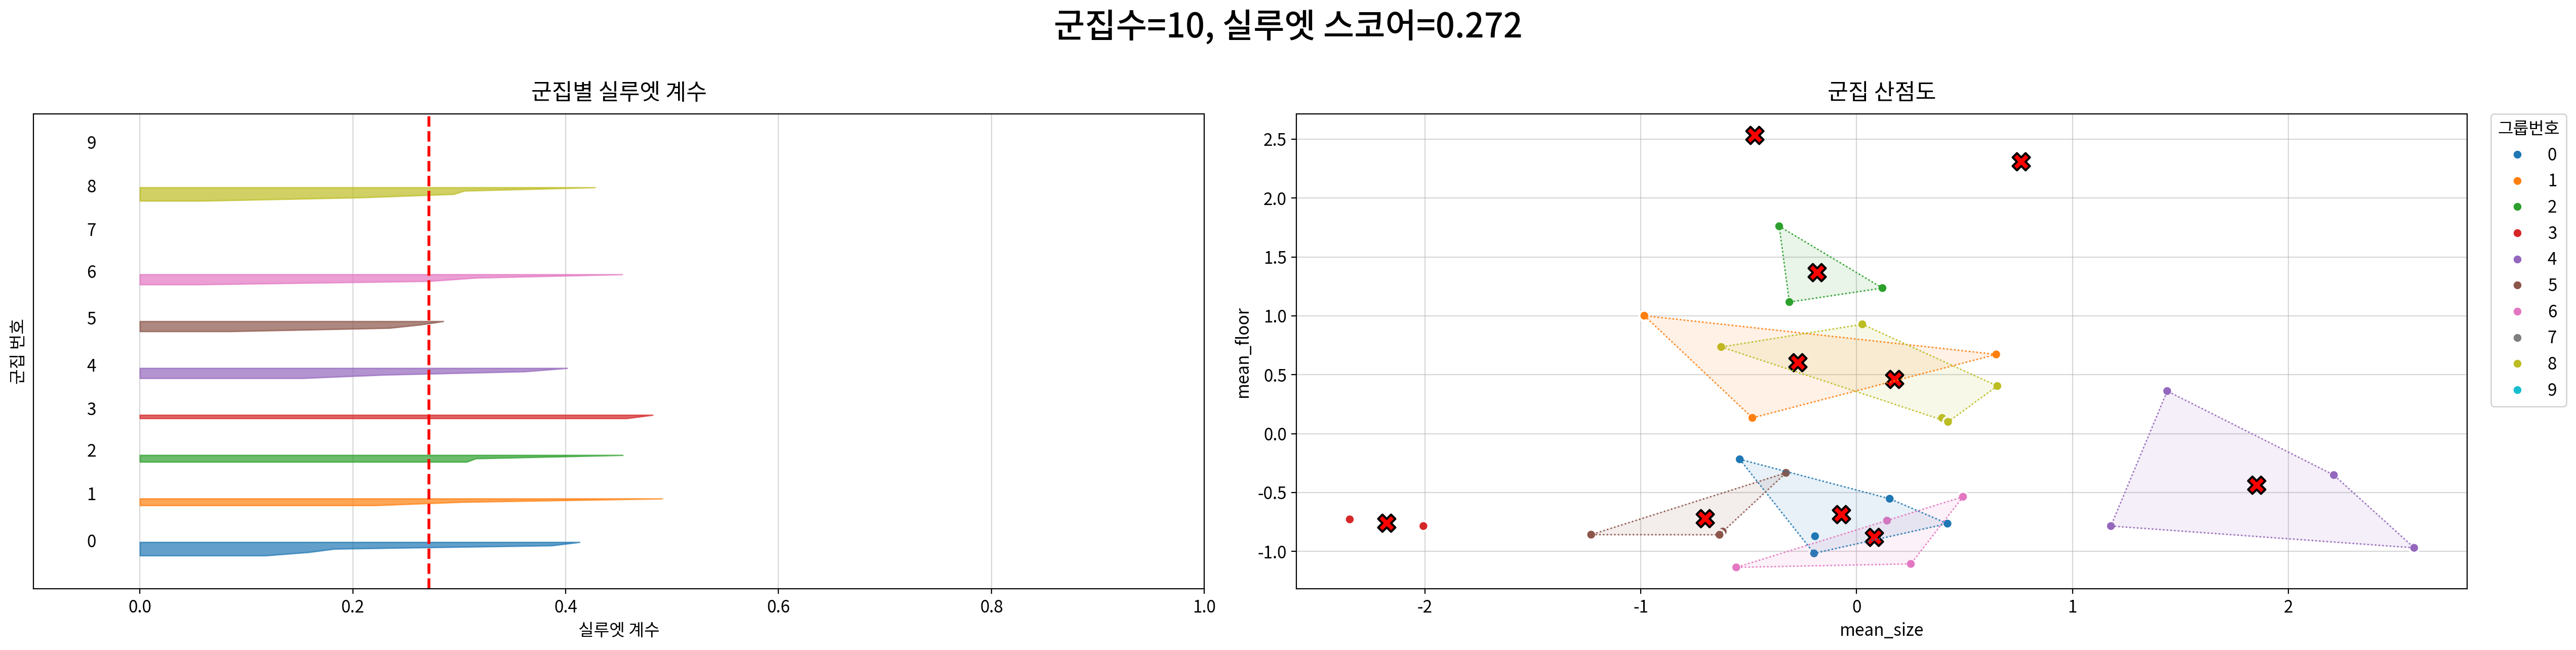

[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 2  (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
 · k = 5 : 균형지수 0.0157 (스코어 0.2574, 두께비 3.3333)
 · k = 2 : 균형지수 0.1493 (스코어 0.2451, 두께비 1.2857)
------------------------------------------------------------
>>> 최종 선택: k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


(2,
     k     이너셔    감소량   스코어  전체면적   두께비  최소상대면적  균형지수
 0   2 113.039    NaN 0.245 7.842 1.286   0.783 0.149
 1   3  86.834 26.205 0.237 7.586 2.833   0.409 0.034
 2   4  66.456 20.377 0.237 7.591 4.000   0.582 0.035
 3   5  54.382 12.074 0.257 8.238 3.333   0.203 0.016
 4   6  43.809 10.573 0.253 8.098 9.000   0.000 0.000
 5   7  36.377  7.432 0.258 8.264 9.000   0.000 0.000
 6   8  29.436  6.942 0.277 8.852 6.000   0.000 0.000
 7   9  25.941  3.495 0.265 8.479 5.000   0.000 0.000
 8  10  23.205  2.735 0.272 8.692 5.000   0.000 0.000)

In [37]:
my_cluster.best_k(neighborhood_profile, columns=['mean_size', 'mean_floor', 'mean_building_age', 'mean_amenity_count', 'mean_subway_time'], plot_each=True)

**군집 수 = 4로 결정**<br>
k=2는 두께비가 1.286, 균형지수가 0.149로 군집 크기의 균형은 가장 양호했다. 그러나 동네별 등록 매물의 특성을 두 가지 유형으로만 구분하기에는 지나치게 단순하다고 판단하였다.<br>

k=3은 이너셔가 86.834, 실루엣 점수가 0.237, 균형지수가 0.035로 나타났다.<br>

k=4는 실루엣 점수와 균형지수가 k=3과 동일한 수준을 유지하면서, 이너셔가 86.834에서 66.456으로 약 23.5% 감소하였다.<br>또한 최소상대면적이 0.409에서 0.582로 증가하여, 군집을 하나 추가하면서도 상대적으로 작은 군집의 크기가 안정적으로 유지되었다.<br>

k=5는 엘보우 포인트로 제시됐고 실루엣 점수도 0.257로 k=4보다 높았다. 그러나 최소상대면적이 0.582에서 0.203으로 크게 감소하고, 균형지수도 0.035에서 0.016으로 하락하였다. 이는 k=5에서 일부 군집의 크기가 상대적으로 작아지면서 군집 간 불균형이 커졌음을 의미한다.<br>

k=6 이상에서는 최소상대면적과 균형지수가 0.000으로 나타나, 매우 작은 군집이 형성되거나 지역 유형이 지나치게 세분화될 가능성이 있다고 판단하였다.<br><br>

따라서 k=2의 제한적인 세분화, k=5 이상의 군집 크기 불균형을 고려하고, 군집의 세분화 정도와 크기 안정성 사이의 균형을 확보하기 위해 최종 군집 수를 k=4로 결정하였다.

In [38]:
final_k = 4

# neighborhood 대신, 평균 면적, 평균 층, 평균 건물 연수, 평균 역까지 시간, 평균 펴의시설로 3개 권역을 만든다.
estimator, cdf, _ = my_cluster.kmeans(neighborhood_profile, k=final_k, columns=["mean_size", "mean_floor", "mean_building_age", "mean_subway_time", "mean_amenity_count"], plot=False)

neighborhood_profile["spatial_cluster"] = cdf["그룹번호"].astype("category")
column_means["spatial_cluster"] = "neighborhood_profile 기반 공간 군집"

StandardScaler 적용 (5개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
mean_size       433.33 ~ 1396.84          -2.35 ~ 2.58
mean_floor          2.94 ~ 24.50          -1.14 ~ 2.53
mean_building_age       4.00 ~ 111.00          -2.23 ~ 1.89
mean_subway_time        1.50 ~ 14.20          -1.06 ~ 3.42
mean_amenity_count         0.00 ~ 2.33          -2.01 ~ 2.21


In [39]:
cluster_summary = (
    neighborhood_profile
    .groupby("spatial_cluster", observed=True)
    .agg(
        동네수=("neighborhood", "nunique"),
        구성동네=(
            "neighborhood",
            lambda x: ", ".join(sorted(x))
        ),
        매물수=("listing_count", "sum"),
        동네평균월세평균=("mean_rent", "mean"),
        평균면적=("mean_size", "mean"),
        평균층=("mean_floor", "mean"),
        평균건물연수=("mean_building_age", "mean"),
        평균역까지시간=("mean_subway_time", "mean"),
        평균편의시설수=("mean_amenity_count", "mean")
    )
    .sort_values("동네평균월세평균", ascending=False)
)

display(cluster_summary)

,동네수,구성동네,매물수,동네평균월세평균,평균면적,평균층,평균건물연수,평균역까지시간,평균편의시설수
spatial_cluster,,,,,,,,,
1,10,"Central Harlem, Central Park South, Greenwich Village, Inwood, Lower East Side, Morningside Heights, Nolita, Soho, Tribeca, West Village",488,5594.263,1052.941,5.955,74.381,3.073,1.213
3,12,"Chelsea, East Harlem, Financial District, Flatiron, Gramercy Park, Midtown, Midtown East, Midtown South, Midtown West, Stuyvesant Town/PCV, Upper East Side, Upper West Side",2720,4846.140,885.533,13.212,49.248,4.394,1.393
2,3,"Battery Park City, Long Island City, Roosevelt Island",113,4061.654,838.779,13.156,11.935,11.954,1.603
0,7,"Chinatown, East Village, Hamilton Heights, Little Italy, Manhattanville, Washington Heights, West Harlem",191,2591.467,696.808,7.145,87.080,3.511,0.272


In [40]:
df2["neighborhood"].value_counts()

neighborhood
Upper West Side        577
Upper East Side        492
Midtown East           455
Midtown West           311
Financial District     265
Chelsea                181
Flatiron               132
Tribeca                119
Midtown                118
East Village           108
Battery Park City      104
Midtown South           85
Central Harlem          81
West Village            67
Greenwich Village       66
Gramercy Park           61
Soho                    58
Washington Heights      54
Lower East Side         41
East Harlem             40
Central Park South      23
Hamilton Heights        16
Morningside Heights     13
Inwood                  11
Nolita                   9
Chinatown                7
Roosevelt Island         5
Long Island City         4
Little Italy             3
Stuyvesant Town/PCV      3
West Harlem              2
Manhattanville           1
Name: count, dtype: int64

In [41]:
cluster_name_map = {
    0: "소형·고연식 저편의형",
    1: "대형·저층 고연식 역세권형",
    2: "신축·고층 고편의형",
    3: "고층·중연식 편의형"
}

neighborhood_profile["cluster_name"] = (
    neighborhood_profile["spatial_cluster"]
    .astype(int)
    .map(cluster_name_map)
    .astype("category")
)

column_means.update({
    "cluster_name":  "권역별",
})

#### 범주형 파생변수 추가
https://github.com/Codecademy/datasets/blob/master/streeteasy/README.md 에 따르면 streeteasy 데이터셋은 2016년 6월이 기준년도이다.<br>
뉴욕 부동산 시장의 관행적 용어인 Pre-war는 1900~1939년, 일부는 1880년대까지 포함되는 시기에 건축된 건물을 부르는 용어로 역사적 가치와 독특한 건축미로 분류된다.<br>
해당 내용을 통해 1900~1939년 사이라고 할 수 있는 building_age_yrs가 77~116사이인 건물을 구분하는 이진형 명목형 파생변수를 사용하고자 한다.


In [42]:
# prewar : 1900~1939년 사이에 지어진 건물
df3["typical_prewar"] = (
    df3["building_age_yrs"].between(77, 116)
).astype(int).astype("category")

column_means.update({
    "typical_prewar":  "prewar기간 건축된 건물"
})

for n in ["typical_prewar"]:
    freq = df3[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df3[n].value_counts(normalize=True)
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) 분포"))
    display(freq)

#### ▶︎ typical_prewar(prewar기간 건축된 건물) 분포

,빈도,비율
typical_prewar,,
0,2339,0.666
1,1173,0.334


In [46]:
# 동네별 군집번호와 권역명을 df3에 병합
cluster_lookup = (
    neighborhood_profile[
        ["neighborhood", "spatial_cluster", "cluster_name"]
    ]
    .drop_duplicates("neighborhood")
)

df3 = (
    df3
    .drop(
        columns=["spatial_cluster", "cluster_name"],
        errors="ignore"
    )
    .merge(
        cluster_lookup,
        on="neighborhood",
        how="left",
        validate="many_to_one"
    )
)

In [56]:
derived_continuous = [
    "relative_size",
    "relative_floor",
    "relative_amenity_ratio"
]

derived_nominal = [
    "bed_bath_constraint",
    "typical_prewar",
    "cluster_name"
]

df3 = my_qtcheck.set_type(
    df3,
    as_category=derived_nominal
)

print("연속형 파생:", derived_continuous)
print("범주형 파생:", derived_nominal)

<class 'pandas.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   rent                       3512 non-null   int64   
 1   bedrooms                   3512 non-null   float64 
 2   bathrooms                  3512 non-null   int64   
 3   size_sqft                  3512 non-null   int64   
 4   min_to_subway              3512 non-null   int64   
 5   floor                      3512 non-null   float64 
 6   building_age_yrs           3512 non-null   int64   
 7   no_fee                     3512 non-null   category
 8   has_roofdeck               3512 non-null   category
 9   has_washer_dryer           3512 non-null   category
 10  has_doorman                3512 non-null   category
 11  has_elevator               3512 non-null   category
 12  has_dishwasher             3512 non-null   category
 13  has_patio                  3512 non-null   c

#### 단변량 분석 - 연속형 파생변수

In [57]:
derived_num_desc = my_qtcheck.numerical_summary(df3, columns=derived_continuous)
derived_num_desc[['mean', '50%', 'skew', 'kurt', 'outliers_ratio', 'log_need']]

,mean,50%,skew,kurt,outliers_ratio,log_need
relative_size,1.000,0.872,1.685,4.362,0.044,log
relative_floor,1.000,0.784,1.702,4.949,0.037,log1p
relative_amenity_ratio,1.000,0.000,2.904,27.650,0.017,log1p


#### 이변량 분석 - 상관분석 (연속형 파생 → 종속변수)

In [58]:
corr_list = []

for f in derived_continuous:
    corr_list.append(my_stats.correlation(df3, x=f, y=target, plot=False))

corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
relative_size,rent,Spearman,0.783,0.000,Strong,True,False,False,False,False,True
relative_floor,rent,Spearman,0.287,0.000,Weak,True,False,False,True,False,True
relative_amenity_ratio,rent,Spearman,0.069,0.000,Weak,True,False,False,False,False,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak      2
Strong    1
Name: count, dtype: int64


#### 이변량 분석 - T검정 (2집단 범주형 파생 → 종속변수)

#### ▶︎ bed_bath_constraint(침실욕실 제약) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: Mann-Whitney-Wilcoxon test two-sided, P_val:9.534e-191 U_stat=1.639e+06


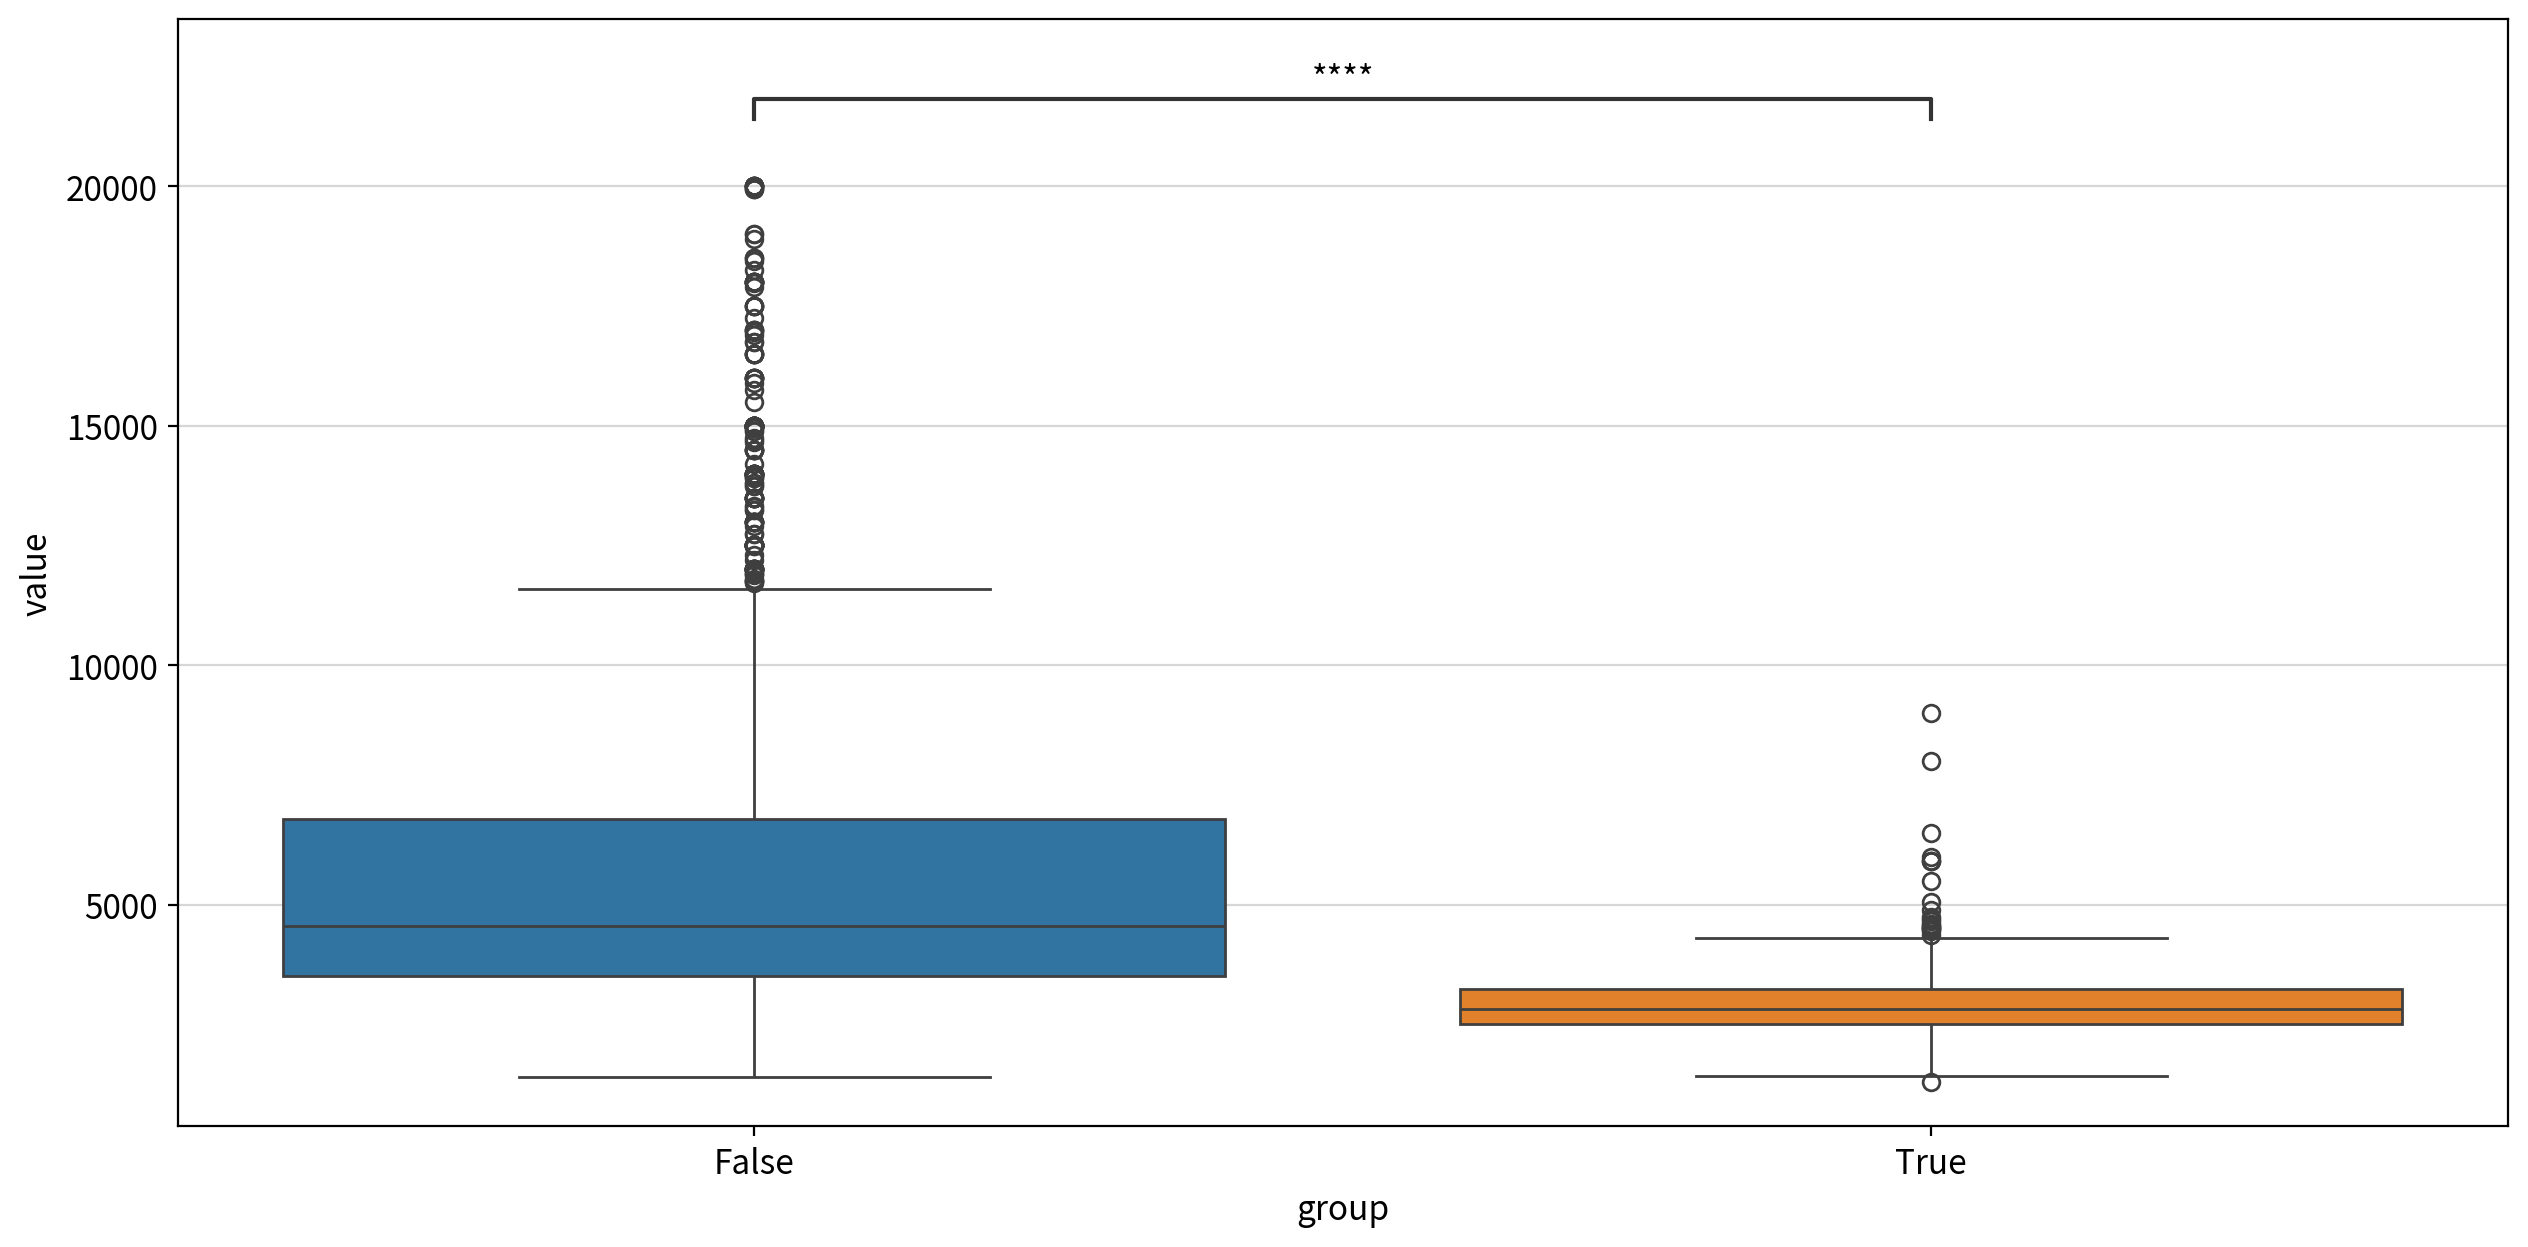

statistic  p-value  significant  \
test                alternative                                     
Mann-Whitney U test two-sided   1638669.000    0.000         True   
                    less        1638669.000    1.000        False   
                    greater     1638669.000    0.000         True   

                                       result  
test                alternative                
Mann-Whitney U test two-sided    False ≠ True  
                    less         False ≥ True  
                    greater      False > True

,count,mean
bed_bath_constraint,,
False,2848,5662.643
True,664,2913.575


#### ▶︎ typical_prewar(prewar기간 건축된 건물) → rent

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:9.434e-29 U_stat=1.687e+06


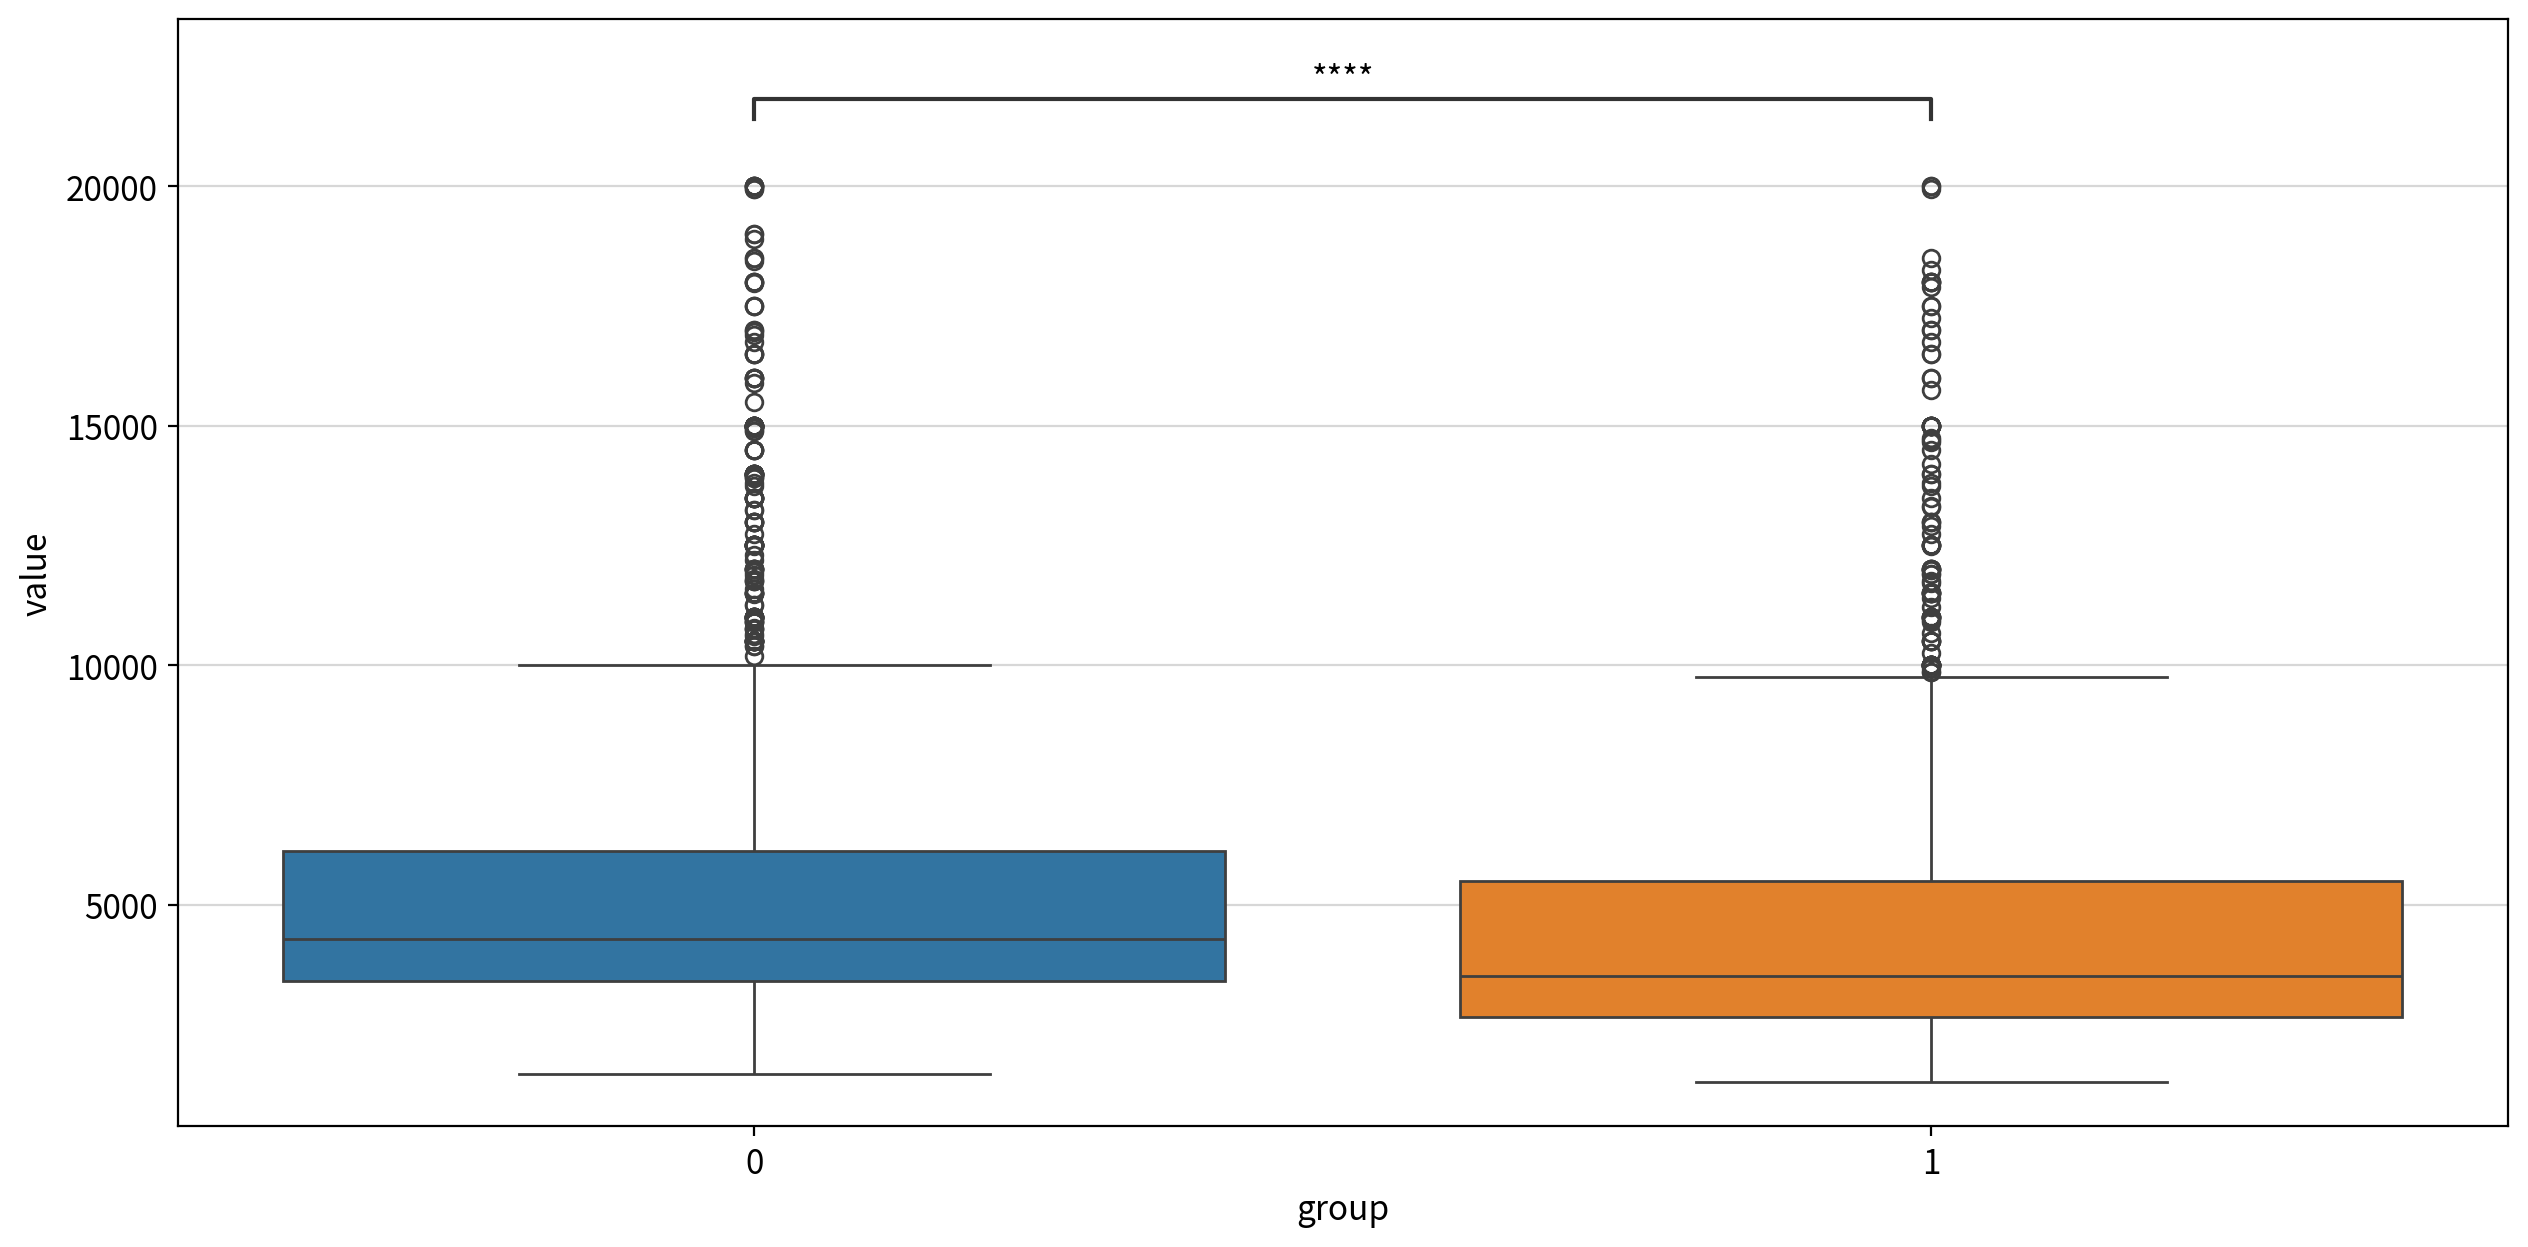

statistic  p-value  significant result
test                alternative                                         
Mann-Whitney U test two-sided   1687120.500    0.000         True  0 ≠ 1
                    less        1687120.500    1.000        False  0 ≥ 1
                    greater     1687120.500    0.000         True  0 > 1

,count,mean
typical_prewar,,
0,2339,5330.360
1,1173,4769.061


In [62]:
for n in derived_nominal:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) == 2:
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        wide_df = my_prep.long2wide(df3, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                    group1=wide_df.columns[0], group2=wide_df.columns[1]))

        display(df3.groupby(n, observed=True)[target].agg(['count', 'mean']))

#### 이변량 분석 - ANOVA (3집단 이상 범주형 파생 → 종속변수)

In [60]:
for n in derived_nominal:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) >= 3:
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        display(my_stats.anova_oneway(df3, y=target, between=n))
        display(my_stats.posthoc_oneway(df3, y=target, between=n, plot=False))

#### ▶︎ cluster_name(권역별) → rent

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,cluster_name,3,358.841,56.748,0.000,0.027,Small


비교한 조합 쌍: 6개
유의한 쌍: 4개
평균 차이가 가장 큰 쌍: (대형·저층 고연식 역세권형) vs (소형·고연식 저편의형) → 차이 2518.515, 효과크기 Medium, p-value 0.000
평균 차이가 가장 작은 쌍: (대형·저층 고연식 역세권형) vs (신축·고층 고편의형) → 차이 295.636, 효과크기 Negligible, p-value 0.802


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,고층·중연식 편의형,대형·저층 고연식 역세권형,5071.365,6038.070,-966.705,184.815,-5.231,599.414,0.000,-0.304,True,Small
1,Games-Howell,고층·중연식 편의형,소형·고연식 저편의형,5071.365,3519.555,1551.810,143.117,10.843,272.490,0.000,0.521,True,Medium
2,Games-Howell,고층·중연식 편의형,신축·고층 고편의형,5071.365,5742.434,-671.069,281.737,-2.382,122.247,0.086,-0.221,False,Small
3,Games-Howell,대형·저층 고연식 역세권형,소형·고연식 저편의형,6038.070,3519.555,2518.515,218.709,11.515,657.968,0.000,0.735,True,Medium
4,Games-Howell,대형·저층 고연식 역세권형,신축·고층 고편의형,6038.070,5742.434,295.636,326.691,0.905,213.000,0.802,0.079,False,Negligible
5,Games-Howell,소형·고연식 저편의형,신축·고층 고편의형,3519.555,5742.434,-2222.879,305.046,-7.287,163.158,0.000,-0.969,True,Large


#### 다변량 분석 - 파생변수 간 중복 점검

In [61]:
corr = my_stats.multi_correlation(df3, columns=derived_continuous, plot=False)
my_stats.correlation_summary(corr)

,relative_size,relative_floor,relative_amenity_ratio
relative_size,1.000,0.162,0.054
relative_floor,0.162,1.000,0.049
relative_amenity_ratio,0.054,0.049,1.000


,max-y,max-coef,count,columns
x,,,,
relative_floor,relative_size,0.162,0,-
relative_size,relative_floor,0.162,0,-
relative_amenity_ratio,relative_size,0.054,0,-


#### 모델링 투입 변수 채택 및 파생변수 데이터셋 저장

In [63]:
# 이번 단원의 검증 결과를 반영해 모형에 투입할 변수를 확정한다.
# -> condition_grp        : 병합 후에도 비유의(p=0.490) → 보류가 아니라 제외로 결론
# -> density_vs_neighbor  : 상관 최약(+0.172)에 왜도 최악(+21.9) → 제외
feature_cols = [
    "size_sqft",                # 원본 유지 : 기본변수 1순위
    "relative_size",            # 연속형 파생
    "relative_floor",           # 연속형 파생
    "relative_amenity_ratio",   # 연속형 파생
    "bed_bath_constraint",      # 범주형 파생
    "typical_prewar",           # 범주형 파생
    "cluster_name",             # 공간형 파생
]

print("투입 변수 :", len(feature_cols), "종")
print("투입 변수 목록 :", feature_cols)

# 저장 대상 = 투입 변수 + 종속변수
save_cols = feature_cols + [target]

# 로그 변환·라벨링 전, 원 단위 그대로의 상태를 먼저 남긴다.
df_derived = df3[save_cols]
df_derived = my_qtcheck.set_type(df_derived,
                    as_category=["bed_bath_constraint", "typical_prewar", "cluster_name"])

df_derived.to_excel("streeteasy_features.xlsx", index=False)
print("저장 완료 :", df_derived.shape)

df_derived.to_parquet("streeteasy_features.parquet", index=False)

투입 변수 : 7 종
투입 변수 목록 : ['size_sqft', 'relative_size', 'relative_floor', 'relative_amenity_ratio', 'bed_bath_constraint', 'typical_prewar', 'cluster_name']
<class 'pandas.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   size_sqft               3512 non-null   int64   
 1   relative_size           3512 non-null   float64 
 2   relative_floor          3512 non-null   float64 
 3   relative_amenity_ratio  3512 non-null   float64 
 4   bed_bath_constraint     3512 non-null   category
 5   typical_prewar          3512 non-null   category
 6   cluster_name            3512 non-null   category
 7   rent                    3512 non-null   int64   
dtypes: category(3), float64(3), int64(2)
memory usage: 148.1 KB
저장 완료 : (3512, 8)


#### 로그 변환 및 라벨링 후 최종 데이터셋 저장

In [1]:
# 투입 변수만 다시 기술통계량을 내어 로그 변환 대상을 확인한다.
feature_desc = my_qtcheck.numerical_summary(df_derived)
display(feature_desc[["skew", "kurt", "log_need"]])

# log_need 판정에 따라 변환 대상을 분류한다.
log_cols = feature_desc[feature_desc["log_need"] == "log"].index.tolist()
log1p_cols = feature_desc[feature_desc["log_need"] == "log1p"].index.tolist()
reflect_cols = feature_desc[feature_desc["log_need"] == "reverse_log1p"].index.tolist()

print("log(x)      :", log_cols)
print("log(1+x)    :", log1p_cols)
print("반사 후 log :", reflect_cols)

# 독립변수와 종속변수에 로그 변환 수행
df_log = my_prep.log_transform(df_derived,
            log_columns=log_cols,
            log1p_columns=log1p_cols,
            reflect_columns=reflect_cols)

# 범주형 라벨링 : category 타입을 모형이 읽을 수 있는 정수로 바꾼다.
label_cols = ["bed_bath_constraint", "typical_prewar", "cluster_name"]
df_label = my_prep.labeling(df_log, columns=label_cols)

df_label.to_excel("streeteasy_features_log_labeled.xlsx", index=False)
print("저장 완료 :", df_label.shape)
df_label.head()


NameError: name 'my_qtcheck' is not defined